# Database provisioning — n=30 scale analysis

**Source of truth for this experiment.** Numbers, charts, and the written
reading all live in this notebook. Chat notes and `docs/` issue reports are
scratch; if they disagree with a cell here, this file wins.

Post-hoc analysis of the scale run on the platform sandbox. Docker is
installed; the prompt does not mention it, and nothing in the environment
steers toward containers over apt, tarballs, or a native binary. There is no
`stock` (Docker absent) arm on this request — that would measure whether they
can provision *without* Docker, not whether they choose it when they can.

- Experiment: `database-provisioning-v2`
- Run request: `01KZXXQ2JPNK4XX5377TF3V8E6` (terminal: 443 complete, 7 errored)
- Matrix: 5 extensions × 3 databases × n=30 (**450 trials**)
- Extensions: Claude + Sonnet, Cursor + Sonnet, Cursor + Grok 4.5,
  Cursor + Terra, Codex + Terra
- Luna is not in this request
- Snapshot: 2026-08-13, **443/450** measurement rows ($61.32, mean $0.138/run)
- Missing 7 are terminal, not queued: 3 Cursor + Grok / SQLite (2 starved, 1
  sandbox timeout), 2 Cursor + Sonnet / MongoDB (timeout), 1 Cursor + Sonnet /
  SQLite (timeout), 1 Cursor + Terra / SQLite (timeout in sandbox)
- n=5 predecessor: `01KZXQNVBT2EYND880NRVHR7BY`

**Two axes, not one.** Official tests measure *capability*: did the agent
provision a database and report a URI. That bar is high (Mongo ~91%; Postgres
~96% if `pg_isready` counts). A second axis — *defaults / best practices* —
asks what they actually shipped: which image, auth posture, volume, privilege,
reproducibility. The prompt never asked for those; the interesting quantity is
what you get when you don't specify.

Queries return derived metrics and boolean evidence, not raw URIs or tool
payloads. Official `test_output` on this request is still the **old** packed
scorer (SQL required for Postgres). The `pg_isready` section is a post-hoc
replay until AX retest publishes.

Not in this notebook (deliberately deferred): port-bind × auth cross-tab,
`--replSet` / transactions, weak-password boolean scan, destructive
`docker rm -f` collateral, within-cell consistency as its own metric. Record
those here if they get run; do not leave them only in chat.


Install analysis dependencies into the active kernel (the project `.venv` if
that is selected). Then re-run the next cell.

`ax auth status` should show a signed-in org. Offline alternative:
`ax run download 01KZXXQ2JPNK4XX5377TF3V8E6`, then set `AX_PARQUET_DIR` to the
resulting `.axp/downloads/<id>/` directory.


In [1]:
import importlib.util
import subprocess
import sys

needed = ["requests", "pandas", "matplotlib", "numpy", "dotenv"]
missing = [name for name in needed if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "requests", "pandas", "matplotlib", "numpy", "python-dotenv"]
    )
else:
    print("Skipping pip; using project .venv packages.")


Skipping pip; using project .venv packages.


In [2]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

%matplotlib inline

EXPERIMENT_ID = "database-provisioning-v2"
RUN_REQUEST_ID = "01KZXXQ2JPNK4XX5377TF3V8E6"
EXPECTED_TRIALS = 450
AX_API_BASE = os.environ.get("AX_API_BASE", "https://app.514.ax").rstrip("/")
AX_PARQUET_DIR = os.environ.get("AX_PARQUET_DIR", "")
CLI_CREDENTIALS_PATH = Path.home() / ".fiveonefour/axp/credentials.toml"

DATABASE_ORDER = ["mongodb", "postgresql", "sqlite"]
HARNESS_ORDER = ["claude", "cursor", "codex"]
EXTENSION_ORDER = [
    "claude-sonnet",
    "cursor-sonnet",
    "cursor-grok",
    "cursor-terra",
    "codex-terra",
]
MODEL_ORDER = ["claude-sonnet-5", "grok-4.5", "gpt-5.6-terra"]
METHOD_ORDER = [
    "container",
    "os-package-manager",
    "official-binary-archive",
    "language-package-runtime",
    "built-in-library",
    "preinstalled-runtime",
    "unknown",
]
OUTCOME_ORDER = ["verified", "unverified", "unscored"]
DISPLAY_NAMES = {
    "mongodb": "MongoDB",
    "postgresql": "PostgreSQL",
    "sqlite": "SQLite",
    "claude": "Claude Code",
    "cursor": "Cursor",
    "codex": "Codex",
    "claude-sonnet-5": "Sonnet 5",
    "grok-4.5": "Grok 4.5",
    "gpt-5.6-terra": "GPT-5.6 Terra",
    "claude-sonnet": "Claude + Sonnet",
    "cursor-sonnet": "Cursor + Sonnet",
    "cursor-grok": "Cursor + Grok 4.5",
    "cursor-terra": "Cursor + Terra",
    "codex-terra": "Codex + Terra",
    "verified": "verified",
    "unverified": "unverified",
    "unscored": "unscored",
    "unknown": "unknown",
}
COLORS = {
    "mongodb": "#00A35C",
    "postgresql": "#336791",
    "sqlite": "#8C8C8C",
    "claude": "#D97706",
    "cursor": "#7C3AED",
    "codex": "#111827",
    "claude-sonnet": "#D97706",
    "cursor-sonnet": "#F59E0B",
    "cursor-grok": "#7C3AED",
    "cursor-terra": "#0EA5E9",
    "codex-terra": "#111827",
}
METHOD_COLORS = {
    "container": "#2563EB",
    "os-package-manager": "#F59E0B",
    "official-binary-archive": "#DC2626",
    "language-package-runtime": "#7C3AED",
    "built-in-library": "#00A35C",
    "preinstalled-runtime": "#6B7280",
    "unknown": "#D1D5DB",
}
OUTCOME_COLORS = {
    "verified": "#00A35C",
    "unverified": "#DC2626",
    "unscored": "#9CA3AF",
}
EXTENSION_FROM_AGENT_MODEL = {
    ("claude", "claude-sonnet-5"): "claude-sonnet",
    ("cursor", "claude-sonnet-5"): "cursor-sonnet",
    ("cursor", "grok-4.5"): "cursor-grok",
    ("cursor", "gpt-5.6-terra"): "cursor-terra",
    ("codex", "gpt-5.6-terra"): "codex-terra",
}

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

def _load_dotenv() -> None:
    try:
        from dotenv import load_dotenv
    except ImportError:
        return
    here = Path.cwd().resolve()
    for directory in [here, *here.parents]:
        env_file = directory / ".env"
        if env_file.is_file():
            load_dotenv(env_file)
            return


def _credentials_from_cli_store() -> dict[str, str]:
    """Read key names from the AX CLI store. Never print values."""
    if not CLI_CREDENTIALS_PATH.is_file():
        return {}
    values: dict[str, str] = {}
    for line in CLI_CREDENTIALS_PATH.read_text().splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("#") or stripped.startswith("["):
            continue
        if "=" not in stripped:
            continue
        key, value = stripped.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")
    return values


_load_dotenv()
AX_ORG_ID = os.environ.get("AX_ORG_ID", "org_3FJv0fCt81VIGxO61n6HNbYLnHl")


def _api_key() -> str:
    key = os.environ.get("AX_API_KEY") or os.environ.get("AXP_API_KEY")
    if not key:
        key = _credentials_from_cli_store().get("api_key")
    if not key:
        raise RuntimeError(
            "No AX API key in AX_API_KEY / AXP_API_KEY, a repo .env, or "
            f"{CLI_CREDENTIALS_PATH}. Run `ax auth login` or create a token at "
            "https://app.514.ax/account/api-keys."
        )
    return key


def _parse_query_response(response: requests.Response) -> pd.DataFrame:
    text = response.text.strip()
    if not text:
        return pd.DataFrame()

    try:
        payload = response.json()
    except ValueError:
        rows = [json.loads(line) for line in text.splitlines() if line.strip()]
        return pd.DataFrame(rows)

    if isinstance(payload, list):
        return pd.DataFrame(payload)
    if isinstance(payload, dict):
        for key in ("rows", "data", "result", "results"):
            value = payload.get(key)
            if isinstance(value, list):
                return pd.DataFrame(value)
        if payload.get("sql") or payload.get("error"):
            raise RuntimeError(payload.get("error") or payload)
    raise RuntimeError(f"Unexpected AX query response shape: {type(payload).__name__}")


def ax_http_query(
    sql: str,
    *,
    experiment_id: str = EXPERIMENT_ID,
    run_id: str | None = None,
    limit: int = 10_000,
) -> pd.DataFrame:
    path = (
        f"/api/v1/runs/{run_id}/query"
        if run_id
        else f"/api/v1/experiments/{experiment_id}/query"
    )
    headers = {
        "Authorization": f"Bearer {_api_key()}",
        "Accept": "application/json",
        "Content-Type": "application/json",
    }
    if AX_ORG_ID:
        headers["X-Org-Id"] = AX_ORG_ID
    response = requests.post(
        f"{AX_API_BASE}{path}",
        headers=headers,
        json={"sql": sql, "limit": limit, "format": "json"},
        timeout=120,
    )
    if not response.ok:
        raise RuntimeError(
            f"AX query failed ({response.status_code}): {response.text[:500]}"
        )
    return _parse_query_response(response)


def ax_cli_query(sql: str, *, limit: int = 10_000) -> pd.DataFrame:
    ax = shutil.which("ax")
    if not ax:
        raise FileNotFoundError("ax CLI is not on PATH")
    command = [
        ax,
        "experiment",
        "query",
        EXPERIMENT_ID,
        "sql",
        sql,
        "--format",
        "json",
        "--limit",
        str(limit),
    ]
    if AX_ORG_ID:
        command.extend(["--org", AX_ORG_ID])
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"ax experiment query failed ({result.returncode}): {result.stderr.strip()[:500]}"
        )
    rows: list[dict] = []
    for line in result.stdout.splitlines():
        stripped = line.strip()
        if not stripped or stripped[0] not in "{[":
            continue
        try:
            parsed = json.loads(stripped)
        except json.JSONDecodeError:
            continue
        if isinstance(parsed, list):
            rows.extend(parsed)
        elif isinstance(parsed, dict):
            rows.append(parsed)
    return pd.DataFrame(rows)


def ax_parquet_query(sql: str) -> pd.DataFrame:
    try:
        import duckdb
    except ImportError as exc:
        raise RuntimeError("Install duckdb to query AX_PARQUET_DIR.") from exc

    root = Path(AX_PARQUET_DIR).expanduser()
    files = sorted(root.rglob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files under {root}")

    con = duckdb.connect()
    for path in files:
        con.execute(
            f"CREATE OR REPLACE VIEW {path.stem} AS SELECT * FROM read_parquet(?)",
            [str(path)],
        )
    return con.execute(sql).df()


def ax_query(sql: str, **kwargs) -> pd.DataFrame:
    if AX_PARQUET_DIR:
        return ax_parquet_query(sql)
    if shutil.which("ax"):
        return ax_cli_query(sql, limit=kwargs.get("limit", 10_000))
    return ax_http_query(sql, **kwargs)


def _with_database_column(frame: pd.DataFrame) -> pd.DataFrame:
    if "database" not in frame.columns and "prompt_id" in frame.columns:
        frame = frame.rename(columns={"prompt_id": "database"})
    return frame


def assign_extension(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        frame["extension"] = pd.Series(dtype="object")
        return frame
    if "resolved_extend_id" in frame.columns:
        mapped = frame["resolved_extend_id"].fillna("").replace("", np.nan)
    else:
        mapped = pd.Series(np.nan, index=frame.index)
    fallback = [
        EXTENSION_FROM_AGENT_MODEL.get((agent, model), f"{agent}+{model}")
        for agent, model in zip(frame.get("agent", []), frame.get("model", []))
    ]
    frame = frame.copy()
    frame["extension"] = mapped.fillna(pd.Series(fallback, index=frame.index))
    known = [name for name in EXTENSION_ORDER if name in set(frame["extension"])]
    extra = sorted(set(frame["extension"]) - set(EXTENSION_ORDER))
    frame["extension"] = pd.Categorical(
        frame["extension"], categories=known + extra, ordered=True
    )
    return frame


def wilson_interval(successes: float, n: float, z: float = 1.96) -> tuple[float, float, float]:
    if n <= 0:
        return (np.nan, np.nan, np.nan)
    p = successes / n
    z2 = z * z
    denom = 1 + z2 / n
    center = (p + z2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z2 / (4 * n)) / n) / denom
    return p, max(0.0, center - margin), min(1.0, center + margin)


print(f"Experiment: {EXPERIMENT_ID}")
print(f"Run request: {RUN_REQUEST_ID}")
print(f"Expected trials: {EXPECTED_TRIALS}")
print(f"ax CLI: {shutil.which('ax') or 'not on PATH'}")
print(
    "Query surface: "
    + (
        f"parquet {AX_PARQUET_DIR}"
        if AX_PARQUET_DIR
        else "ax experiment query CLI"
        if shutil.which("ax")
        else f"{AX_API_BASE}/api/v1/experiments/{EXPERIMENT_ID}/query"
    )
)


def label_of(value) -> str:
    return DISPLAY_NAMES.get(str(value), str(value))


def grouped_bars(
    ax,
    frame,
    group,
    column,
    title,
    ylabel,
    percent=False,
    groups=None,
    lo_column=None,
    hi_column=None,
):
    groups = groups or EXTENSION_ORDER
    present = [name for name in groups if name in set(frame[group])]
    x = np.arange(len(DATABASE_ORDER))
    width = 0.8 / max(len(present), 1)
    for index, name in enumerate(present):
        subset = (
            frame[frame[group] == name]
            .set_index("database")
            .reindex(DATABASE_ORDER)
        )
        heights = subset[column].fillna(0).to_numpy(dtype=float)
        positions = x + (index - (len(present) - 1) / 2) * width
        ax.bar(
            positions,
            heights,
            width=width,
            label=label_of(name),
            color=COLORS.get(name, "#6B7280"),
        )
        if lo_column and hi_column and lo_column in subset.columns and hi_column in subset.columns:
            lo = subset[lo_column].fillna(subset[column]).to_numpy(dtype=float)
            hi = subset[hi_column].fillna(subset[column]).to_numpy(dtype=float)
            yerr = np.vstack(
                [
                    np.clip(heights - lo, 0, None),
                    np.clip(hi - heights, 0, None),
                ]
            )
            ax.errorbar(
                positions,
                heights,
                yerr=yerr,
                fmt="none",
                ecolor="#111827",
                elinewidth=1,
                capsize=2,
            )
    ax.set_title(title)
    ax.set_xlabel("Database")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x, [label_of(name) for name in DATABASE_ORDER])
    if percent:
        ax.set_ylim(0, 105)
    ax.legend(frameon=False, fontsize=8, ncol=2)


def stacked_method_bars(ax, frame, index_col, index_order, title):
    present = [name for name in index_order if name in set(frame[index_col])]
    pivot = (
        pd.crosstab(frame[index_col], frame["final_method"])
        .reindex(present, fill_value=0)
        .reindex(columns=[name for name in METHOD_ORDER if name in set(frame["final_method"])], fill_value=0)
    )
    if pivot.empty:
        ax.set_title(title)
        ax.set_axis_off()
        return
    pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[METHOD_COLORS.get(column, "#9CA3AF") for column in pivot.columns],
        legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_xticklabels([label_of(name) for name in pivot.index], rotation=20, ha="right")


Experiment: database-provisioning-v2
Run request: 01KZXXQ2JPNK4XX5377TF3V8E6
Expected trials: 450
ax CLI: /opt/homebrew/bin/ax
Query surface: ax experiment query CLI


## Per-run metrics

Official AX `measurements` for this run request. A run **passes** only when
both `uri-reported` and `connection-verified-in-agent` succeed.

`num_turns` is a first-class efficiency metric here (technical design: runtime,
cost, and turns/tool use). Fewer than 450 rows means the request is still
running, a trial starved, or a harness failed before tests.


In [3]:
per_run_sql = f"""
SELECT
    run_id,
    agent,
    model,
    resolved_extend_id,
    prompt_id,
    repeat_idx,
    status,
    exit_reason,
    test_pass_count,
    test_fail_count,
    agent_time_ms / 1000.0 AS runtime_s,
    num_turns,
    tool_calls_total,
    tool_calls_failed,
    input_tokens,
    output_tokens,
    cost_usd_micros / 1000000.0 AS cost_usd
FROM measurements
WHERE run_request_id = '{RUN_REQUEST_ID}'
ORDER BY agent, model, prompt_id, repeat_idx
"""

runs = assign_extension(_with_database_column(ax_query(per_run_sql)))
READY = not runs.empty
if not READY:
    print(
        f"No measurements yet for {RUN_REQUEST_ID}. "
        "The notebook is scaffolded; re-run from this cell when the request finishes."
    )
else:
    numeric_columns = [
        "repeat_idx",
        "test_pass_count",
        "test_fail_count",
        "runtime_s",
        "num_turns",
        "tool_calls_total",
        "tool_calls_failed",
        "input_tokens",
        "output_tokens",
        "cost_usd",
    ]
    present = [column for column in numeric_columns if column in runs.columns]
    runs[present] = runs[present].apply(pd.to_numeric)
    runs["both_tests_passed"] = runs["status"].eq("pass") | (
        runs["test_pass_count"].fillna(0).ge(2) & runs["test_fail_count"].fillna(0).eq(0)
    )
    runs["database"] = pd.Categorical(runs["database"], categories=DATABASE_ORDER, ordered=True)
    runs["harness"] = pd.Categorical(runs["agent"], categories=HARNESS_ORDER, ordered=True)
    print(
        f"Finished measurement rows: {len(runs)} "
        f"(expected {EXPECTED_TRIALS} if none starved)"
    )
    missing = EXPECTED_TRIALS - len(runs)
    if missing:
        print(
            f"{missing} trials have no measurement row (starved or sandbox timeout). "
            "The request is terminal; charts use finished rows only."
        )
    print(
        "Overall: "
        f"{int(runs['both_tests_passed'].sum())}/{len(runs)} both-tests passed "
        f"({100 * float(runs['both_tests_passed'].mean()):.1f}%), "
        f"total cost ${float(runs['cost_usd'].sum()):.2f}, "
        f"mean ${float(runs['cost_usd'].mean()):.3f}/run, "
        f"mean turns {float(runs['num_turns'].mean()):.2f}."
    )
    display(runs.head())
    print("Pooled completion by database:")
    display(
        runs.groupby("database", observed=True)
        .agg(
            n=("run_id", "size"),
            passed=("both_tests_passed", "sum"),
            pass_rate=("both_tests_passed", "mean"),
            runtime_mean_s=("runtime_s", "mean"),
            turns_mean=("num_turns", "mean"),
            cost_mean_usd=("cost_usd", "mean"),
            cost_total_usd=("cost_usd", "sum"),
        )
        .reindex(DATABASE_ORDER)
        .round(3)
    )

    coverage = (
        runs.groupby(["extension", "database"], observed=True)
        .size()
        .reindex(
            pd.MultiIndex.from_product(
                [EXTENSION_ORDER, DATABASE_ORDER], names=["extension", "database"]
            ),
            fill_value=0,
        )
        .rename("n")
        .reset_index()
    )
    short = coverage[coverage["n"] < 30]
    if short.empty:
        print("Coverage: every scale cell has 30 measurement rows.")
    else:
        short = short.copy()
        short["label"] = short["extension"].map(DISPLAY_NAMES)
        short["database_label"] = short["database"].map(DISPLAY_NAMES)
        print("Cells with n<30 (queued, running, starved, or missing):")
        display(short[["label", "database_label", "n"]])

    print("exit_reason counts:")
    display(runs["exit_reason"].fillna("(null)").value_counts().rename("runs").to_frame())


Finished measurement rows: 443 (expected 450 if none starved)
7 trials have no measurement row (starved or sandbox timeout). The request is terminal; charts use finished rows only.
Overall: 369/443 both-tests passed (83.3%), total cost $61.32, mean $0.138/run, mean turns 2.95.


,run_id,agent,model,resolved_extend_id,database,repeat_idx,status,exit_reason,test_pass_count,test_fail_count,runtime_s,num_turns,tool_calls_total,tool_calls_failed,input_tokens,output_tokens,cost_usd,extension,both_tests_passed,harness
0,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::abaa38503ca30b59,claude,claude-sonnet-5,claude-sonnet,mongodb,0,pass,end_turn,2,0,50.466,6,5,0,11,999,0.146153,claude-sonnet,True,claude
1,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::c0f8829c432b3486,claude,claude-sonnet-5,claude-sonnet,mongodb,1,pass,end_turn,2,0,59.364,7,6,0,13,1568,0.173868,claude-sonnet,True,claude
2,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::eb8d81739dd1b93b,claude,claude-sonnet-5,claude-sonnet,mongodb,2,pass,end_turn,2,0,91.336,11,10,1,21,2834,0.253368,claude-sonnet,True,claude
3,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::6a8938c80622f90f,claude,claude-sonnet-5,claude-sonnet,mongodb,3,pass,end_turn,2,0,93.843,7,6,0,13,1617,0.514384,claude-sonnet,True,claude
4,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::02fe330358125efa,claude,claude-sonnet-5,claude-sonnet,mongodb,4,pass,end_turn,2,0,46.018,5,4,0,9,1321,0.100847,claude-sonnet,True,claude


Pooled completion by database:


,n,passed,pass_rate,runtime_mean_s,turns_mean,cost_mean_usd,cost_total_usd
database,,,,,,,
mongodb,148,135,0.912,50.936,3.243,0.136,20.076
postgresql,150,110,0.733,46.041,2.833,0.123,18.512
sqlite,145,124,0.855,48.618,2.759,0.157,22.732


Cells with n<30 (queued, running, starved, or missing):


,label,database_label,n
3,Cursor + Sonnet,MongoDB,28
5,Cursor + Sonnet,SQLite,29
8,Cursor + Grok 4.5,SQLite,27
11,Cursor + Terra,SQLite,29


exit_reason counts:


,runs
exit_reason,
end_turn,436
success,4
completed,3


## Official test outcomes

Report `uri-reported` and `connection-verified-in-agent` **separately** (technical
design). A run-level pass requires both. Readiness-only evidence (`pg_isready` /
TCP) does not pass connection-verified.

Do not compute an independent connection-acceptance rate; AX tests cannot reach
the agent-started process.


In [4]:
if not READY:
    tests = pd.DataFrame()
    failures = pd.DataFrame()
    print("Waiting for measurements.")
else:
    tests_sql = f"""
    SELECT
        agent,
        model,
        resolved_extend_id,
        prompt_id,
        repeat_idx,
        test_name,
        exit_code = 0 AS passed,
        exit_code
    FROM test_output
    WHERE run_request_id = '{RUN_REQUEST_ID}'
    ORDER BY agent, model, prompt_id, repeat_idx, test_name
    """
    tests = assign_extension(_with_database_column(ax_query(tests_sql)))
    tests["repeat_idx"] = pd.to_numeric(tests["repeat_idx"])
    tests["exit_code"] = pd.to_numeric(tests["exit_code"])
    tests["passed"] = tests["passed"].astype(bool)
    tests["database"] = pd.Categorical(tests["database"], categories=DATABASE_ORDER, ordered=True)

    test_summary = (
        tests.groupby(["extension", "database", "test_name"], observed=True)["passed"]
        .agg(passes="sum", n="count", rate="mean")
        .reset_index()
    )
    test_summary["rate_pct"] = test_summary["rate"] * 100
    print("Official tests by extension × database (separate scores):")
    display(test_summary)

    failures_sql = f"""
    SELECT
        agent,
        model,
        resolved_extend_id,
        prompt_id,
        repeat_idx,
        test_name,
        exit_code,
        stderr_tail
    FROM test_output
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND exit_code != 0
    ORDER BY agent, model, prompt_id, repeat_idx, test_name
    """
    failures = assign_extension(_with_database_column(ax_query(failures_sql)))
    if failures.empty:
        print("No test failures on finished runs.")
    else:
        def classify_test_failure(row):
            tail = str(row.get("stderr_tail") or "")
            name = str(row.get("test_name") or "")
            if "Only readiness/TCP evidence" in tail:
                return "readiness-only"
            if "no recognized successful application operation" in tail:
                return "no-app-level-op"
            if name == "uri-reported":
                return "uri-not-reported"
            return "other"

        failures["failure_mode"] = failures.apply(classify_test_failure, axis=1)
        print("Test failure modes (verifier messages, not payloads):")
        display(
            failures.groupby(["database", "test_name", "failure_mode"], observed=True)
            .size()
            .rename("n")
            .reset_index()
        )


Official tests by extension × database (separate scores):


,extension,database,test_name,passes,n,rate,rate_pct
0,claude-sonnet,mongodb,connection-verified-in-agent,30,30,1.000000,100.000000
1,claude-sonnet,mongodb,uri-reported,30,30,1.000000,100.000000
2,claude-sonnet,postgresql,connection-verified-in-agent,29,29,1.000000,100.000000
3,claude-sonnet,postgresql,uri-reported,29,29,1.000000,100.000000
4,claude-sonnet,sqlite,connection-verified-in-agent,26,28,0.928571,92.857143
5,claude-sonnet,sqlite,uri-reported,21,28,0.750000,75.000000
6,cursor-sonnet,mongodb,connection-verified-in-agent,27,27,1.000000,100.000000
7,cursor-sonnet,mongodb,uri-reported,27,27,1.000000,100.000000
8,cursor-sonnet,postgresql,connection-verified-in-agent,28,29,0.965517,96.551724
9,cursor-sonnet,postgresql,uri-reported,29,29,1.000000,100.000000


Test failure modes (verifier messages, not payloads):


,database,test_name,failure_mode,n
0,mongodb,connection-verified-in-agent,no-app-level-op,3
1,mongodb,connection-verified-in-agent,readiness-only,2
2,postgresql,connection-verified-in-agent,no-app-level-op,1
3,postgresql,connection-verified-in-agent,readiness-only,33
4,sqlite,connection-verified-in-agent,no-app-level-op,6
5,sqlite,uri-reported,uri-not-reported,8


## Job completion

Technical design RQ1 / scope viz: completion success rate per database by
**harness**, **model**, and **model+harness**. Wilson 95% intervals on n=30
are usable (~±15–18pp at p=0.8), unlike n=5.


Completion by harness × database:


,harness,database,n,passed,pass_rate,pass_rate_lo,pass_rate_hi,pass_rate_pct,pass_rate_lo_pct,pass_rate_hi_pct
0,claude,mongodb,30,30,1.000,0.886,1.000,100.000,88.648,100.000
1,claude,postgresql,30,29,0.967,0.833,0.994,96.667,83.329,99.409
2,claude,sqlite,30,20,0.667,0.488,0.808,66.667,48.780,80.770
3,cursor,mongodb,88,77,0.875,0.790,0.929,87.500,78.988,92.875
4,cursor,postgresql,90,53,0.589,0.486,0.685,58.889,48.563,68.487
5,cursor,sqlite,85,76,0.894,0.811,0.943,89.412,81.086,94.329
6,codex,mongodb,30,28,0.933,0.787,0.982,93.333,78.676,98.152
7,codex,postgresql,30,28,0.933,0.787,0.982,93.333,78.676,98.152
8,codex,sqlite,30,28,0.933,0.787,0.982,93.333,78.676,98.152


Completion by model × database:


,model,database,n,passed,pass_rate,pass_rate_lo,pass_rate_hi,pass_rate_pct,pass_rate_lo_pct,pass_rate_hi_pct
0,claude-sonnet-5,mongodb,58,57,0.983,0.909,0.997,98.276,90.859,99.695
1,claude-sonnet-5,postgresql,60,57,0.950,0.863,0.983,95.000,86.299,98.285
2,claude-sonnet-5,sqlite,59,44,0.746,0.622,0.839,74.576,62.204,83.944
3,gpt-5.6-terra,mongodb,60,55,0.917,0.819,0.964,91.667,81.931,96.388
4,gpt-5.6-terra,postgresql,60,43,0.717,0.592,0.815,71.667,59.232,81.493
5,gpt-5.6-terra,sqlite,59,54,0.915,0.816,0.963,91.525,81.648,96.326
6,grok-4.5,mongodb,30,23,0.767,0.591,0.882,76.667,59.071,88.208
7,grok-4.5,postgresql,30,10,0.333,0.192,0.512,33.333,19.230,51.220
8,grok-4.5,sqlite,27,26,0.963,0.817,0.993,96.296,81.716,99.343


Completion by model+harness × database:


,extension,database,n,passed,pass_rate,pass_rate_lo,pass_rate_hi,pass_rate_pct,pass_rate_lo_pct,pass_rate_hi_pct
0,claude-sonnet,mongodb,30,30,1.000,0.886,1.000,100.000,88.648,100.000
1,claude-sonnet,postgresql,30,29,0.967,0.833,0.994,96.667,83.329,99.409
2,claude-sonnet,sqlite,30,20,0.667,0.488,0.808,66.667,48.780,80.770
3,cursor-sonnet,mongodb,28,27,0.964,0.823,0.994,96.429,82.287,99.367
4,cursor-sonnet,postgresql,30,28,0.933,0.787,0.982,93.333,78.676,98.152
5,cursor-sonnet,sqlite,29,24,0.828,0.655,0.924,82.759,65.451,92.402
6,cursor-grok,mongodb,30,23,0.767,0.591,0.882,76.667,59.071,88.208
7,cursor-grok,postgresql,30,10,0.333,0.192,0.512,33.333,19.230,51.220
8,cursor-grok,sqlite,27,26,0.963,0.817,0.993,96.296,81.716,99.343
9,cursor-terra,mongodb,30,27,0.900,0.744,0.965,90.000,74.379,96.540


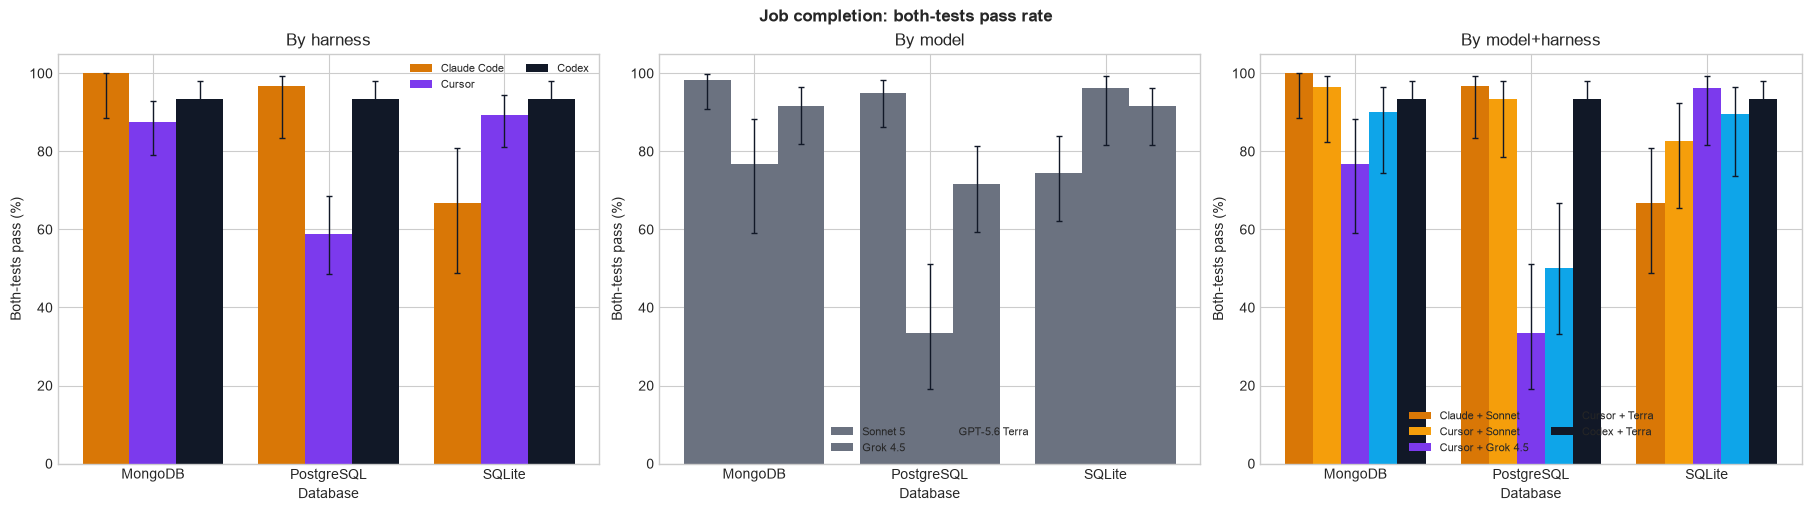

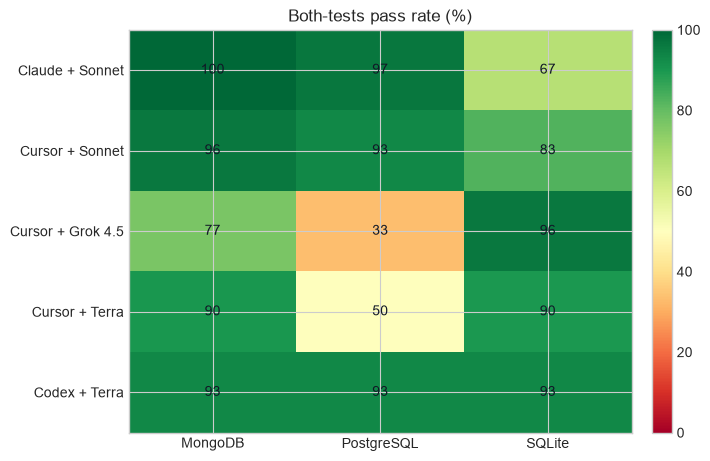

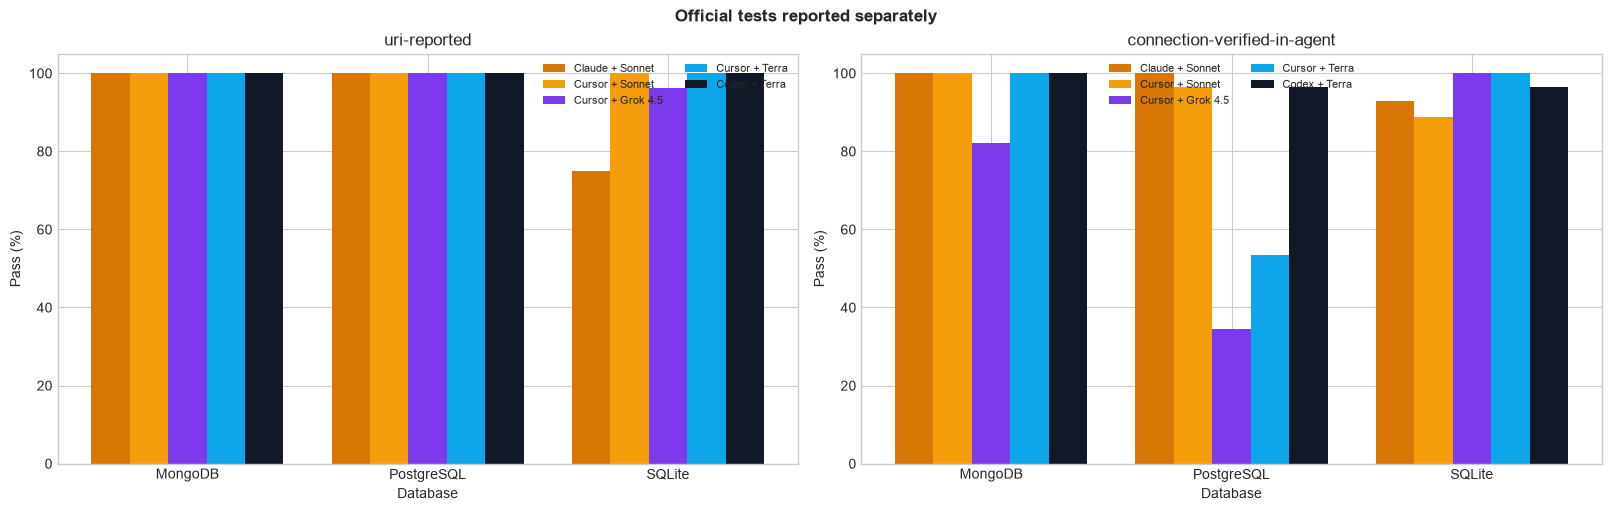

In [5]:
def rate_table(frame, group):
    table = (
        frame.groupby([group, "database"], observed=True)
        .agg(n=("run_id", "size"), passed=("both_tests_passed", "sum"))
        .reset_index()
    )
    intervals = [wilson_interval(row.passed, row.n) for row in table.itertuples()]
    table["pass_rate"] = [item[0] for item in intervals]
    table["pass_rate_lo"] = [item[1] for item in intervals]
    table["pass_rate_hi"] = [item[2] for item in intervals]
    table["pass_rate_pct"] = table["pass_rate"] * 100
    table["pass_rate_lo_pct"] = table["pass_rate_lo"] * 100
    table["pass_rate_hi_pct"] = table["pass_rate_hi"] * 100
    return table

if not READY:
    summary = pd.DataFrame()
    print("Waiting for measurements.")
else:
    by_harness = rate_table(runs, "harness")
    by_model = rate_table(runs, "model")
    by_extension = rate_table(runs, "extension")
    summary = (
        runs.groupby(["extension", "database"], observed=True)
        .agg(
            runs=("run_id", "size"),
            both_tests_passed=("both_tests_passed", "sum"),
            pass_rate=("both_tests_passed", "mean"),
            runtime_mean_s=("runtime_s", "mean"),
            turns_mean=("num_turns", "mean"),
            tool_calls_mean=("tool_calls_total", "mean"),
            cost_mean_usd=("cost_usd", "mean"),
            cost_total_usd=("cost_usd", "sum"),
        )
        .reset_index()
    )
    intervals = [
        wilson_interval(row.both_tests_passed, row.runs) for row in summary.itertuples()
    ]
    summary["pass_rate"] = [item[0] for item in intervals]
    summary["pass_rate_lo"] = [item[1] for item in intervals]
    summary["pass_rate_hi"] = [item[2] for item in intervals]
    summary["pass_rate_pct"] = summary["pass_rate"] * 100

    print("Completion by harness × database:")
    display(by_harness.round(3))
    print("Completion by model × database:")
    display(by_model.round(3))
    print("Completion by model+harness × database:")
    display(by_extension.round(3))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    grouped_bars(
        axes[0], by_harness, "harness", "pass_rate_pct", "By harness",
        "Both-tests pass (%)", percent=True, groups=HARNESS_ORDER,
        lo_column="pass_rate_lo_pct", hi_column="pass_rate_hi_pct",
    )
    grouped_bars(
        axes[1], by_model, "model", "pass_rate_pct", "By model",
        "Both-tests pass (%)", percent=True, groups=MODEL_ORDER,
        lo_column="pass_rate_lo_pct", hi_column="pass_rate_hi_pct",
    )
    grouped_bars(
        axes[2], by_extension, "extension", "pass_rate_pct", "By model+harness",
        "Both-tests pass (%)", percent=True,
        lo_column="pass_rate_lo_pct", hi_column="pass_rate_hi_pct",
    )
    fig.suptitle("Job completion: both-tests pass rate", fontweight="bold")
    plt.show()

    heat = (
        by_extension.pivot(index="extension", columns="database", values="pass_rate_pct")
        .reindex(index=[name for name in EXTENSION_ORDER if name in set(by_extension["extension"])])
        .reindex(columns=DATABASE_ORDER)
    )
    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    image = ax.imshow(heat.to_numpy(dtype=float), cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(heat.columns)), [label_of(name) for name in heat.columns])
    ax.set_yticks(range(len(heat.index)), [label_of(name) for name in heat.index])
    ax.set_title("Both-tests pass rate (%)")
    for row_index, extension in enumerate(heat.index):
        for col_index, database in enumerate(heat.columns):
            value = heat.iat[row_index, col_index]
            if pd.notna(value):
                ax.text(col_index, row_index, f"{value:.0f}", ha="center", va="center", color="#111827")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

    if not tests.empty:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
        for ax, test_name, title in [
            (axes[0], "uri-reported", "uri-reported"),
            (axes[1], "connection-verified-in-agent", "connection-verified-in-agent"),
        ]:
            slice_ = test_summary[test_summary["test_name"] == test_name].copy()
            grouped_bars(ax, slice_, "extension", "rate_pct", title, "Pass (%)", percent=True)
        fig.suptitle("Official tests reported separately", fontweight="bold")
        plt.show()


## Job efficiency: runtime, cost, and turns

Technical design: agent runtime, cost, and **turns / tool use** by database ×
harness/model. Scope viz: completion time and cost per database by harness,
model, and model+harness.

Turns are plotted with the same slices. n=5 showed Codex often finishing in
1 turn while Cursor/Claude used more; scale should show whether that is a
stable efficiency signature.


Efficiency means by model+harness × database:


,extension,database,n,runtime_mean,runtime_median,cost_mean,cost_median,turns_mean,turns_median,tools_mean
0,claude-sonnet,mongodb,30,60.310,59.372,0.232,0.194,6.833,7.0,5.833
1,claude-sonnet,postgresql,30,58.324,42.122,0.203,0.258,5.500,5.0,4.500
2,claude-sonnet,sqlite,30,50.135,36.008,0.177,0.228,4.033,4.0,3.033
3,cursor-sonnet,mongodb,28,59.978,59.638,0.170,0.145,4.071,4.0,5.321
4,cursor-sonnet,postgresql,30,49.378,46.276,0.146,0.130,3.633,3.0,5.400
5,cursor-sonnet,sqlite,29,97.747,95.020,0.306,0.321,4.586,5.0,9.690
6,cursor-grok,mongodb,30,40.137,39.284,0.131,0.129,3.267,3.0,3.133
7,cursor-grok,postgresql,30,39.120,33.317,0.125,0.120,3.033,3.0,3.033
8,cursor-grok,sqlite,27,40.610,39.087,0.181,0.178,3.037,3.0,4.481
9,cursor-terra,mongodb,30,53.789,47.939,0.100,0.097,1.100,1.0,5.533


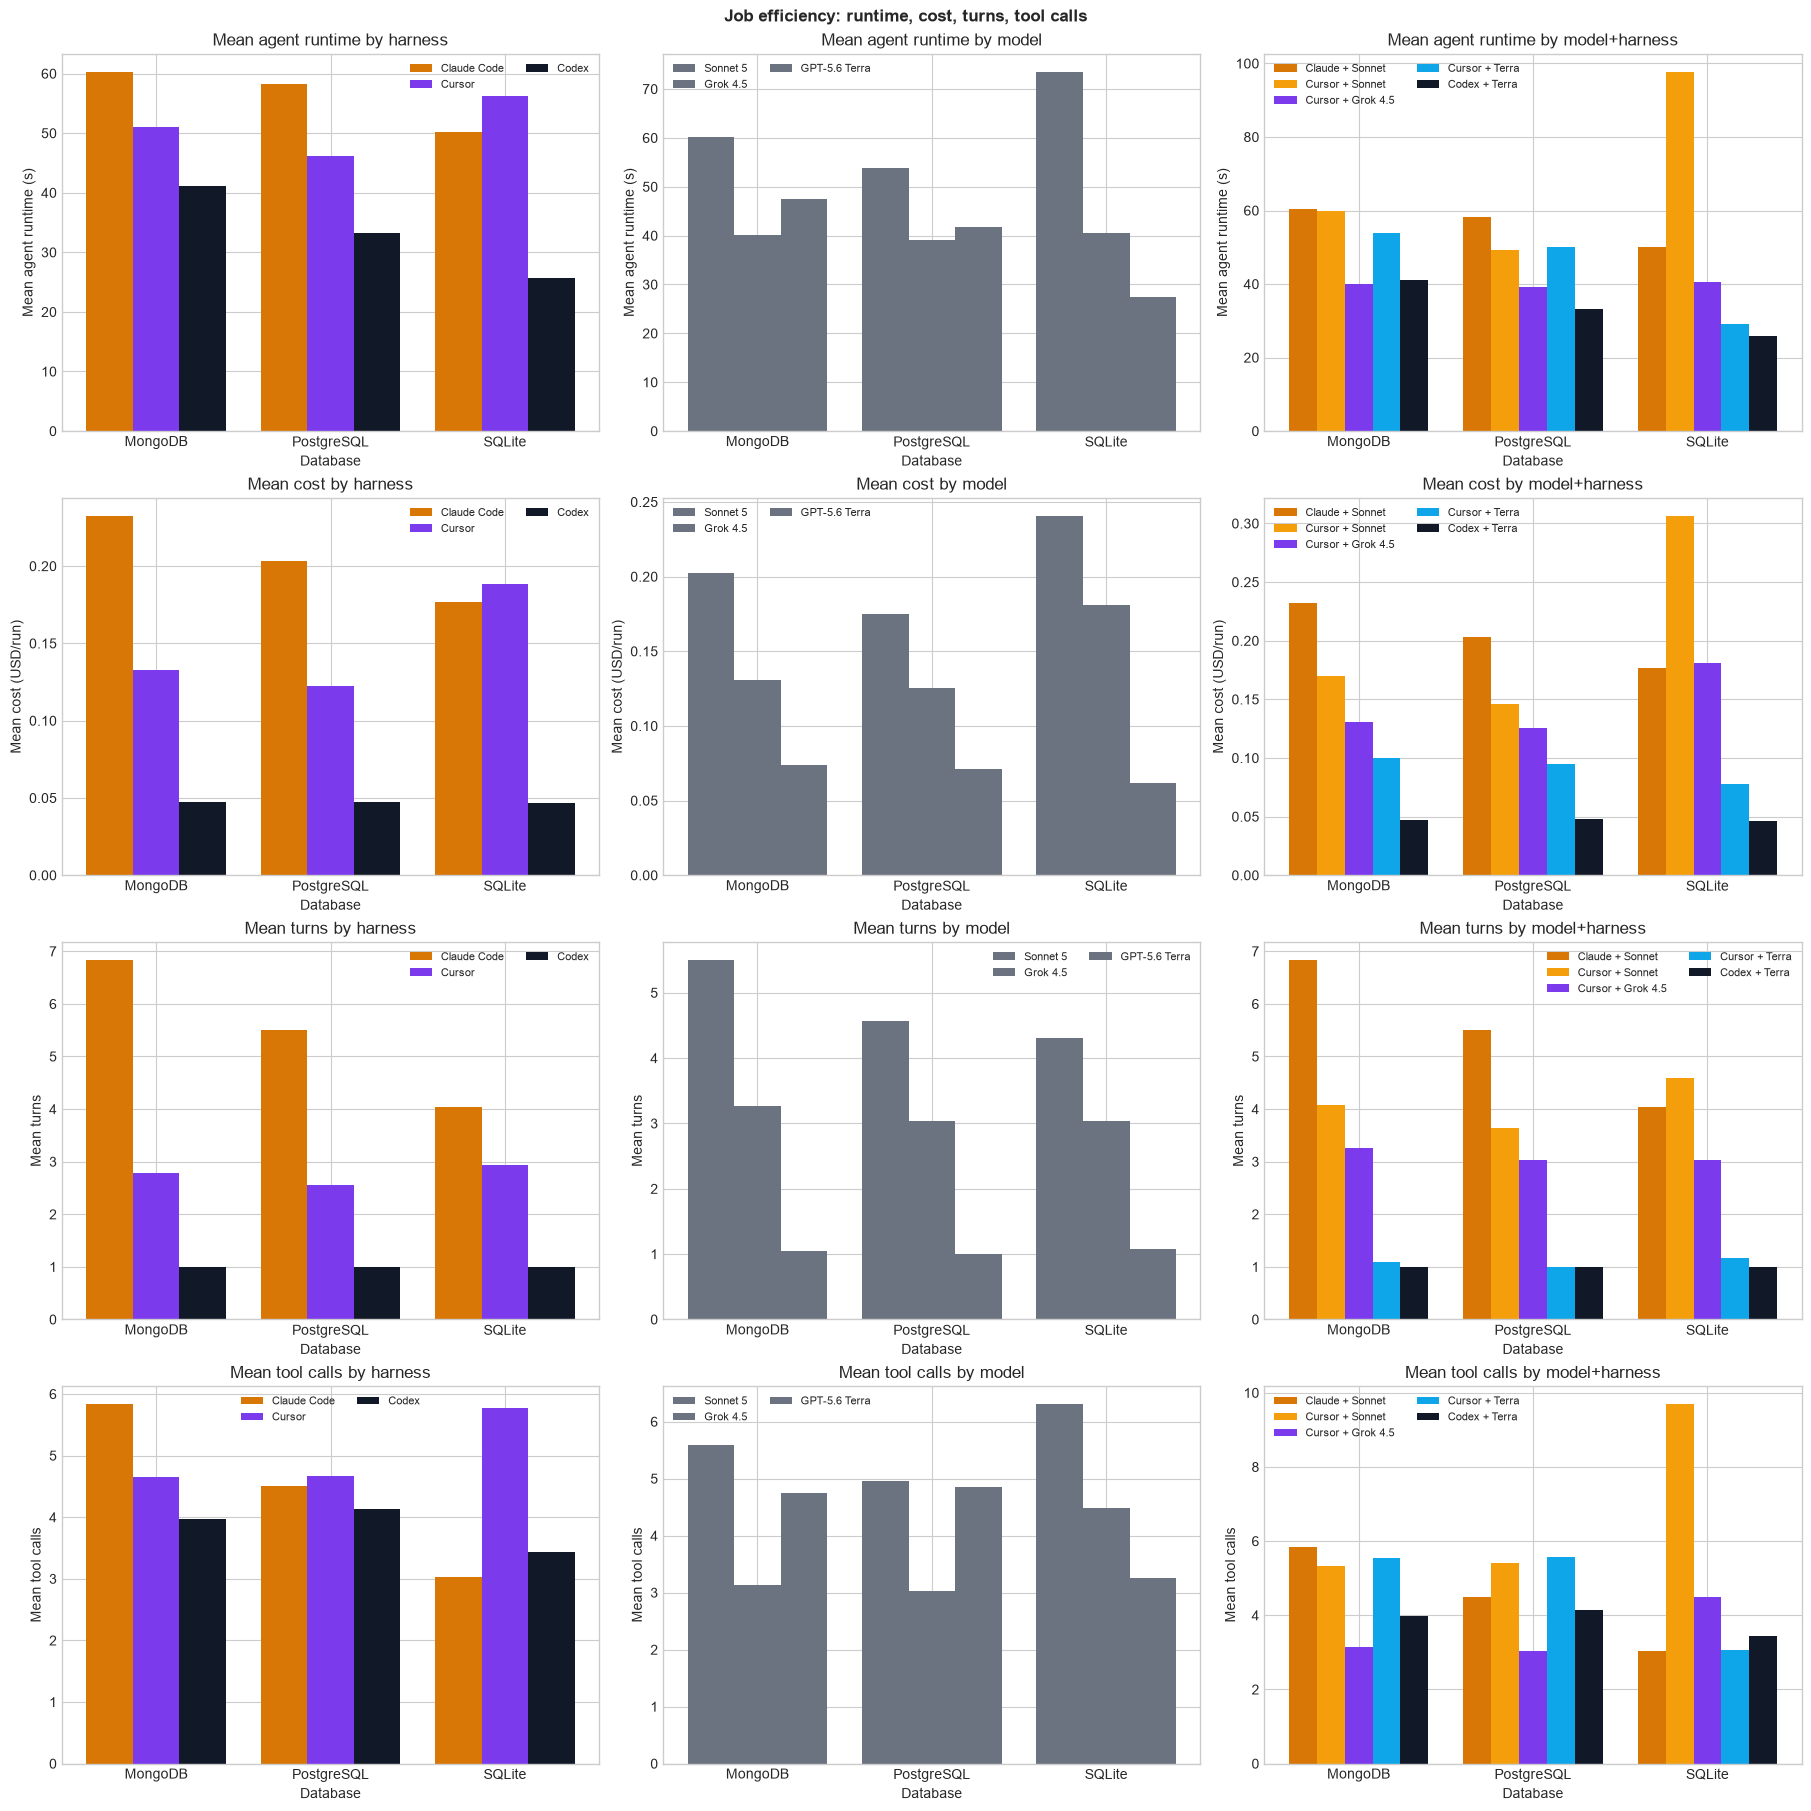

In [6]:
if not READY or summary.empty:
    print("Waiting for measurements.")
else:
    efficiency = (
        runs.groupby(["extension", "database"], observed=True)
        .agg(
            n=("run_id", "size"),
            runtime_mean=("runtime_s", "mean"),
            runtime_median=("runtime_s", "median"),
            cost_mean=("cost_usd", "mean"),
            cost_median=("cost_usd", "median"),
            turns_mean=("num_turns", "mean"),
            turns_median=("num_turns", "median"),
            tools_mean=("tool_calls_total", "mean"),
        )
        .reset_index()
    )
    print("Efficiency means by model+harness × database:")
    display(efficiency.round(3))

    by_h = (
        runs.groupby(["harness", "database"], observed=True)[
            ["runtime_s", "cost_usd", "num_turns", "tool_calls_total"]
        ]
        .mean()
        .reset_index()
        .rename(columns={"runtime_s": "runtime_mean", "cost_usd": "cost_mean", "num_turns": "turns_mean", "tool_calls_total": "tools_mean"})
    )
    by_m = (
        runs.groupby(["model", "database"], observed=True)[
            ["runtime_s", "cost_usd", "num_turns", "tool_calls_total"]
        ]
        .mean()
        .reset_index()
        .rename(columns={"runtime_s": "runtime_mean", "cost_usd": "cost_mean", "num_turns": "turns_mean", "tool_calls_total": "tools_mean"})
    )

    metrics = [
        ("runtime_mean", "Mean agent runtime (s)", False),
        ("cost_mean", "Mean cost (USD/run)", False),
        ("turns_mean", "Mean turns", False),
        ("tools_mean", "Mean tool calls", False),
    ]

    fig, axes = plt.subplots(4, 3, figsize=(18, 18), constrained_layout=True)
    slices = [
        (by_h, "harness", HARNESS_ORDER, "harness"),
        (by_m, "model", MODEL_ORDER, "model"),
        (efficiency.rename(columns={"runtime_mean": "runtime_mean", "cost_mean": "cost_mean", "turns_mean": "turns_mean", "tools_mean": "tools_mean"}), "extension", EXTENSION_ORDER, "model+harness"),
    ]
    # normalize efficiency column names already match
    for row, (metric, ylabel, percent) in enumerate(metrics):
        for col, (frame, group, groups, slice_name) in enumerate(slices):
            grouped_bars(
                axes[row, col],
                frame,
                group,
                metric,
                f"{ylabel.split('(')[0].strip()} by {slice_name}",
                ylabel,
                percent=percent,
                groups=groups,
            )
    fig.suptitle("Job efficiency: runtime, cost, turns, tool calls", fontweight="bold")
    plt.show()


## Turns in detail

n=5 hinted that turns separate cheap one-shot Codex paths from multi-turn
Cursor/Claude exploration. Scale distributions (not just means) show whether
that is a tight cluster or a long tail.


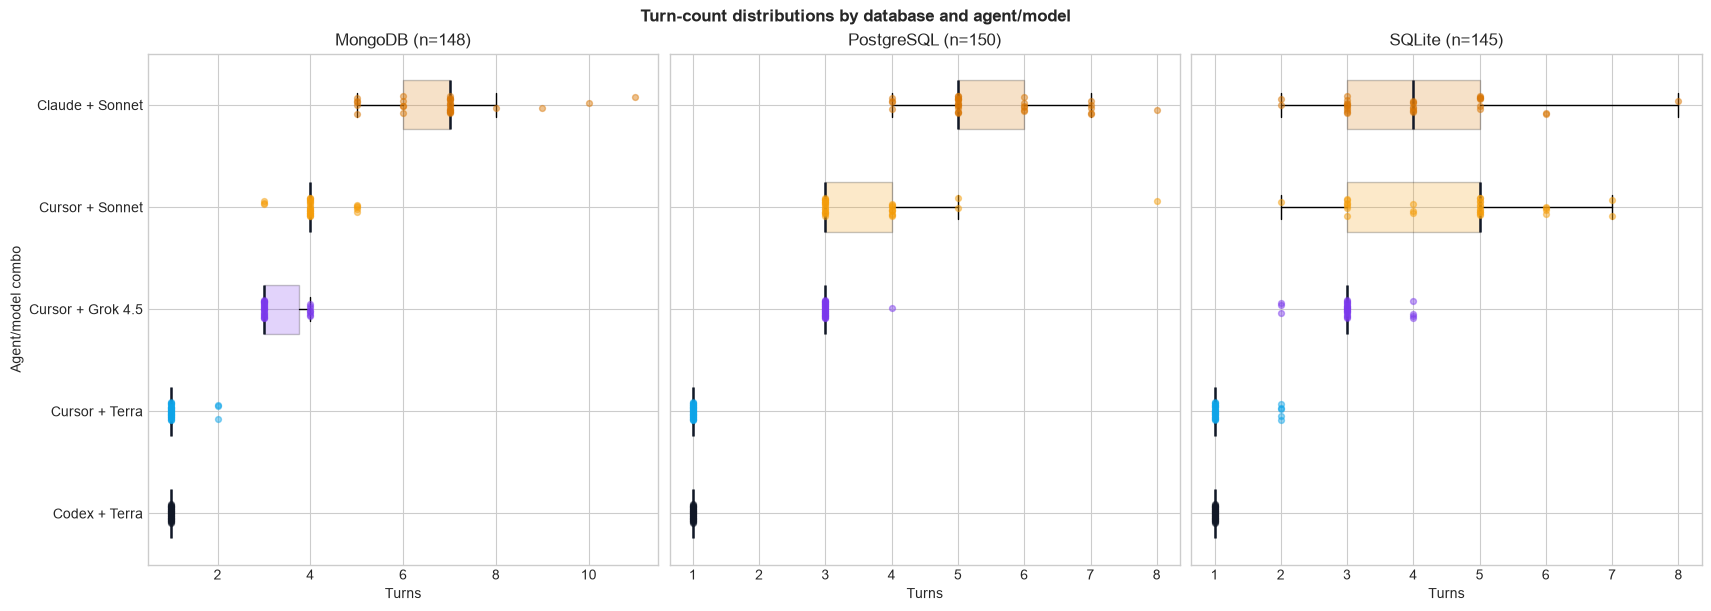

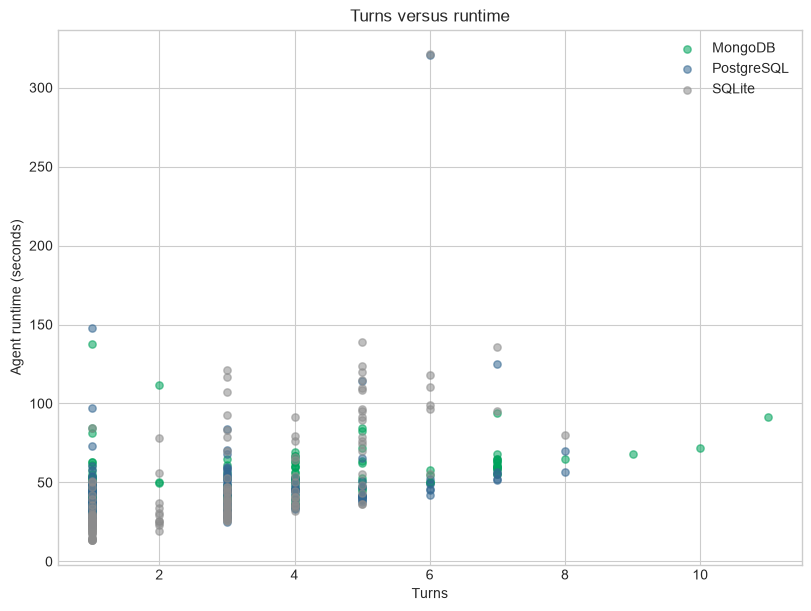

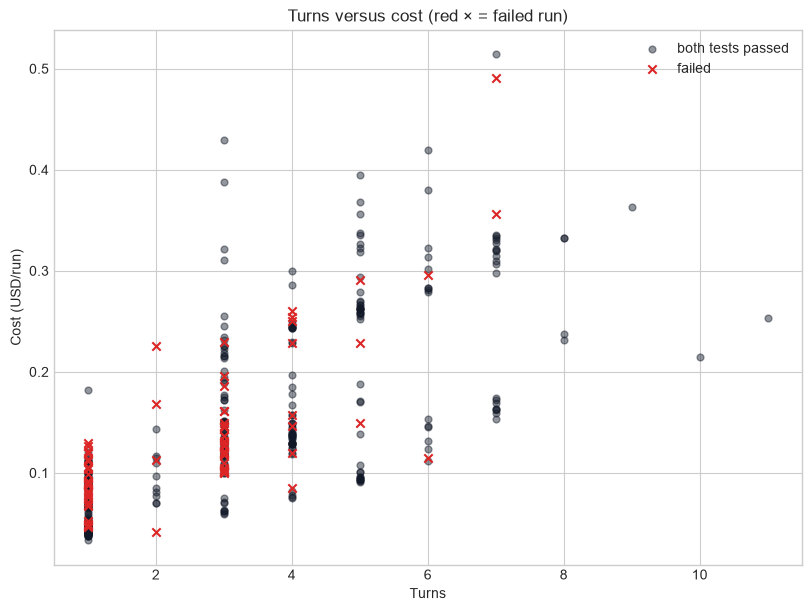

In [7]:
if not READY:
    print("Waiting for measurements.")
else:
    present_extensions = [name for name in EXTENSION_ORDER if name in set(runs["extension"])]
    extension_labels = [label_of(name) for name in present_extensions]
    y_positions = np.arange(len(present_extensions))

    fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        database_runs = runs[runs["database"] == database]
        distributions, positions = [], []
        for y_position, extension in zip(y_positions, present_extensions):
            values = (
                database_runs.loc[database_runs["extension"] == extension, "num_turns"]
                .dropna()
                .to_numpy(dtype=float)
            )
            if not len(values):
                continue
            distributions.append(values)
            positions.append(y_position)
            jitter = np.linspace(-0.09, 0.09, len(values)) if len(values) > 1 else np.array([0.0])
            ax.scatter(values, y_position + jitter, color=COLORS.get(extension, "#6B7280"), alpha=0.45, s=18, zorder=3)
        if distributions:
            boxes = ax.boxplot(
                distributions,
                positions=positions,
                orientation="horizontal",
                widths=0.48,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": "#111827", "linewidth": 1.8},
            )
            for patch, position in zip(boxes["boxes"], positions):
                patch.set_facecolor(COLORS.get(present_extensions[position], "#9CA3AF"))
                patch.set_alpha(0.22)
        ax.set_title(f"{label_of(database)} (n={len(database_runs)})")
        ax.set_xlabel("Turns")
        ax.set_yticks(y_positions, extension_labels)
        ax.invert_yaxis()
    axes[0].set_ylabel("Agent/model combo")
    fig.suptitle("Turn-count distributions by database and agent/model", fontweight="bold")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    for database in DATABASE_ORDER:
        subset = runs[runs["database"] == database]
        ax.scatter(
            subset["num_turns"],
            subset["runtime_s"],
            label=label_of(database),
            color=COLORS[database],
            alpha=0.55,
            s=28,
        )
    ax.set_xlabel("Turns")
    ax.set_ylabel("Agent runtime (seconds)")
    ax.set_title("Turns versus runtime")
    ax.legend(frameon=False)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    passed = runs["both_tests_passed"].to_numpy(dtype=bool)
    ax.scatter(runs.loc[passed, "num_turns"], runs.loc[passed, "cost_usd"], color="#111827", alpha=0.45, s=24, label="both tests passed")
    ax.scatter(runs.loc[~passed, "num_turns"], runs.loc[~passed, "cost_usd"], color="#DC2626", marker="x", s=36, label="failed")
    ax.set_xlabel("Turns")
    ax.set_ylabel("Cost (USD/run)")
    ax.set_title("Turns versus cost (red × = failed run)")
    ax.legend(frameon=False)
    plt.show()


## Compound completion and efficiency: Pareto frontier

Technical design / scope: one series per database; x-axis cost **or** time
(choose from the data); y-axis successful-provision rate. This notebook plots
**both** cost and time, plus turns, so the choice is visible rather than
pre-committed.

Each point is one model+harness cell. Lines connect cells within a database,
sorted by the x-axis. If completion is near-ceiling for a database, the
frontier collapses and the efficiency boxplots above are the better view.


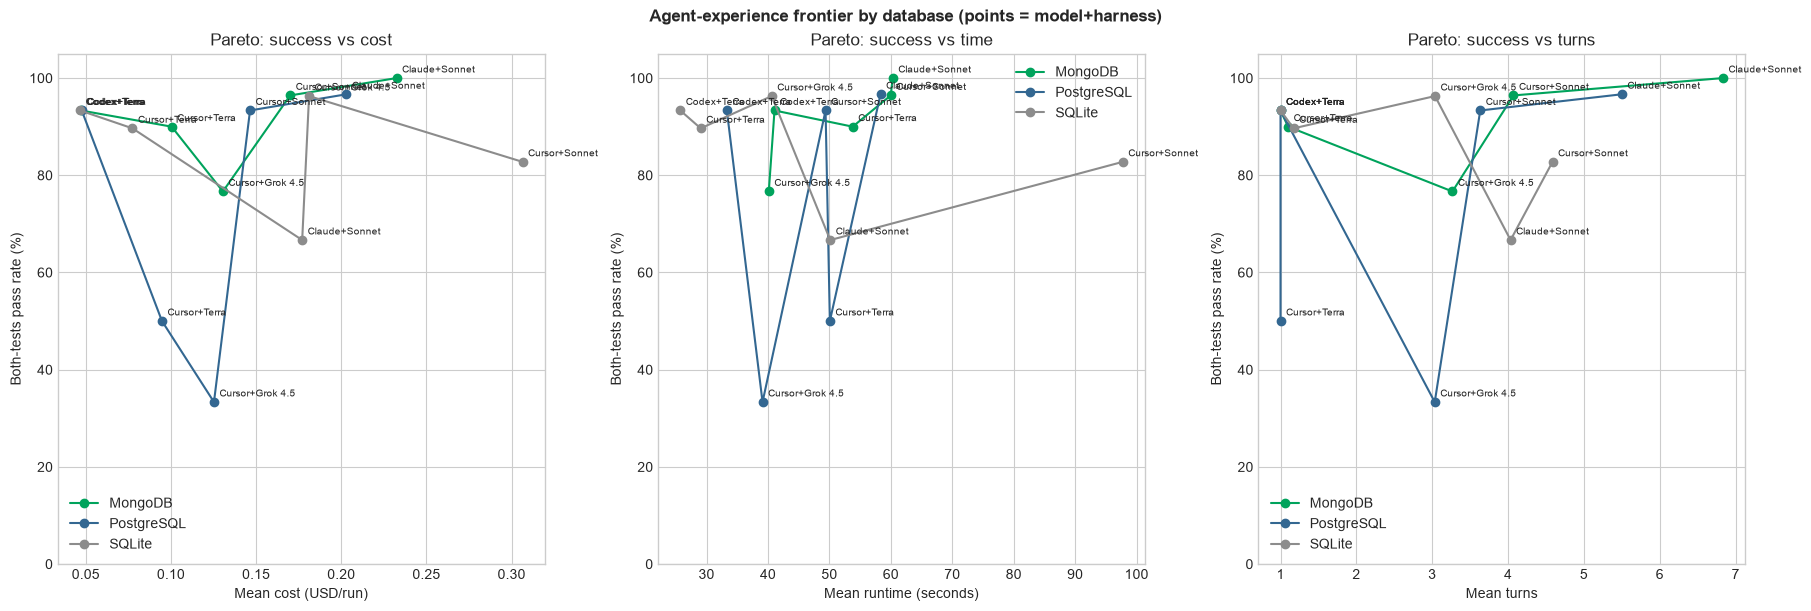

In [8]:
if not READY or summary.empty:
    print("Waiting for measurements.")
else:
    def pareto(ax, x_column, xlabel, title):
        for database in DATABASE_ORDER:
            subset = summary[summary["database"] == database].sort_values(x_column)
            ax.plot(
                subset[x_column],
                subset["pass_rate_pct"],
                marker="o",
                color=COLORS[database],
                label=label_of(database),
            )
            for _, row in subset.iterrows():
                ax.annotate(
                    label_of(row["extension"]).replace(" + ", "+"),
                    (row[x_column], row["pass_rate_pct"]),
                    fontsize=7,
                    xytext=(4, 4),
                    textcoords="offset points",
                )
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Both-tests pass rate (%)")
        ax.set_ylim(0, 105)
        ax.set_title(title)
        ax.legend(frameon=False)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
    pareto(axes[0], "cost_mean_usd", "Mean cost (USD/run)", "Pareto: success vs cost")
    pareto(axes[1], "runtime_mean_s", "Mean runtime (seconds)", "Pareto: success vs time")
    pareto(axes[2], "turns_mean", "Mean turns", "Pareto: success vs turns")
    fig.suptitle("Agent-experience frontier by database (points = model+harness)", fontweight="bold")
    plt.show()


## Provisioning methods

Technical design RQ2: classify with the versioned codebook. `final_method` is
the **last attempted method**, even when tests fail. Do not overwrite that
with `none`.

Outcome is a separate field:

- `verified` — both official tests passed
- `unverified` — tests ran and at least one failed (readiness-only, URI miss, …)
- `unscored` — agent finished but `test_output` was never recorded

Requested views:

1. **Each agent/model × database** — inferred final method per combo
2. **All agent/models × database** — pooled method mix, and method counts
   with method on the x-axis (scope viz)


,extension,database,repeat_idx,attempted_path,final_method,method_outcome,both_tests_passed
0,claude-sonnet,mongodb,0,container,container,verified,True
1,claude-sonnet,mongodb,1,container,container,verified,True
2,claude-sonnet,mongodb,2,container,container,verified,True
3,claude-sonnet,mongodb,3,container,container,verified,True
4,claude-sonnet,mongodb,4,container,container,verified,True
...,...,...,...,...,...,...,...
175,codex-terra,sqlite,25,built-in-library,built-in-library,verified,True
176,codex-terra,sqlite,26,built-in-library,built-in-library,verified,True
177,codex-terra,sqlite,27,built-in-library,built-in-library,verified,True
178,codex-terra,sqlite,28,built-in-library,built-in-library,verified,True


Attempted method counts (a fallback run may appear more than once):


,database,attempted_methods,runs
0,mongodb,container,148
1,postgresql,container,149
2,postgresql,os-package-manager,2
3,sqlite,built-in-library,123
4,sqlite,container,24
5,sqlite,language-package-runtime,4
6,sqlite,official-binary-archive,2
7,sqlite,os-package-manager,9
8,sqlite,preinstalled-runtime,1


Inferred final method counts:


,database,final_method,runs
0,mongodb,container,148
1,postgresql,container,149
2,postgresql,os-package-manager,1
3,sqlite,built-in-library,115
4,sqlite,container,22
5,sqlite,language-package-runtime,4
6,sqlite,official-binary-archive,1
7,sqlite,os-package-manager,2
8,sqlite,preinstalled-runtime,1


Method outcome (tests vs last attempted method):


method_outcome                       verified  unverified  unscored
database   final_method                                            
mongodb    container                      135           5         8
postgresql container                      109          34         6
           os-package-manager               1           0         0
sqlite     built-in-library               101           9         5
           container                       17           3         2
           language-package-runtime         3           0         1
           official-binary-archive          1           0         0
           os-package-manager               2           0         0
           preinstalled-runtime             0           1         0

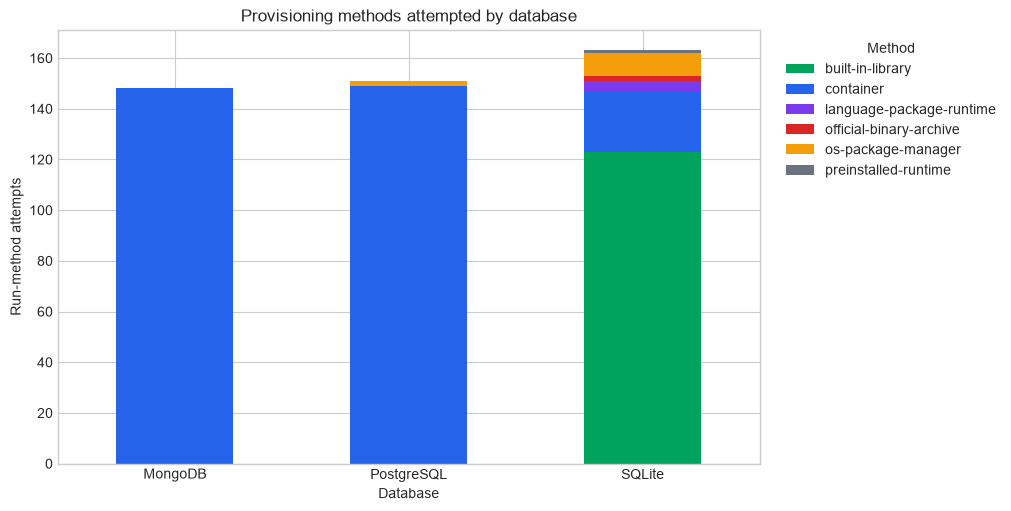

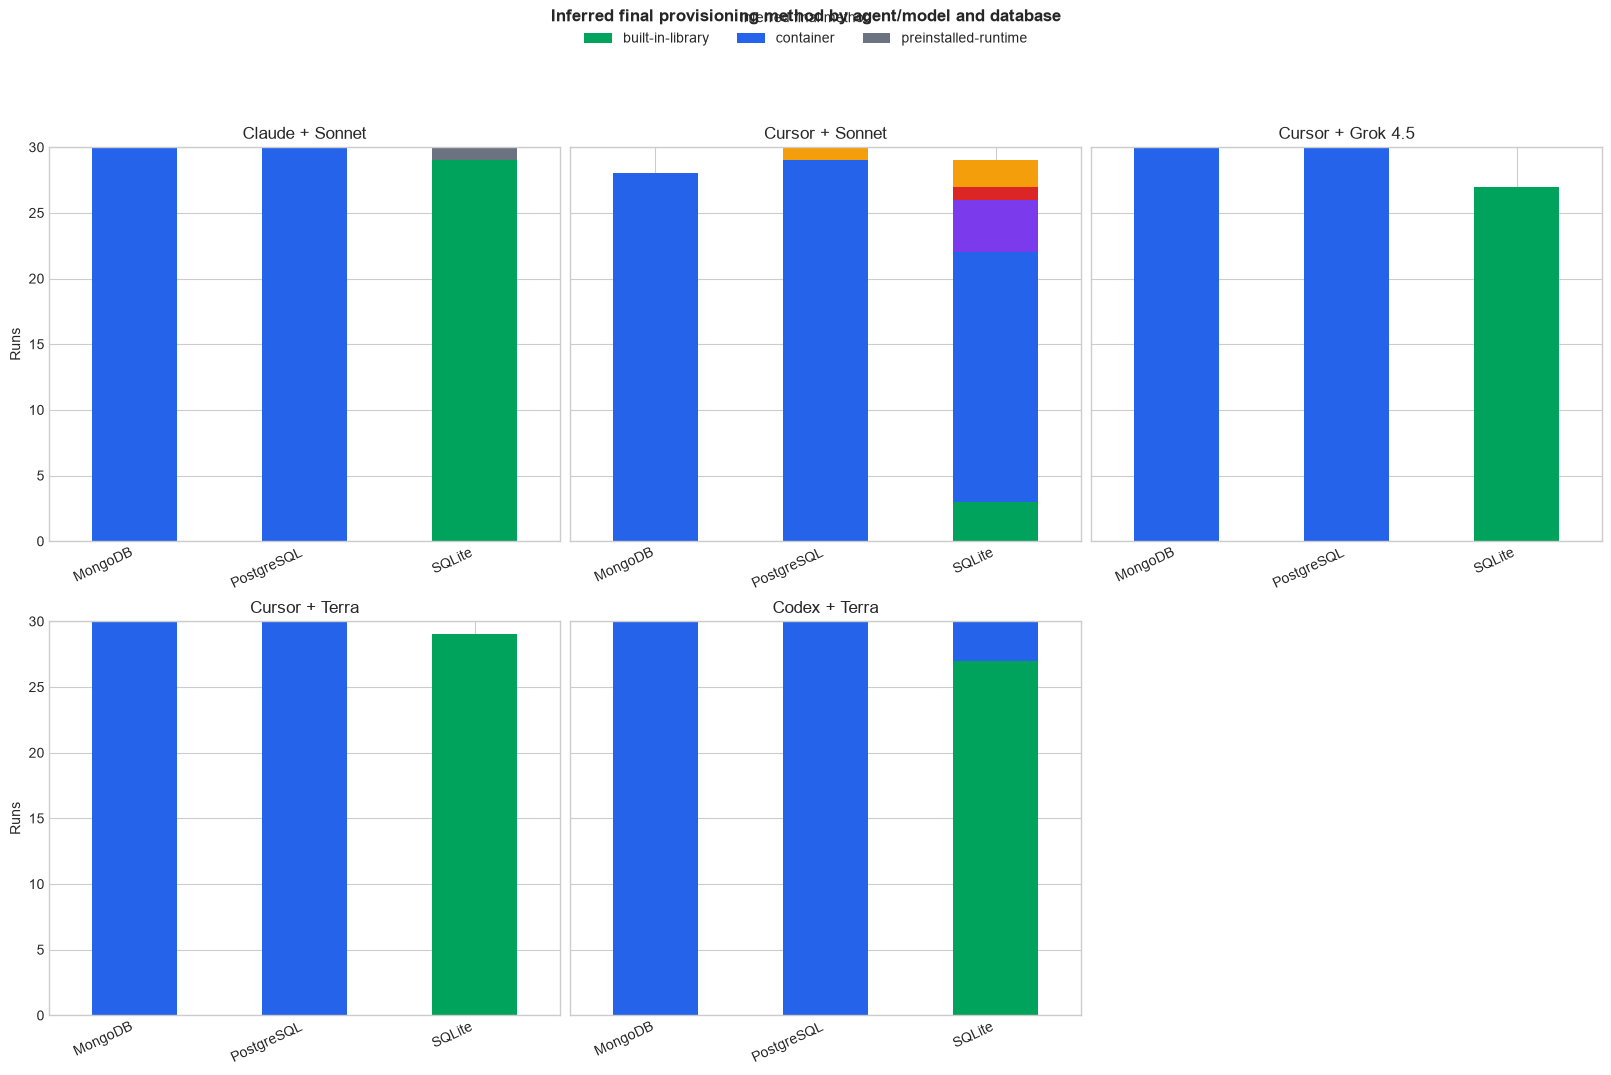

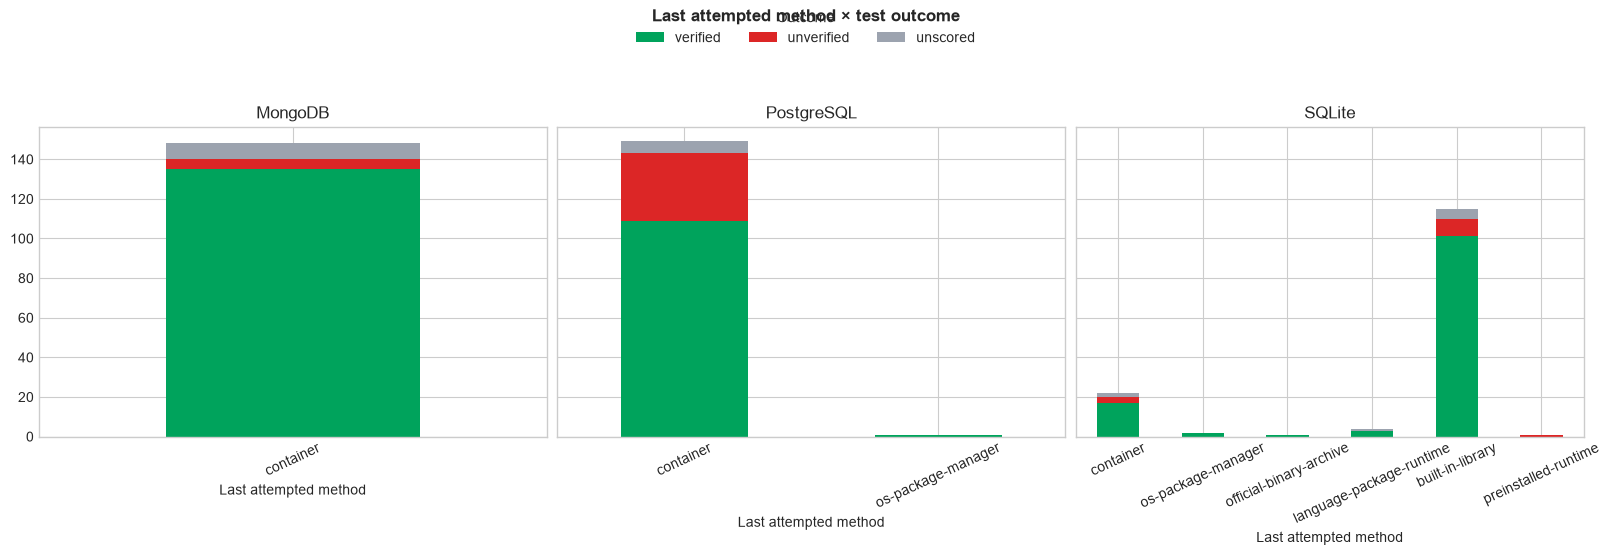

In [9]:
if not READY:
    method_runs = pd.DataFrame()
    print("Waiting for measurements.")
else:
    method_sql = f"""
    SELECT
        run_id,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            positionCaseInsensitive(payload, 'docker run') > 0
            OR positionCaseInsensitive(payload, 'podman run') > 0
        ) AS container_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'apt-get install') > 0
                OR positionCaseInsensitive(payload, 'apt install') > 0
                OR positionCaseInsensitive(payload, 'dnf install') > 0
                OR positionCaseInsensitive(payload, 'yum install') > 0
                OR positionCaseInsensitive(payload, 'apk add') > 0
                OR positionCaseInsensitive(payload, 'brew install') > 0
            )
            AND positionCaseInsensitive(payload, 'docker') = 0
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite') > 0)
            )
        ) AS os_package_manager_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'curl ') > 0
                OR positionCaseInsensitive(payload, 'wget ') > 0
            )
            AND (
                positionCaseInsensitive(payload, '.tgz') > 0
                OR positionCaseInsensitive(payload, '.tar.gz') > 0
                OR positionCaseInsensitive(payload, '.zip') > 0
            )
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite') > 0)
            )
        ) AS official_binary_archive_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'pip install') > 0
                OR positionCaseInsensitive(payload, 'pip3 install') > 0
                OR positionCaseInsensitive(payload, 'npm install') > 0
                OR positionCaseInsensitive(payload, 'npm add') > 0
            )
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND (
                    positionCaseInsensitive(payload, 'sqlite') > 0
                    OR positionCaseInsensitive(payload, 'libsql') > 0
                    OR positionCaseInsensitive(payload, 'sqld') > 0
                ))
            )
        ) AS language_package_runtime_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            prompt_id = 'sqlite'
            AND (
                positionCaseInsensitive(payload, 'import sqlite3') > 0
                OR positionCaseInsensitive(payload, 'from sqlite3') > 0
            )
        ) AS built_in_library_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                (prompt_id = 'mongodb' AND (
                    positionCaseInsensitive(payload, ' mongod ') > 0
                    OR positionCaseInsensitive(payload, 'systemctl start mongod') > 0
                ))
                OR (prompt_id = 'postgresql' AND (
                    positionCaseInsensitive(payload, 'pg_ctl') > 0
                    OR positionCaseInsensitive(payload, 'systemctl start postgres') > 0
                ))
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite3 ') > 0)
            )
        ) AS preinstalled_runtime_seq
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
      AND coalesce(assertion_role, 'primary') = 'primary'
    GROUP BY run_id
    """
    method_evidence = ax_query(method_sql)
    sequence_columns = {
        "container": "container_seq",
        "os-package-manager": "os_package_manager_seq",
        "official-binary-archive": "official_binary_archive_seq",
        "language-package-runtime": "language_package_runtime_seq",
        "built-in-library": "built_in_library_seq",
        "preinstalled-runtime": "preinstalled_runtime_seq",
    }
    if method_evidence.empty:
        method_evidence = pd.DataFrame(columns=["run_id", *sequence_columns.values()])
    for column in sequence_columns.values():
        if column not in method_evidence.columns:
            method_evidence[column] = 0
        method_evidence[column] = pd.to_numeric(method_evidence[column], errors="coerce").fillna(0)

    method_runs = runs.merge(method_evidence, on="run_id", how="left")
    for column in sequence_columns.values():
        method_runs[column] = pd.to_numeric(method_runs[column], errors="coerce").fillna(0)

    def _seq(row, column):
        value = row.get(column, 0)
        if value is None or (isinstance(value, float) and np.isnan(value)) or pd.isna(value):
            return 0
        return int(value)

    def classify_methods(row):
        ordered = [
            (method, _seq(row, column))
            for method, column in sequence_columns.items()
            if _seq(row, column) > 0
        ]
        acquisition_methods = {
            "container",
            "os-package-manager",
            "official-binary-archive",
            "language-package-runtime",
            "built-in-library",
        }
        # Starting software installed by apt/npm is part of that install path,
        # not a separate preinstalled-runtime method.
        if any(method in acquisition_methods for method, _ in ordered):
            ordered = [item for item in ordered if item[0] != "preinstalled-runtime"]
        ordered.sort(key=lambda item: item[1])
        attempted = [method for method, _ in ordered] or ["unknown"]
        passed = bool(row.get("both_tests_passed") is True or row.get("both_tests_passed") == 1)
        n_test_results = int(row.get("test_pass_count") or 0) + int(row.get("test_fail_count") or 0)
        if passed:
            outcome = "verified"
        elif n_test_results > 0:
            outcome = "unverified"
        else:
            outcome = "unscored"
        return attempted, attempted[-1], outcome

    classified = method_runs.apply(classify_methods, axis=1)
    method_runs["attempted_methods"] = [item[0] for item in classified]
    method_runs["final_method"] = [item[1] for item in classified]
    method_runs["method_outcome"] = [item[2] for item in classified]
    method_runs["attempted_path"] = method_runs["attempted_methods"].str.join(" → ")

    method_display = method_runs[
        ["extension", "database", "repeat_idx", "attempted_path", "final_method", "method_outcome", "both_tests_passed"]
    ].sort_values(["database", "extension", "repeat_idx"])
    display(method_display)

    attempted = method_runs[["run_id", "database", "extension", "attempted_methods"]].explode("attempted_methods")
    attempted_counts = (
        attempted.groupby(["database", "attempted_methods"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
    )
    final_counts = (
        method_runs.groupby(["database", "final_method"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
    )
    print("Attempted method counts (a fallback run may appear more than once):")
    display(attempted_counts)
    print("Inferred final method counts:")
    display(final_counts)
    print("Method outcome (tests vs last attempted method):")
    display(
        pd.crosstab(
            [method_runs["database"], method_runs["final_method"]],
            method_runs["method_outcome"],
        )
        .reindex(columns=OUTCOME_ORDER, fill_value=0)
    )

    method_colors = METHOD_COLORS

    attempted_pivot = attempted_counts.pivot(
        index="database", columns="attempted_methods", values="runs"
    ).fillna(0).reindex(DATABASE_ORDER)
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    attempted_pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[method_colors.get(column, "#9CA3AF") for column in attempted_pivot.columns],
    )
    ax.set_title("Provisioning methods attempted by database")
    ax.set_xlabel("Database")
    ax.set_ylabel("Run-method attempts")
    ax.set_xticklabels([DISPLAY_NAMES[name] for name in DATABASE_ORDER], rotation=0)
    ax.legend(title="Method", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    present_extensions = [name for name in EXTENSION_ORDER if name in set(method_runs["extension"])]
    n_ext = max(len(present_extensions), 1)
    nrows = 2 if n_ext > 3 else 1
    ncols = 3 if n_ext > 1 else 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), sharey=True, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, extension in zip(axes.flat, present_extensions):
        subset = method_runs[method_runs["extension"] == extension]
        pivot = pd.crosstab(subset["database"], subset["final_method"]).reindex(DATABASE_ORDER, fill_value=0)
        pivot.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=[method_colors.get(column, "#9CA3AF") for column in pivot.columns],
            legend=False,
        )
        ax.set_title(DISPLAY_NAMES.get(extension, extension))
        ax.set_xlabel("")
        ax.set_ylabel("Runs")
        ax.set_xticklabels([DISPLAY_NAMES[name] for name in DATABASE_ORDER], rotation=25, ha="right")
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Inferred final method", loc="outside upper center", ncol=4, frameon=False)
    for ax in axes[len(present_extensions):]:
        ax.set_visible(False)
    fig.suptitle("Inferred final provisioning method by agent/model and database", y=1.06, fontweight="bold")
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        subset = method_runs[method_runs["database"] == database]
        pivot = (
            pd.crosstab(subset["final_method"], subset["method_outcome"])
            .reindex(
                [name for name in METHOD_ORDER if name in set(subset["final_method"])],
                fill_value=0,
            )
            .reindex(columns=OUTCOME_ORDER, fill_value=0)
        )
        pivot.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=[OUTCOME_COLORS[name] for name in pivot.columns],
            legend=False,
        )
        ax.set_title(label_of(database))
        ax.set_xlabel("Last attempted method")
        ax.tick_params(axis="x", rotation=25)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Outcome", loc="outside upper center", ncol=3, frameon=False)
    fig.suptitle("Last attempted method × test outcome", y=1.08, fontweight="bold")
    plt.show()


## Provisioning method by each agent/model × database

Same codebook labels, different cut: one panel per database, x-axis is the
pinned agent/model combo. This is the scale-run answer to "what method did
each combo actually use?"


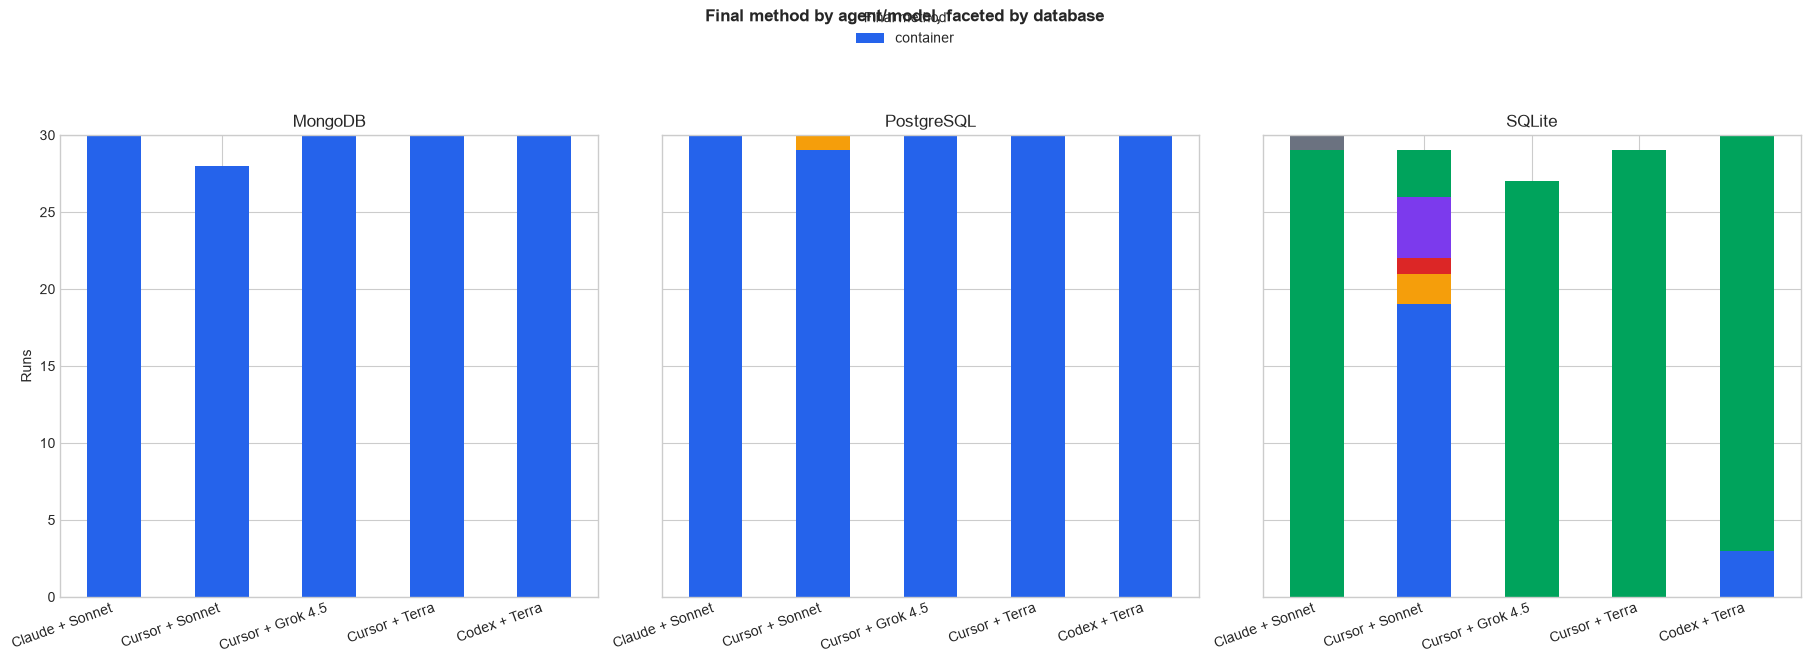

Final method counts by agent/model × database:


final_method              container  os-package-manager  \
extension     database                                    
claude-sonnet mongodb            30                   0   
              postgresql         30                   0   
              sqlite              0                   0   
cursor-sonnet mongodb            28                   0   
              postgresql         29                   1   
              sqlite             19                   2   
cursor-grok   mongodb            30                   0   
              postgresql         30                   0   
              sqlite              0                   0   
cursor-terra  mongodb            30                   0   
              postgresql         30                   0   
              sqlite              0                   0   
codex-terra   mongodb            30                   0   
              postgresql         30                   0   
              sqlite              3                   0   

final_method              official-binary-archive  language-package-runtime  \
extension     database                                                        
claude-sonnet mongodb                           0                         0   
              postgresql                        0                         0   
              sqlite                            0                         0   
cursor-sonnet mongodb                           0                         0   
              postgresql                        0                         0   
              sqlite                            1                         4   
cursor-grok   mongodb                           0                         0   
              postgresql                        0                         0   
              sqlite                            0                         0   
cursor-terra  mongodb                           0                         0   
              postgresql                        0                         0   
              sqlite                            0                         0   
codex-terra   mongodb                           0                         0   
              postgresql                        0                         0   
              sqlite                            0                         0   

final_method              built-in-library  preinstalled-runtime  
extension     database                                            
claude-sonnet mongodb                    0                     0  
              postgresql                 0                     0  
              sqlite                    29                     1  
cursor-sonnet mongodb                    0                     0  
              postgresql                 0                     0  
              sqlite                     3                     0  
cursor-grok   mongodb                    0                     0  
              postgresql                 0                     0  
              sqlite                    27                     0  
cursor-terra  mongodb                    0                     0  
              postgresql                 0                     0  
              sqlite                    29                     0  
codex-terra   mongodb                    0                     0  
              postgresql                 0                     0  
              sqlite                    27                     0

In [10]:
if not READY or "method_runs" not in globals() or method_runs.empty:
    print("Waiting for method classification.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        stacked_method_bars(
            ax,
            method_runs[method_runs["database"] == database],
            "extension",
            EXTENSION_ORDER,
            label_of(database),
        )
        ax.set_ylabel("Runs")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Final method", loc="outside upper center", ncol=4, frameon=False)
    fig.suptitle("Final method by agent/model, faceted by database", y=1.08, fontweight="bold")
    plt.show()

    print("Final method counts by agent/model × database:")
    display(
        pd.crosstab(
            [method_runs["extension"], method_runs["database"]],
            method_runs["final_method"],
        )
        .reindex(columns=[name for name in METHOD_ORDER if name in set(method_runs["final_method"])], fill_value=0)
    )


## Provisioning method by harness and by model

Scope viz: method mix per database sliced by harness and by model, not only
by the pinned model+harness extension.


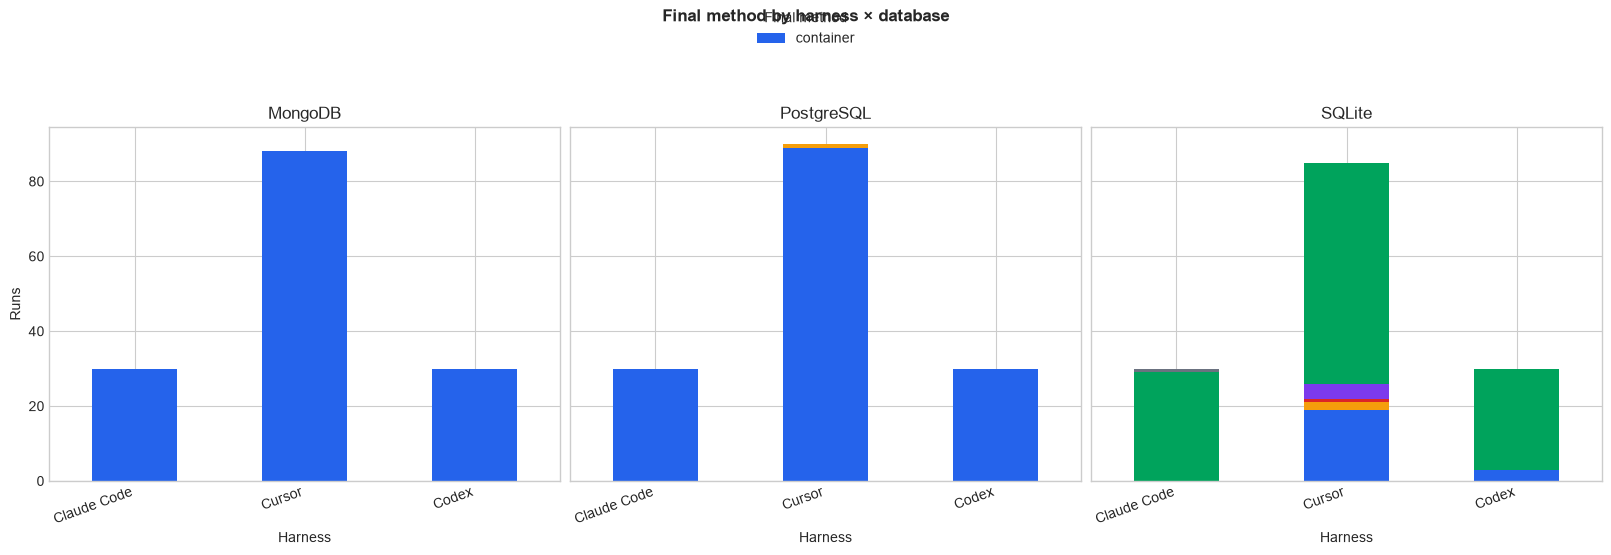

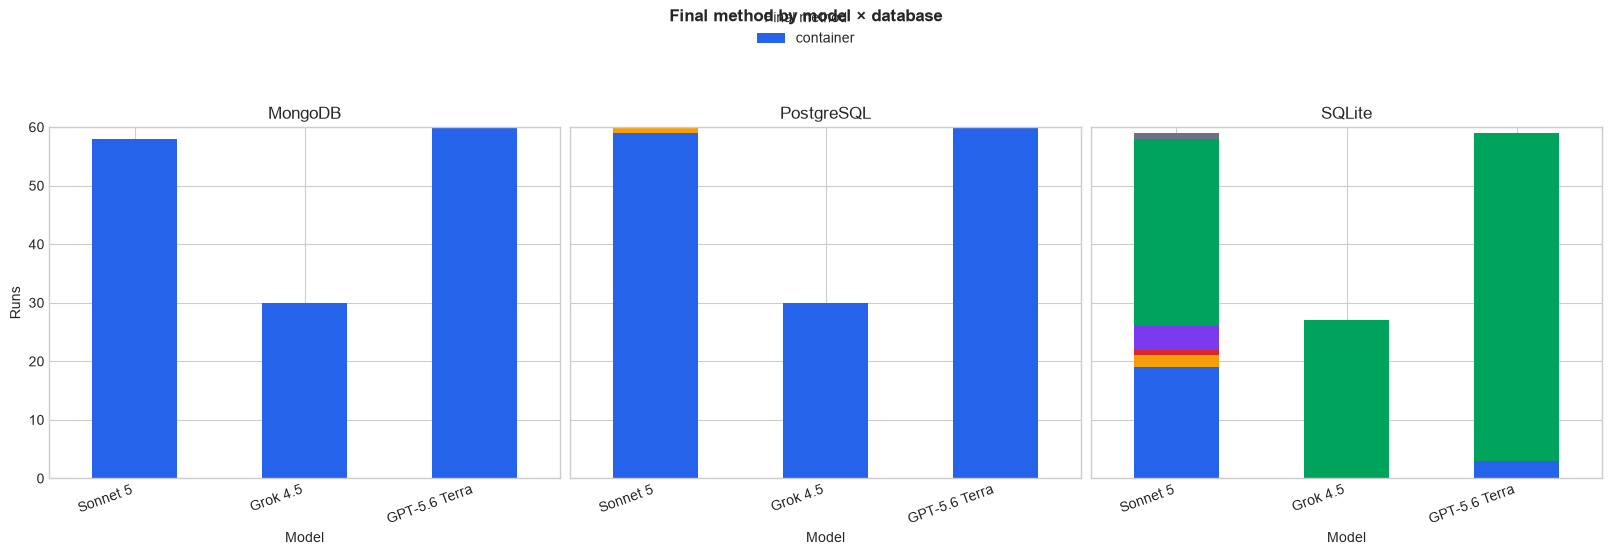

In [11]:
if not READY or "method_runs" not in globals() or method_runs.empty:
    print("Waiting for method classification.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        stacked_method_bars(
            ax,
            method_runs[method_runs["database"] == database],
            "harness",
            HARNESS_ORDER,
            label_of(database),
        )
        ax.set_xlabel("Harness")
        ax.set_ylabel("Runs")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Final method", loc="outside upper center", ncol=4, frameon=False)
    fig.suptitle("Final method by harness × database", y=1.08, fontweight="bold")
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        stacked_method_bars(
            ax,
            method_runs[method_runs["database"] == database],
            "model",
            MODEL_ORDER,
            label_of(database),
        )
        ax.set_xlabel("Model")
        ax.set_ylabel("Runs")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Final method", loc="outside upper center", ncol=4, frameon=False)
    fig.suptitle("Final method by model × database", y=1.08, fontweight="bold")
    plt.show()


## Provisioning method: pooled across all agent/models

X-axis is the codebook method; y-axis is run count. Facet by database, then
one pooled bar across databases (scope viz: method across DBs).


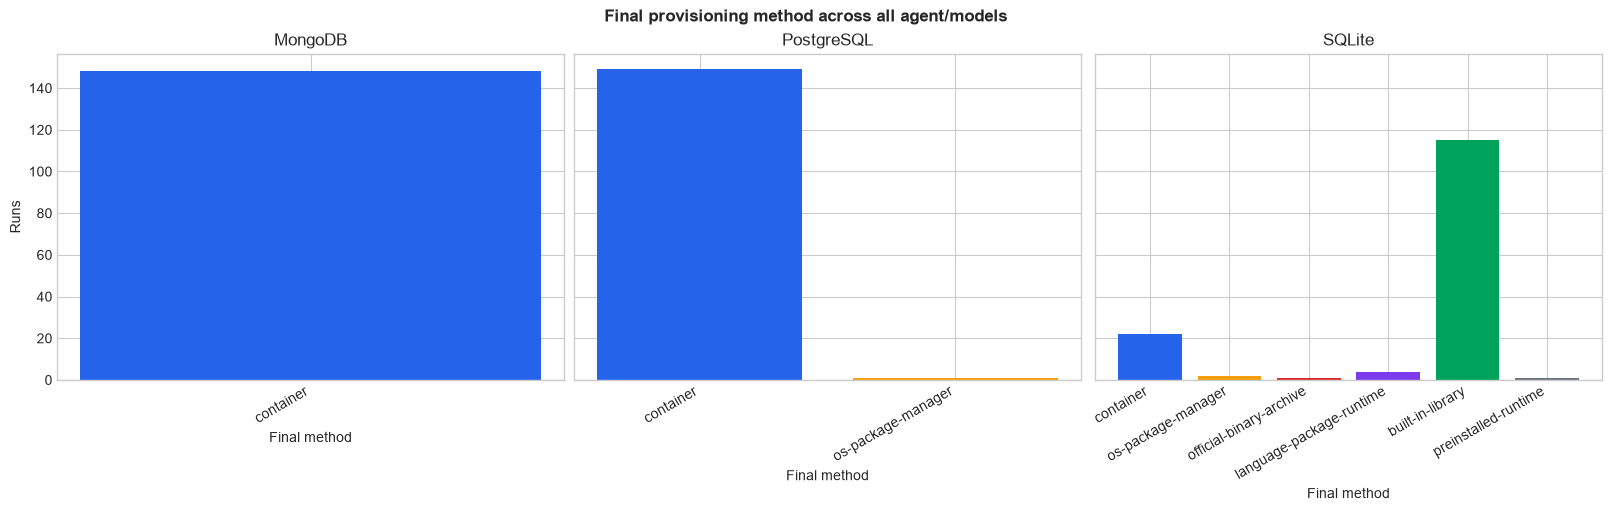

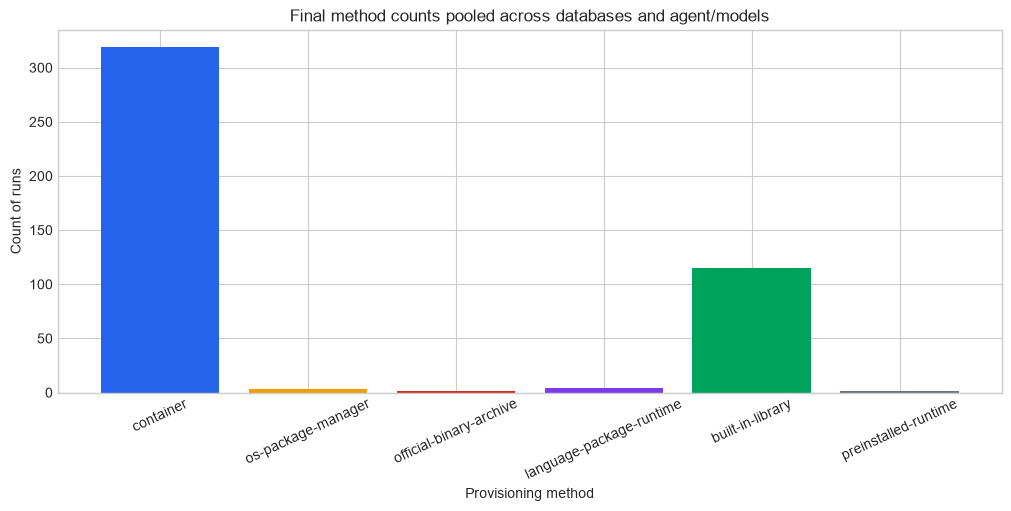

Attempted-path sequences (top 20):


,database,extension,attempted_path,runs
0,mongodb,claude-sonnet,container,30
2,mongodb,cursor-grok,container,30
3,mongodb,cursor-terra,container,30
4,mongodb,codex-terra,container,30
5,postgresql,claude-sonnet,container,30
9,postgresql,cursor-grok,container,30
10,postgresql,cursor-terra,container,30
11,postgresql,codex-terra,container,30
25,sqlite,cursor-terra,built-in-library,29
12,sqlite,claude-sonnet,built-in-library,29


In [12]:
if not READY or "method_runs" not in globals() or method_runs.empty:
    print("Waiting for method classification.")
else:
    method_order = [name for name in METHOD_ORDER if name in set(method_runs["final_method"])]
    final_by_db = (
        method_runs.groupby(["database", "final_method"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
    )
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        subset = final_by_db[final_by_db["database"] == database]
        methods = [name for name in method_order if name in set(subset["final_method"])]
        counts = [
            int(subset.loc[subset["final_method"] == name, "runs"].sum()) for name in methods
        ]
        ax.bar(methods, counts, color=[METHOD_COLORS.get(name, "#9CA3AF") for name in methods])
        ax.set_title(label_of(database))
        ax.set_xlabel("Final method")
        ax.tick_params(axis="x", rotation=30)
        for label in ax.get_xticklabels():
            label.set_ha("right")
    axes[0].set_ylabel("Runs")
    fig.suptitle("Final provisioning method across all agent/models", fontweight="bold")
    plt.show()

    pooled = (
        method_runs.groupby("final_method", observed=True)
        .size()
        .reindex([name for name in method_order if name in set(method_runs["final_method"])])
        .fillna(0)
    )
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.bar(
        pooled.index.astype(str),
        pooled.to_numpy(),
        color=[METHOD_COLORS.get(name, "#9CA3AF") for name in pooled.index],
    )
    ax.set_xlabel("Provisioning method")
    ax.set_ylabel("Count of runs")
    ax.set_title("Final method counts pooled across databases and agent/models")
    ax.tick_params(axis="x", rotation=25)
    plt.show()

    print("Attempted-path sequences (top 20):")
    display(
        method_runs.groupby(["database", "extension", "attempted_path"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
        .sort_values("runs", ascending=False)
        .head(20)
    )


## Completion and efficiency by final method × database

Does container-vs-stdlib explain SQLite runtime the way it did at n=5? Does
Postgres completion stay an `unverified` / `unscored` outcome on a container
path, rather than a missing Docker method?


,database,final_method,n,pass_rate,runtime_mean,cost_mean,turns_mean,pass_rate_pct
0,mongodb,container,148,0.912,50.936,0.136,3.243,91.216
1,postgresql,container,149,0.732,45.879,0.123,2.799,73.154
2,postgresql,os-package-manager,1,1.000,70.194,0.237,8.000,100.000
3,sqlite,built-in-library,115,0.878,37.645,0.126,2.409,87.826
4,sqlite,container,22,0.773,88.046,0.253,3.773,77.273
5,sqlite,language-package-runtime,4,0.750,107.472,0.354,5.750,75.000
6,sqlite,official-binary-archive,1,1.000,98.854,0.322,6.000,100.000
7,sqlite,os-package-manager,2,1.000,108.790,0.365,4.500,100.000
8,sqlite,preinstalled-runtime,1,0.000,37.167,0.225,2.000,0.000


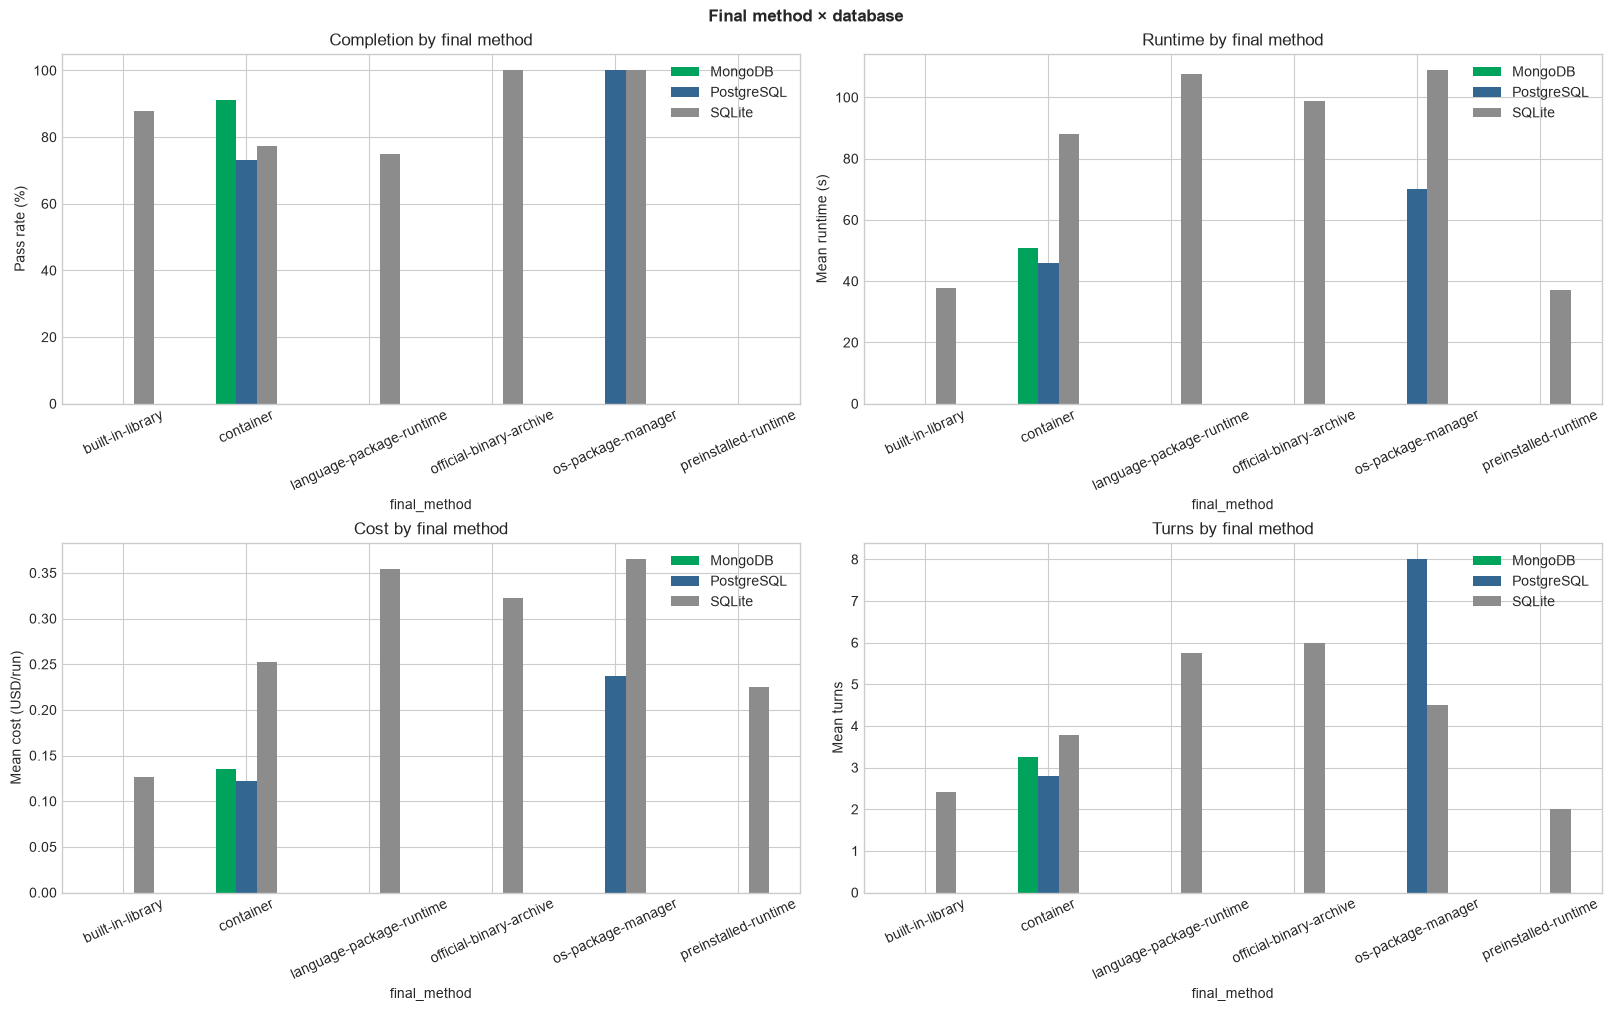

Final method by agent/model × database (counts):


,extension,database,final_method,n
0,claude-sonnet,mongodb,container,30
1,claude-sonnet,postgresql,container,30
2,claude-sonnet,sqlite,built-in-library,29
3,claude-sonnet,sqlite,preinstalled-runtime,1
4,cursor-sonnet,mongodb,container,28
5,cursor-sonnet,postgresql,container,29
6,cursor-sonnet,postgresql,os-package-manager,1
7,cursor-sonnet,sqlite,built-in-library,3
8,cursor-sonnet,sqlite,container,19
9,cursor-sonnet,sqlite,language-package-runtime,4


In [13]:
if not READY or "method_runs" not in globals() or method_runs.empty:
    print("Waiting for method classification.")
else:
    by_method = (
        method_runs.groupby(["database", "final_method"], observed=True)
        .agg(
            n=("run_id", "size"),
            pass_rate=("both_tests_passed", "mean"),
            runtime_mean=("runtime_s", "mean"),
            cost_mean=("cost_usd", "mean"),
            turns_mean=("num_turns", "mean"),
        )
        .reset_index()
    )
    by_method["pass_rate_pct"] = by_method["pass_rate"] * 100
    display(by_method.round(3))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    for ax, metric, ylabel, title in [
        (axes[0, 0], "pass_rate_pct", "Pass rate (%)", "Completion by final method"),
        (axes[0, 1], "runtime_mean", "Mean runtime (s)", "Runtime by final method"),
        (axes[1, 0], "cost_mean", "Mean cost (USD/run)", "Cost by final method"),
        (axes[1, 1], "turns_mean", "Mean turns", "Turns by final method"),
    ]:
        pivot = by_method.pivot(index="final_method", columns="database", values=metric)
        pivot.plot(
            kind="bar",
            ax=ax,
            color=[COLORS[name] for name in pivot.columns],
        )
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend([label_of(name) for name in pivot.columns], frameon=False)
        ax.tick_params(axis="x", rotation=25)
    fig.suptitle("Final method × database", fontweight="bold")
    plt.show()

    print("Final method by agent/model × database (counts):")
    display(
        method_runs.groupby(["extension", "database", "final_method"], observed=True)
        .size()
        .rename("n")
        .reset_index()
    )


## Validity flags (boolean evidence only)

Codebook flags that would drop a run from primary completion: external cloud
service, inherited credentials, pre-existing database. Counts only — no hosts,
URIs, or payloads.


In [14]:
if not READY:
    print("Waiting for measurements.")
else:
    validity_sql = f"""
    SELECT
        run_id,
        countIf(
            positionCaseInsensitive(payload, 'mongodb.net') > 0
            OR positionCaseInsensitive(payload, 'atlas.mongodb') > 0
            OR positionCaseInsensitive(payload, 'supabase') > 0
            OR positionCaseInsensitive(payload, 'neon.tech') > 0
        ) AS external_service_hits,
        countIf(positionCaseInsensitive(payload, 'MONGODB_URI') > 0
             OR positionCaseInsensitive(payload, 'DATABASE_URL') > 0) AS inherited_credential_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
    GROUP BY run_id
    """
    validity = ax_query(validity_sql)
    flagged = runs.merge(validity, on="run_id", how="left")
    print("Runs with at least one matching tool-call (not event counts):")
    display(
        pd.DataFrame(
            {
                "external_service": [
                    int(flagged["external_service_hits"].fillna(0).gt(0).sum())
                ],
                "inherited_credential_hint": [
                    int(flagged["inherited_credential_hits"].fillna(0).gt(0).sum())
                ],
                "n": [len(flagged)],
            }
        )
    )


Runs with at least one matching tool-call (not event counts):


,external_service,inherited_credential_hint,n
0,0,3,443


## Docker contract (design bet)

Bet: MongoDB/PostgreSQL use ordinary `docker run -p`; SQLite stays on a file
DB. Guard hits should be 0. Leftover `--network host` is habit, not required.


In [15]:
if not READY:
    print("Waiting for measurements.")
else:
    docker_sql = f"""
    SELECT
        run_id,
        countIf(positionCaseInsensitive(payload, 'docker run') > 0) AS docker_run_hits,
        countIf(position(payload, '27017:27017') > 0 OR position(payload, '5432:5432') > 0
             OR positionCaseInsensitive(payload, '--publish') > 0
             OR match(payload, '-p [0-9]+:[0-9]+')) AS publish_port_hits,
        countIf(positionCaseInsensitive(payload, '--network host') > 0
             OR positionCaseInsensitive(payload, '--network=host') > 0) AS host_network_hits,
        countIf(positionCaseInsensitive(payload, 'Docker bridge networking is unavailable') > 0) AS guard_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
    GROUP BY run_id
    """
    docker_flags = ax_query(docker_sql)
    docker_runs = runs.merge(docker_flags, on="run_id", how="left")
    summary_flags = (
        docker_runs.groupby("database", observed=True)
        .agg(
            n=("run_id", "size"),
            docker_run=("docker_run_hits", lambda s: s.fillna(0).gt(0).sum()),
            published_port=("publish_port_hits", lambda s: s.fillna(0).gt(0).sum()),
            host_network=("host_network_hits", lambda s: s.fillna(0).gt(0).sum()),
            guard=("guard_hits", lambda s: s.fillna(0).gt(0).sum()),
        )
        .reindex(DATABASE_ORDER)
        .reset_index()
    )
    display(summary_flags)
    print(
        f"Guard hits: {int(docker_runs['guard_hits'].fillna(0).gt(0).sum())}/{len(docker_runs)}."
    )


,database,n,docker_run,published_port,host_network,guard
0,mongodb,148,148,148,0,0
1,postgresql,150,149,148,19,0
2,sqlite,145,24,22,0,0


Guard hits: 0/443.


## Docker image tags

What agents actually reach for on `docker run` / `docker pull`. Counts are
per finished run from tool-call boolean evidence (no payloads, no URIs).

Tracked families:

- `mongodb/mongodb-community-server` — official MongoDB image
- `mongo:latest` vs pinned majors (`mongo:7`, `mongo:8`)
- Postgres comparison: `postgres:16-alpine` / `postgres:16` / `postgres:latest`

A run that mentions both a pinned major and `:latest` is labeled as the pin
(the numbered tag is the image they asked Docker to start).


Image family by database (one label per run):


,database,image_family,n
0,mongodb,mongo:8,47
1,mongodb,mongo:7,46
2,mongodb,mongo:latest,55
3,postgresql,postgres:16-alpine,42
4,postgresql,postgres:16,92
5,postgresql,postgres:latest,1
6,postgresql,postgres (untagged),1
7,postgresql,other/unknown,14


Mongo runs that mention both a pinned major and mongo:latest: 4 (labeled as the pin).
mongodb/mongodb-community-server: 0/148 Mongo runs.


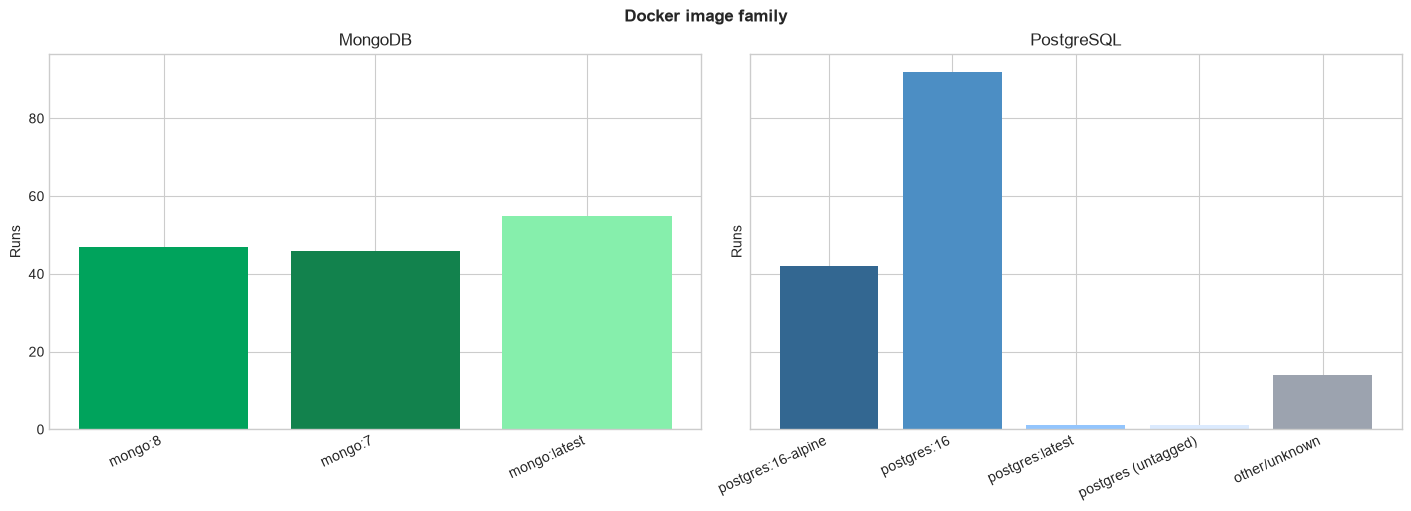

Mongo image family by agent/model:


image_family,mongo:8,mongo:7,mongo:latest
extension,,,
claude-sonnet,0,8,22
cursor-sonnet,0,7,21
cursor-grok,0,30,0
cursor-terra,18,0,12
codex-terra,29,1,0


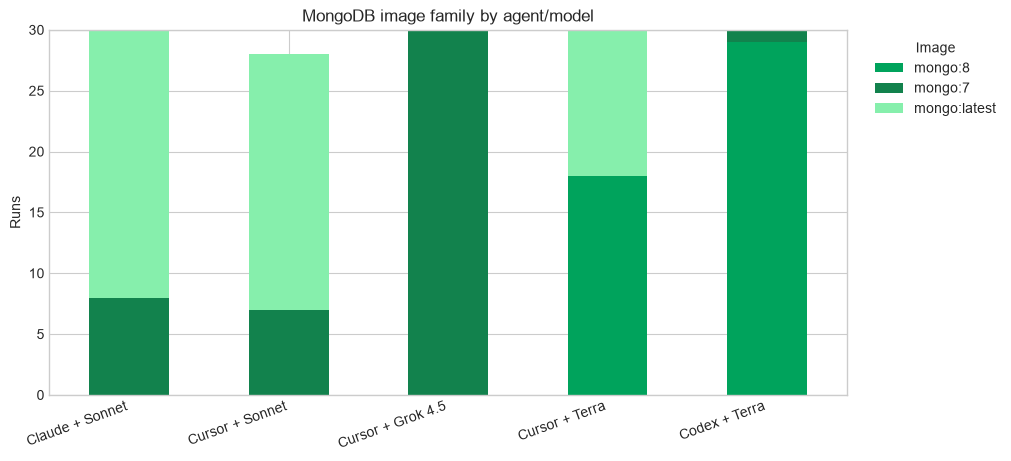

Mongo both-tests pass rate by image family:


,image_family,n,passes,rate
0,mongo:8,47,44,0.936
1,mongo:7,46,39,0.848
2,mongo:latest,55,52,0.945


In [16]:
if not READY:
    print("Waiting for measurements.")
else:
    IMAGE_FAMILY_ORDER = [
        "mongo:8",
        "mongo:7",
        "mongo:latest",
        "mongo (untagged)",
        "community-server",
        "postgres:16-alpine",
        "postgres:16",
        "postgres:latest",
        "postgres (untagged)",
        "other/unknown",
    ]
    IMAGE_COLORS = {
        "mongo:8": "#00A35C",
        "mongo:7": "#12824D",
        "mongo:latest": "#86EFAC",
        "mongo (untagged)": "#D1FAE5",
        "community-server": "#1D4ED8",
        "postgres:16-alpine": "#336791",
        "postgres:16": "#4C8EC4",
        "postgres:latest": "#93C5FD",
        "postgres (untagged)": "#DBEAFE",
        "other/unknown": "#9CA3AF",
    }

    image_sql = f"""
    SELECT
        run_id,
        countIf(positionCaseInsensitive(payload, 'mongodb/mongodb-community-server') > 0) AS community_server_hits,
        countIf(positionCaseInsensitive(payload, 'mongo:latest') > 0) AS mongo_latest_hits,
        countIf(match(payload, '(?i)mongo:8')) AS mongo8_hits,
        countIf(match(payload, '(?i)mongo:7')) AS mongo7_hits,
        countIf(
            positionCaseInsensitive(payload, 'docker run') > 0
            AND match(payload, '(?i)[[:space:]]mongo([[:space:]]|$)')
        ) AS mongo_untagged_hits,
        countIf(positionCaseInsensitive(payload, 'postgres:16-alpine') > 0) AS pg16_alpine_hits,
        countIf(positionCaseInsensitive(payload, 'postgres:16') > 0) AS pg16_hits,
        countIf(positionCaseInsensitive(payload, 'postgres:latest') > 0) AS pg_latest_hits,
        countIf(
            positionCaseInsensitive(payload, 'docker run') > 0
            AND match(payload, '(?i)[[:space:]]postgres([[:space:]]|$)')
        ) AS pg_untagged_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
      AND prompt_id IN ('mongodb', 'postgresql')
    GROUP BY run_id
    """
    image_flags = ax_query(image_sql)
    image_runs = runs[runs["database"].isin(["mongodb", "postgresql"])].merge(
        image_flags, on="run_id", how="left"
    )

    def classify_image(row) -> str:
        database = str(row.get("database") or "")
        if database == "mongodb":
            if int(row.get("community_server_hits") or 0) > 0:
                return "community-server"
            if int(row.get("mongo8_hits") or 0) > 0:
                return "mongo:8"
            if int(row.get("mongo7_hits") or 0) > 0:
                return "mongo:7"
            if int(row.get("mongo_latest_hits") or 0) > 0:
                return "mongo:latest"
            if int(row.get("mongo_untagged_hits") or 0) > 0:
                return "mongo (untagged)"
            return "other/unknown"
        if int(row.get("pg16_alpine_hits") or 0) > 0:
            return "postgres:16-alpine"
        if int(row.get("pg16_hits") or 0) > 0:
            return "postgres:16"
        if int(row.get("pg_latest_hits") or 0) > 0:
            return "postgres:latest"
        if int(row.get("pg_untagged_hits") or 0) > 0:
            return "postgres (untagged)"
        return "other/unknown"

    image_runs["image_family"] = image_runs.apply(classify_image, axis=1)
    image_runs["image_family"] = pd.Categorical(
        image_runs["image_family"], categories=IMAGE_FAMILY_ORDER, ordered=True
    )
    mixed_pin_and_latest = int(
        (
            (image_runs["database"] == "mongodb")
            & image_runs["mongo_latest_hits"].fillna(0).gt(0)
            & (
                image_runs["mongo7_hits"].fillna(0).gt(0)
                | image_runs["mongo8_hits"].fillna(0).gt(0)
            )
        ).sum()
    )

    print("Image family by database (one label per run):")
    image_counts = (
        image_runs.groupby(["database", "image_family"], observed=True)
        .size()
        .rename("n")
        .reset_index()
    )
    display(image_counts)
    print(
        f"Mongo runs that mention both a pinned major and mongo:latest: "
        f"{mixed_pin_and_latest} (labeled as the pin)."
    )
    n_community = int((image_runs["image_family"] == "community-server").sum())
    print(
        f"mongodb/mongodb-community-server: {n_community}/"
        f"{int((image_runs['database'] == 'mongodb').sum())} Mongo runs."
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, ["mongodb", "postgresql"]):
        subset = image_runs[image_runs["database"] == database]
        counts = (
            subset["image_family"]
            .value_counts()
            .reindex(
                [name for name in IMAGE_FAMILY_ORDER if name in set(subset["image_family"])],
                fill_value=0,
            )
        )
        ax.bar(
            [str(name) for name in counts.index],
            counts.values,
            color=[IMAGE_COLORS.get(name, "#9CA3AF") for name in counts.index],
        )
        ax.set_title(label_of(database))
        ax.set_ylabel("Runs")
        ax.tick_params(axis="x", rotation=25)
        for tick in ax.get_xticklabels():
            tick.set_ha("right")
    fig.suptitle("Docker image family", fontweight="bold")
    plt.show()

    print("Mongo image family by agent/model:")
    mongo_images = image_runs[image_runs["database"] == "mongodb"]
    mongo_image_xtab = (
        pd.crosstab(mongo_images["extension"], mongo_images["image_family"])
        .reindex(EXTENSION_ORDER)
        .reindex(
            columns=[name for name in IMAGE_FAMILY_ORDER if name in set(mongo_images["image_family"])],
            fill_value=0,
        )
    )
    display(mongo_image_xtab)

    fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
    mongo_image_xtab.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[IMAGE_COLORS.get(column, "#9CA3AF") for column in mongo_image_xtab.columns],
    )
    ax.set_title("MongoDB image family by agent/model")
    ax.set_xlabel("")
    ax.set_ylabel("Runs")
    ax.set_xticklabels([label_of(name) for name in mongo_image_xtab.index], rotation=20, ha="right")
    ax.legend(title="Image", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    print("Mongo both-tests pass rate by image family:")
    mongo_image_pass = (
        mongo_images.groupby("image_family", observed=True)
        .agg(n=("run_id", "size"), passes=("both_tests_passed", "sum"))
        .reset_index()
    )
    mongo_image_pass["rate"] = mongo_image_pass["passes"] / mongo_image_pass["n"]
    display(mongo_image_pass.round(3))


## MongoDB image choice: `mongo` vs MongoDB-maintained images

Context for the 0/148 community-server result above. **`mongo` is not a
wrong image** — it ran, agents pinged it, official tests passed. The finding
is *steering*: MongoDB's documented image has no gravity in agent defaults.

- **`mongo`** is the Docker Official Image, maintained by *Docker Inc.* since
  ~2014 — not by MongoDB. MongoDB staff have described it in the community
  forums as "a bit of a misnomer since it's not really officially supported by
  MongoDB."
- **`mongodb/mongodb-community-server`** is the MongoDB-maintained image,
  launched mid-2022 (the 6.0 era, with ARM64 support). The MongoDB manual's
  "Install MongoDB Community with Docker" page (v6.0+) exclusively uses this
  image, and the community Kubernetes operator made it the default in early
  2023 (CLOUDP-169740). It has been the documented preferred path for 3+
  years.
- **`mongodb/mongodb-atlas-local`** grew out of Atlas CLI local deployments
  (preview ~2023, image workflow promoted through 2024). It bundles `mongot`,
  so Search / Vector Search work locally out of the box.

## MongoDB image choice: `mongo` vs MongoDB-maintained images

Context for the 0/148 community-server result above. **`mongo` is not a
wrong image** — it ran, agents pinged it, official tests passed. The finding
is *steering*: MongoDB's documented image has no gravity in agent defaults.

- **`mongo`** is the Docker Official Image, maintained by *Docker Inc.* since
  ~2014 — not by MongoDB. MongoDB staff have described it in the community
  forums as "a bit of a misnomer since it's not really officially supported by
  MongoDB."
- **`mongodb/mongodb-community-server`** is the MongoDB-maintained image,
  launched mid-2022 (the 6.0 era, with ARM64 support). The MongoDB manual's
  "Install MongoDB Community with Docker" page (v6.0+) exclusively uses this
  image, and the community Kubernetes operator made it the default in early
  2023 (CLOUDP-169740). It has been the documented preferred path for 3+
  years.
- **`mongodb/mongodb-atlas-local`** grew out of Atlas CLI local deployments
  (preview ~2023, image workflow promoted through 2024). It bundles `mongot`,
  so Search / Vector Search work locally out of the box.

Three questions the transcripts can answer:

1. Did any agent *consider* a MongoDB-maintained image (mention it in
   reasoning, try to pull it, hit an error, fall back to `mongo`)?
2. Or is the legacy image a pure reflex — zero mentions anywhere?
3. Did they *look at a registry or docs* before `docker run` (`docker search`,
   Hub page, MongoDB docs, `docker manifest`), or just name `mongo` from
   memory?

The scan below searches **all captured events** (reasoning, tool calls,
stdout, transcript), not just tool-call evidence, so a considered-but-rejected
image would still show up.

Reading (from the run below): **zero mentions in any of the 148 Mongo runs**
— no agent considered `mongodb/mongodb-community-server`,
`mongodb/mongodb-atlas-local`, Bitnami, or the enterprise image, and therefore
none hit an error with them. The choice of `mongo` is memorized reflex, not a
comparison that the official image lost. Training-data gravity (a decade of
tutorials and compose files using `image: mongo`) currently outweighs three
years of docs recommending the MongoDB-maintained image. Implication: steering
agents toward a preferred image will not happen organically; it needs
retrieved docs, agent skills, or prompt-level guidance.

The next cell asks question 3 directly: registry browse vs implicit Hub pull.

In [17]:
if not READY:
    print("Waiting for measurements.")
else:
    ALTERNATIVE_IMAGE_PATTERNS = {
        "mongodb/mongodb-community-server": "mongodb-community-server",
        "mongodb/mongodb-atlas-local": "mongodb-atlas-local",
        "mongodb/mongodb-enterprise-server": "mongodb-enterprise-server",
        "bitnami/mongodb": "bitnami/mongo",
    }
    mention_exprs = ",\n        ".join(
        f"uniqExactIf(run_id, positionCaseInsensitive(payload, '{needle}') > 0) AS `{label}`"
        for label, needle in ALTERNATIVE_IMAGE_PATTERNS.items()
    )
    alternative_sql = f"""
    SELECT
        {mention_exprs},
        uniqExact(run_id) AS mongo_runs_with_events
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND prompt_id = 'mongodb'
    """
    alternative = ax_query(alternative_sql)
    row = alternative.iloc[0]

    print("Runs mentioning each alternative image anywhere in captured events")
    print(f"(reasoning, tool calls, stdout, transcript; {int(row['mongo_runs_with_events'])} Mongo runs scanned):\n")
    any_considered = False
    for label in ALTERNATIVE_IMAGE_PATTERNS:
        n = int(row[label])
        any_considered = any_considered or n > 0
        print(f"  {label}: {n}")

    if any_considered:
        print("\nAt least one agent considered an alternative image; drill into those runs")
        print("for error-and-fallback sequences before drawing conclusions.")
    else:
        print(
            "\nNo agent considered any MongoDB-maintained or third-party image, so no"
            "\nrun tried one and failed. The legacy `mongo` image is a pure default,"
            "\nnot the survivor of a comparison."
        )

Runs mentioning each alternative image anywhere in captured events
(reasoning, tool calls, stdout, transcript; 148 Mongo runs scanned):

  mongodb/mongodb-community-server: 0
  mongodb/mongodb-atlas-local: 0
  mongodb/mongodb-enterprise-server: 0
  bitnami/mongodb: 0

No agent considered any MongoDB-maintained or third-party image, so no
run tried one and failed. The legacy `mongo` image is a pure default,
not the survivor of a comparison.


## Registry lookup before `docker run`

`docker run mongo` talks to Docker Hub as the **default registry** when the
image is missing locally. That is install, not a catalog search. A real lookup
would be `docker search`, a Hub/docs page fetch, `docker manifest inspect`,
or a web search for which image to use.

Signals (Mongo tool calls unless noted):

- **Browse:** `docker search`, `hub.docker.com`, `cr.mongodb.com`, `quay.io`,
  `ghcr.io`, `docker manifest`, `skopeo`, `docs.mongodb.com`
- **Named fetch:** explicit `docker pull <image>` (already chose the name)
- **Local cache:** `docker images` *before* the first `docker run`
- **Daemon stdout:** `Pulling from library/mongo` / `docker.io/library/mongo`
  — Hub contact as a side effect of pull/run, not a page the agent read

Claude all-events can mention `WebSearch` because the tool schema is in
context. Count **tool_call** rows, not schema text.

Postgres is the control: same question for `postgres`.

Remote registry / docs browse vs install (tool_call evidence):


,database,n_runs,registry_or_docs_browse,explicit_docker_pull,explicit_docker_run,daemon_pulling_from_library
0,mongodb,148,0,6,148,144
1,postgresql,150,0,5,149,147



Mongo browse needles (should be 0 if the image is a memorized default):


,mongo_runs
docker_search,0
hub_docker_com,0
cr_mongodb,0
quay_io,0
ghcr_io,0
docker_manifest,0
skopeo,0
docs_mongodb,0
mongodb_docs,0
postgresql_org,0


Mongo local `docker images` / explicit `docker pull` before first `docker run`:


,extension,n,images_before_run,pull_before_run
0,claude-sonnet,30,4,2
1,codex-terra,30,10,0
2,cursor-sonnet,28,0,2
3,cursor-terra,30,1,0
4,cursor-grok,30,10,0


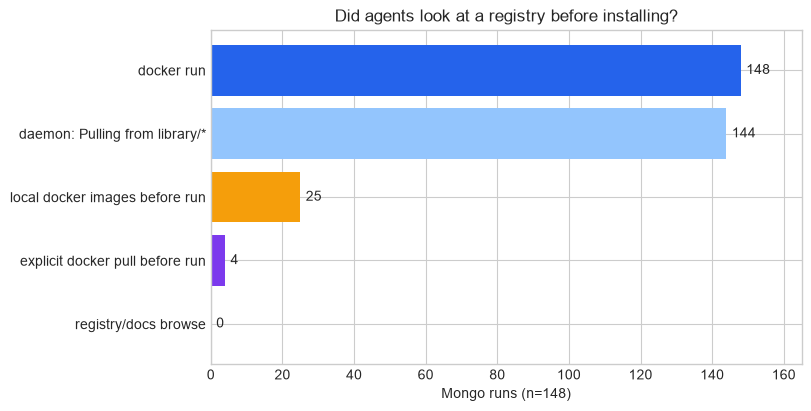

Reading: 0/148 Mongo runs browsed Hub, MongoDB docs, or `docker search`. 148/148 went straight to `docker run`; Hub shows up as daemon pull stdout (`library/mongo`), not as a page they read. 25/148 listed local images first (machine cache, not a registry catalog). 4/148 ran `docker pull` before `docker run` — still a named fetch of `mongo`, not a comparison. Postgres is the same shape. Grok/Claude sometimes say 'the official image' in reasoning; that phrase means they already believe `mongo` is official, not that they looked it up.


In [18]:
if not READY:
    print("Waiting for measurements.")
else:
    REGISTRY_BROWSE_NEEDLES = {
        "docker_search": "docker search",
        "hub_docker_com": "hub.docker.com",
        "cr_mongodb": "cr.mongodb.com",
        "quay_io": "quay.io",
        "ghcr_io": "ghcr.io",
        "docker_manifest": "docker manifest",
        "skopeo": "skopeo",
        "docs_mongodb": "docs.mongodb.com",
        "mongodb_docs": "mongodb.com/docs",
        "postgresql_org": "postgresql.org",
    }

    def registry_counts(database: str) -> pd.Series:
        browse_exprs = ",\n            ".join(
            f"uniqExactIf(run_id, positionCaseInsensitive(payload, '{needle}') > 0) "
            f"AS {name}"
            for name, needle in REGISTRY_BROWSE_NEEDLES.items()
        )
        sql = f"""
        SELECT
            uniqExact(run_id) AS n_runs,
            {browse_exprs},
            uniqExactIf(run_id, positionCaseInsensitive(payload, 'WebSearch') > 0
                OR positionCaseInsensitive(payload, 'web_search') > 0) AS websearch_tool,
            uniqExactIf(run_id, positionCaseInsensitive(payload, 'WebFetch') > 0
                OR positionCaseInsensitive(payload, 'web_fetch') > 0) AS webfetch_tool,
            uniqExactIf(run_id, match(payload, '(?i)docker[[:space:]]+pull[[:space:]]+') > 0)
                AS explicit_docker_pull,
            uniqExactIf(run_id, match(payload, '(?i)docker[[:space:]]+run[[:space:]]+') > 0)
                AS explicit_docker_run,
            uniqExactIf(run_id, positionCaseInsensitive(payload, 'Pulling from library/') > 0)
                AS daemon_pulling_from_library,
            uniqExactIf(run_id, positionCaseInsensitive(payload, 'docker.io/library/') > 0)
                AS docker_io_library_stdout
        FROM events
        WHERE run_request_id = '{RUN_REQUEST_ID}'
          AND prompt_id = '{database}'
          AND kind = 'tool_call'
        """
        return ax_query(sql).iloc[0]

    def local_images_before_run(database: str) -> pd.DataFrame:
        sql = f"""
        WITH firsts AS (
          SELECT
            run_id,
            agent,
            model,
            minIf(source_seq, match(payload, '(?i)docker[[:space:]]+run[[:space:]]+') > 0)
                AS first_run,
            minIf(source_seq, match(payload, '(?i)docker[[:space:]]+pull[[:space:]]+') > 0)
                AS first_pull,
            minIf(source_seq, match(payload, '(?i)docker[[:space:]]+images') > 0)
                AS first_images
          FROM events
          WHERE run_request_id = '{RUN_REQUEST_ID}'
            AND prompt_id = '{database}'
            AND kind = 'tool_call'
          GROUP BY run_id, agent, model
        )
        SELECT
          agent,
          model,
          uniqExact(run_id) AS n,
          countIf(first_images > 0 AND (first_run = 0 OR first_images < first_run))
              AS images_before_run,
          countIf(first_pull > 0 AND (first_run = 0 OR first_pull < first_run))
              AS pull_before_run
        FROM firsts
        GROUP BY agent, model
        ORDER BY agent, model
        """
        return assign_extension(ax_query(sql))

    mongo_reg = registry_counts("mongodb")
    pg_reg = registry_counts("postgresql")
    browse_cols = list(REGISTRY_BROWSE_NEEDLES) + ["websearch_tool", "webfetch_tool"]

    summary_rows = []
    for database, row in (("mongodb", mongo_reg), ("postgresql", pg_reg)):
        browse_hits = int(sum(int(row[col]) for col in browse_cols))
        summary_rows.append(
            {
                "database": database,
                "n_runs": int(row["n_runs"]),
                "registry_or_docs_browse": browse_hits,
                "explicit_docker_pull": int(row["explicit_docker_pull"]),
                "explicit_docker_run": int(row["explicit_docker_run"]),
                "daemon_pulling_from_library": int(row["daemon_pulling_from_library"]),
            }
        )
    registry_summary = pd.DataFrame(summary_rows)
    print("Remote registry / docs browse vs install (tool_call evidence):")
    display(registry_summary)

    print("\nMongo browse needles (should be 0 if the image is a memorized default):")
    mongo_browse = pd.Series({col: int(mongo_reg[col]) for col in browse_cols}, name="mongo_runs")
    display(mongo_browse.to_frame())

    mongo_local = local_images_before_run("mongodb")
    print("Mongo local `docker images` / explicit `docker pull` before first `docker run`:")
    display(mongo_local[["extension", "n", "images_before_run", "pull_before_run"]])

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    labels = [
        "docker run",
        "daemon: Pulling from library/*",
        "local docker images before run",
        "explicit docker pull before run",
        "registry/docs browse",
    ]
    values = [
        int(mongo_reg["explicit_docker_run"]),
        int(mongo_reg["daemon_pulling_from_library"]),
        int(mongo_local["images_before_run"].sum()),
        int(mongo_local["pull_before_run"].sum()),
        int(sum(int(mongo_reg[col]) for col in browse_cols)),
    ]
    colors = ["#2563EB", "#93C5FD", "#F59E0B", "#7C3AED", "#DC2626"]
    ax.barh(labels[::-1], values[::-1], color=colors[::-1])
    ax.set_xlabel("Mongo runs (n=148)")
    ax.set_title("Did agents look at a registry before installing?")
    for y, value in enumerate(values[::-1]):
        ax.text(value + 1.5, y, str(value), va="center")
    ax.set_xlim(0, 165)
    plt.show()

    print(
        "Reading: 0/148 Mongo runs browsed Hub, MongoDB docs, or `docker search`. "
        f"{int(mongo_reg['explicit_docker_run'])}/148 went straight to `docker run`; "
        "Hub shows up as daemon pull stdout (`library/mongo`), not as a page they read. "
        f"{int(mongo_local['images_before_run'].sum())}/148 listed local images first "
        "(machine cache, not a registry catalog). "
        f"{int(mongo_local['pull_before_run'].sum())}/148 ran `docker pull` before "
        "`docker run` — still a named fetch of `mongo`, not a comparison. "
        "Postgres is the same shape. "
        "Grok/Claude sometimes say 'the official image' in reasoning; that phrase "
        "means they already believe `mongo` is official, not that they looked it up."
    )


## Decision path: tools before the image

The registry cell shows they never browsed Hub. This cell asks what they
*did* do before the first `docker run` / `docker pull`.

Typical loop, from tool calls only (commands classified, never printed —
they can contain generated passwords):

1. **Probe the machine** — `which` / `command -v` for `mongod`, `docker`,
   sometimes `podman`; often `docker ps` / `docker version` / `docker images`.
2. **Sometimes look in the workspace** — compose files, README, `.env`
   (reuse an existing project). Cursor + Terra also globs Cursor terminal
   logs, which is harness habit, not image research.
3. **Then `docker run mongo:<tag>`** — the tag is already in that command.
   No second candidate image. No apt install of MongoDB.

Image choice is therefore not a tool-using decision. It is a memorized
default written into the first fetch: Grok **30/30 `mongo:7`**, Codex Terra
**29/30 `mongo:8`**, Sonnet cells mostly `mongo:latest`. Reasoning that
says "the official image" (Grok) never names the tag, and never names
`mongodb/mongodb-community-server`.

Postgres is the same shape: probe, then `docker run postgres`.

Mongo runs with a docker run/pull: 148/148
Probed before the image: 148/148 (mean 2.04 unique tool calls, max 5).
Pre-image unique tool-call count by agent/model:


,n,mean,min,max
extension,,,,
claude-sonnet,30,1.93,1,3
cursor-sonnet,28,2.04,1,3
cursor-grok,30,1.40,1,2
cursor-terra,30,3.03,2,5
codex-terra,30,1.80,1,3


First tool call of the run (before or at the image fetch):


family,docker version/info,glob,read,which/command -v,workspace compose/files,workspace/os probe
extension,,,,,,
claude-sonnet,0,0,0,30,0,0
cursor-sonnet,0,0,0,28,0,0
cursor-grok,0,0,0,30,0,0
cursor-terra,2,18,1,1,0,8
codex-terra,13,0,0,16,1,0


Pre-image tool families (runs that used each family at least once):


family,docker images,docker ps,docker version/info,glob,read,which/command -v,workspace compose/files,workspace/os probe
extension,,,,,,,,
claude-sonnet,4,12,11,0,0,30,0,0
cursor-sonnet,0,12,13,0,0,28,0,0
cursor-grok,10,2,0,0,0,30,0,0
cursor-terra,1,13,27,24,1,2,0,15
codex-terra,7,9,20,0,0,17,1,0


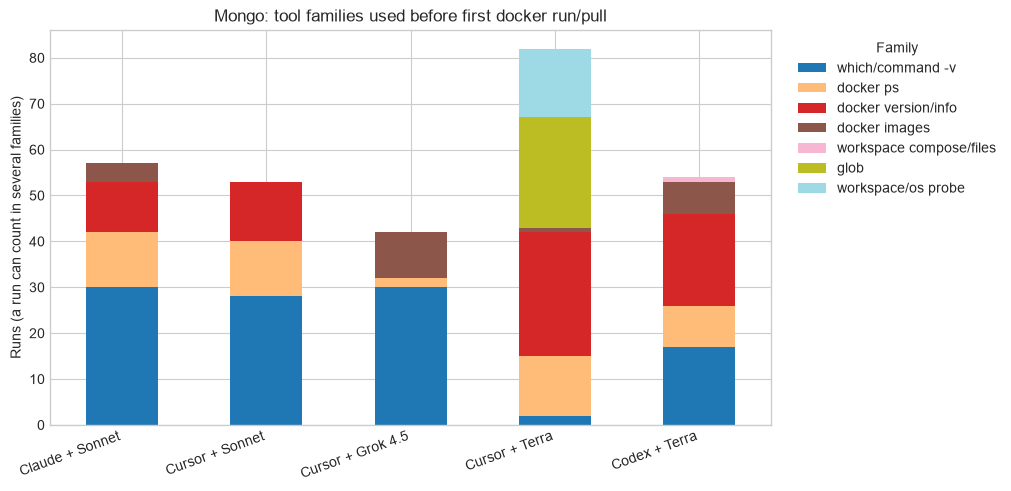

First docker run/pull image tag (mutually exclusive; latest wins ties):


image_tag,mongo:7,mongo:8,mongo:latest
extension,,,
claude-sonnet,4,0,26
cursor-sonnet,7,0,21
cursor-grok,30,0,0
cursor-terra,0,18,12
codex-terra,1,29,0


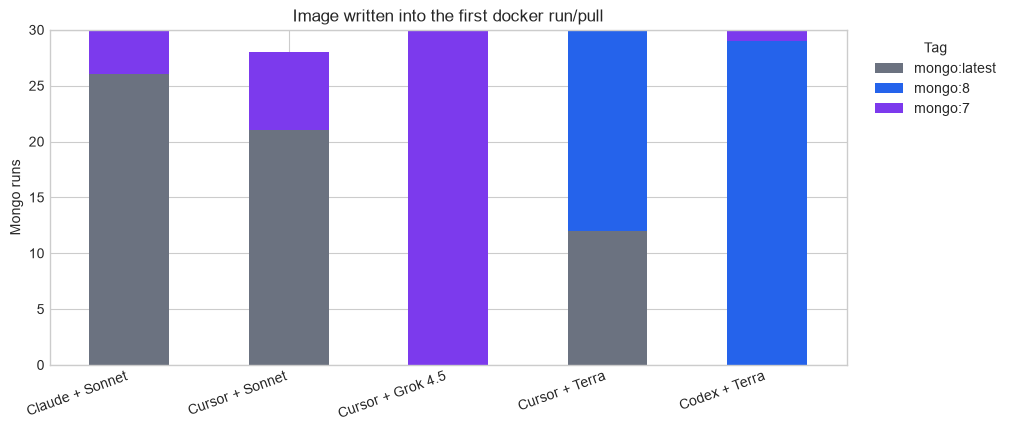

Decision probes before first docker run/pull:


,n,checks_docker,checks_mongod,looks_for_compose,apt_search
extension,,,,,
claude-sonnet,30,30,30,4,1
cursor-sonnet,28,28,28,5,4
cursor-grok,30,30,30,0,0
cursor-terra,30,30,0,3,0
codex-terra,30,30,15,18,0


Pooled: apt install of MongoDB before the image = 0 calls. apt-cache/search runs = 5/148. Workspace compose/file search runs = 30/148.


Reasoning/messages before first docker run/pull (Claude often has empty displayed_text):


,n,says_docker,says_official_image,says_mongo7,says_mongo8,says_latest,says_community
extension,,,,,,,
claude-sonnet,30,0,0,0,0,0,0
cursor-sonnet,28,11,0,0,0,0,0
cursor-grok,30,30,9,0,0,0,0
cursor-terra,30,30,0,0,0,0,0
codex-terra,30,29,0,1,5,0,0


Reading: every Mongo run probes the machine, then fetches a named Hub image. They check that Docker exists (and usually that mongod does not). They do not compare images. The tag in the first docker run/pull is the whole decision — Grok always :7, Codex Terra almost always :8, Sonnet mostly :latest — and reasoning almost never names that tag. A handful of Codex/Claude/Cursor-Sonnet runs look for compose in the workspace first; none apt-install MongoDB. Cursor + Terra starts with glob/ls (often Cursor terminal files), already on a Docker path.


In [19]:
if not READY:
    print("Waiting for measurements.")
else:
    FAMILY_CASE = """
      multiIf(
        tool_name IN ('glob', 'Glob'), 'glob',
        tool_name IN ('read', 'Read'), 'read',
        tool_name IN ('await', 'Await'), 'await',
        match(command, '(?i)which |command -v |type '), 'which/command -v',
        match(command, '(?i)docker[[:space:]]+(version|info)|docker --version'), 'docker version/info',
        match(command, '(?i)docker[[:space:]]+images'), 'docker images',
        match(command, '(?i)docker[[:space:]]+ps'), 'docker ps',
        match(command, '(?i)docker[[:space:]]+(run|pull)[[:space:]]'), 'docker run/pull',
        match(command, '(?i)docker[[:space:]]'), 'docker other',
        match(command, '(?i)apt-cache|apt search'), 'apt search',
        match(command, '(?i)apt-get install|apt install'), 'apt install',
        match(command, '(?i)compose\\\\.ya?ml|docker-compose|rg --files'), 'workspace compose/files',
        match(command, '(?i)(^|[;&|\\\\n])[[:space:]]*(ls |pwd|find |head |cat |uname |id |ss )'), 'workspace/os probe',
        'other'
      )
    """
    TAG_CASE = """
      multiIf(
        match(command, '(?i)mongodb/mongodb-community-server'), 'community-server',
        match(command, '(?i)mongo:latest'), 'mongo:latest',
        match(command, '(?i)mongo:8'), 'mongo:8',
        match(command, '(?i)mongo:7'), 'mongo:7',
        match(command, '(?i)mongo:6'), 'mongo:6',
        match(command, '(?i)[[:space:]]mongo[[:space:]]'), 'mongo',
        'other'
      )
    """
    calls_sql = f"""
    WITH calls AS (
      SELECT
        run_id,
        agent,
        model,
        tool_call_id,
        min(source_seq) AS seq,
        argMax(JSONExtractString(payload, 'tool_name'),
               length(JSONExtractString(payload, 'tool_name'))) AS tool_name,
        argMax(JSONExtractString(payload, 'input', 'command'),
               length(JSONExtractString(payload, 'input', 'command'))) AS command,
        argMax(JSONExtractString(payload, 'input', 'globPattern'),
               length(JSONExtractString(payload, 'input', 'globPattern'))) AS glob_pattern
      FROM events
      WHERE run_request_id = '{RUN_REQUEST_ID}'
        AND prompt_id = 'mongodb'
        AND kind = 'tool_call'
        AND coalesce(assertion_role, 'primary') = 'primary'
      GROUP BY run_id, agent, model, tool_call_id
    )
    SELECT
      run_id,
      agent,
      model,
      seq,
      tool_name,
      {FAMILY_CASE} AS family,
      {TAG_CASE} AS image_tag,
      min(seq) OVER (PARTITION BY run_id) AS first_seq,
      minIf(seq, match(command, '(?i)docker[[:space:]]+(run|pull)[[:space:]]'))
        OVER (PARTITION BY run_id) AS first_image_seq,
      match(command, '(?i)compose\\\\.ya?ml|docker-compose|rg --files')
        OR match(glob_pattern, '(?i)compose') AS looks_compose,
      match(command, '(?i)apt-cache|apt search') AS apt_search,
      match(command, '(?i)which |command -v') AND positionCaseInsensitive(command, 'mongod') > 0 AS checks_mongod,
      (
        match(command, '(?i)which |command -v|docker version|docker --version|docker info|docker ps|docker images')
        AND positionCaseInsensitive(command, 'docker') > 0
      ) AS checks_docker
    FROM calls
    """
    calls = assign_extension(ax_query(calls_sql, limit=10_000))
    image_runs = (
        calls[calls["seq"] == calls["first_image_seq"]]
        .drop_duplicates("run_id")
        .copy()
    )
    pre = calls[(calls["first_image_seq"] > 0) & (calls["seq"] < calls["first_image_seq"])].copy()
    first_calls = calls[calls["seq"] == calls["first_seq"]].drop_duplicates("run_id").copy()

    pre_n = (
        pre.groupby(["extension", "run_id"], observed=True)
        .size()
        .reset_index(name="pre_n")
    )
    # Runs with no pre row still fetched an image as a later call; fill 0.
    pre_n = image_runs[["extension", "run_id"]].merge(pre_n, on=["extension", "run_id"], how="left")
    pre_n["pre_n"] = pre_n["pre_n"].fillna(0).astype(int)

    print(f"Mongo runs with a docker run/pull: {len(image_runs)}/148")
    print(
        f"Probed before the image: {(pre_n['pre_n'] > 0).sum()}/{len(pre_n)} "
        f"(mean {pre_n['pre_n'].mean():.2f} unique tool calls, "
        f"max {int(pre_n['pre_n'].max())})."
    )
    print("Pre-image unique tool-call count by agent/model:")
    display(
        pre_n.groupby("extension", observed=True)["pre_n"]
        .agg(n="size", mean="mean", min="min", max="max")
        .reindex(EXTENSION_ORDER)
        .round(2)
    )

    print("First tool call of the run (before or at the image fetch):")
    first_xtab = (
        pd.crosstab(first_calls["extension"], first_calls["family"])
        .reindex(EXTENSION_ORDER)
        .fillna(0)
        .astype(int)
    )
    display(first_xtab)

    print("Pre-image tool families (runs that used each family at least once):")
    pre_run_family = (
        pre.groupby(["extension", "family"], observed=True)["run_id"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(EXTENSION_ORDER)
    )
    display(pre_run_family)

    fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
    plot_cols = [c for c in [
        "which/command -v", "docker ps", "docker version/info", "docker images",
        "workspace compose/files", "glob", "workspace/os probe", "apt search",
        "docker other", "other",
    ] if c in pre_run_family.columns]
    pre_run_family.reindex(columns=plot_cols, fill_value=0).plot(
        kind="bar", stacked=True, ax=ax, colormap="tab20"
    )
    ax.set_title("Mongo: tool families used before first docker run/pull")
    ax.set_xlabel("")
    ax.set_ylabel("Runs (a run can count in several families)")
    ax.set_xticklabels([label_of(name) for name in pre_run_family.index], rotation=20, ha="right")
    ax.legend(title="Family", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    print("First docker run/pull image tag (mutually exclusive; latest wins ties):")
    tag_xtab = (
        pd.crosstab(image_runs["extension"], image_runs["image_tag"])
        .reindex(EXTENSION_ORDER)
        .fillna(0)
        .astype(int)
    )
    display(tag_xtab)

    fig, ax = plt.subplots(figsize=(10, 4.2), constrained_layout=True)
    tag_order = [c for c in ["mongo:latest", "mongo:8", "mongo:7", "mongo:6", "mongo", "community-server", "other"] if c in tag_xtab.columns]
    tag_xtab.reindex(columns=tag_order, fill_value=0).plot(
        kind="bar", stacked=True, ax=ax,
        color=["#6B7280", "#2563EB", "#7C3AED", "#F59E0B", "#9CA3AF", "#00A35C", "#DC2626"][:len(tag_order)],
    )
    ax.set_title("Image written into the first docker run/pull")
    ax.set_xlabel("")
    ax.set_ylabel("Mongo runs")
    ax.set_xticklabels([label_of(name) for name in tag_xtab.index], rotation=20, ha="right")
    ax.legend(title="Tag", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    print("Decision probes before first docker run/pull:")
    pre_flags = pre.groupby("run_id", observed=True).agg(
        checks_docker=("checks_docker", "max"),
        checks_mongod=("checks_mongod", "max"),
        looks_for_compose=("looks_compose", "max"),
        apt_search=("apt_search", "max"),
    )
    pre_flags = image_runs[["extension", "run_id"]].merge(pre_flags, on="run_id", how="left").fillna(0)
    flag_tbl = (
        pre_flags.groupby("extension", observed=True)
        .agg(
            n=("run_id", "size"),
            checks_docker=("checks_docker", "sum"),
            checks_mongod=("checks_mongod", "sum"),
            looks_for_compose=("looks_for_compose", "sum"),
            apt_search=("apt_search", "sum"),
        )
        .reindex(EXTENSION_ORDER)
        .astype(int)
    )
    display(flag_tbl)
    print(
        f"Pooled: apt install of MongoDB before the image = "
        f"{int((pre['family'] == 'apt install').sum())} calls. "
        f"apt-cache/search runs = {int(flag_tbl['apt_search'].sum())}/148. "
        f"Workspace compose/file search runs = {int(flag_tbl['looks_for_compose'].sum())}/148."
    )

    reason_sql = f"""
    WITH image_seq AS (
      SELECT
        run_id,
        minIf(source_seq, kind = 'tool_call'
          AND match(JSONExtractString(payload, 'input', 'command'),
                    '(?i)docker[[:space:]]+(run|pull)[[:space:]]')) AS first_image_seq
      FROM events
      WHERE run_request_id = '{RUN_REQUEST_ID}'
        AND prompt_id = 'mongodb'
        AND coalesce(assertion_role, 'primary') = 'primary'
      GROUP BY run_id
    )
    SELECT
      e.agent,
      e.model,
      uniqExact(e.run_id) AS n,
      uniqExactIf(e.run_id, positionCaseInsensitive(coalesce(
        JSONExtractString(e.payload, 'displayed_text'),
        JSONExtractString(e.payload, 'text')), 'docker') > 0) AS says_docker,
      uniqExactIf(e.run_id, positionCaseInsensitive(coalesce(
        JSONExtractString(e.payload, 'displayed_text'),
        JSONExtractString(e.payload, 'text')), 'official image') > 0) AS says_official_image,
      uniqExactIf(e.run_id, positionCaseInsensitive(coalesce(
        JSONExtractString(e.payload, 'displayed_text'),
        JSONExtractString(e.payload, 'text')), 'mongo:7') > 0) AS says_mongo7,
      uniqExactIf(e.run_id, positionCaseInsensitive(coalesce(
        JSONExtractString(e.payload, 'displayed_text'),
        JSONExtractString(e.payload, 'text')), 'mongo:8') > 0) AS says_mongo8,
      uniqExactIf(e.run_id, positionCaseInsensitive(coalesce(
        JSONExtractString(e.payload, 'displayed_text'),
        JSONExtractString(e.payload, 'text')), 'mongo:latest') > 0) AS says_latest,
      uniqExactIf(e.run_id, positionCaseInsensitive(coalesce(
        JSONExtractString(e.payload, 'displayed_text'),
        JSONExtractString(e.payload, 'text')), 'community') > 0) AS says_community
    FROM events e
    INNER JOIN image_seq i ON e.run_id = i.run_id
    WHERE e.run_request_id = '{RUN_REQUEST_ID}'
      AND e.prompt_id = 'mongodb'
      AND e.kind IN ('reasoning', 'message')
      AND e.source_seq < i.first_image_seq
      AND i.first_image_seq > 0
    GROUP BY e.agent, e.model
    """
    reasons = assign_extension(ax_query(reason_sql)).set_index("extension").reindex(EXTENSION_ORDER)
    print("Reasoning/messages before first docker run/pull (Claude often has empty displayed_text):")
    display(reasons[["n", "says_docker", "says_official_image", "says_mongo7", "says_mongo8", "says_latest", "says_community"]])

    print(
        "Reading: every Mongo run probes the machine, then fetches a named Hub "
        "image. They check that Docker exists (and usually that mongod does not). "
        "They do not compare images. The tag in the first docker run/pull is the "
        "whole decision — Grok always :7, Codex Terra almost always :8, Sonnet "
        "mostly :latest — and reasoning almost never names that tag. "
        "A handful of Codex/Claude/Cursor-Sonnet runs look for compose in the "
        "workspace first; none apt-install MongoDB. Cursor + Terra starts with "
        "glob/ls (often Cursor terminal files), already on a Docker path."
    )


## Auth asymmetry (Mongo vs Postgres)

The official `mongo` image starts accepting connections with **no credentials**.
The official `postgres` image **refuses to boot** unless `POSTGRES_PASSWORD`
is set. That is a plausible root cause for "Mongo easiest, Postgres hardest":
agents do not fail to *install* Postgres (`docker run` is nearly universal);
they fail the connect/verify handshake.

This section tests two boolean predictions:

1. Few Mongo runs set `MONGO_INITDB_ROOT_USERNAME` + `MONGO_INITDB_ROOT_PASSWORD`
   (optional on the Mongo image).
2. Postgres `readiness-only` failures correlate with auth fumbles in the
   transcript (`password authentication failed`, `28P01`, `fe_sendauth`) rather
   than with a missing SQL probe.


Credential env vars (boolean, per finished run):


,database,n,sets_initdb_root_user+password,sets_--auth,sets_POSTGRES_PASSWORD,auth_error_in_transcript
0,mongodb,148,108,67,0,0
1,postgresql,150,0,0,149,0


Mongo INITDB root by agent/model:


,extension,n,initdb_root,auth_flag,passes,initdb_rate
0,claude-sonnet,30,30,12,30,1.000
1,cursor-sonnet,28,26,4,27,0.929
2,cursor-grok,30,23,23,23,0.767
3,cursor-terra,30,18,17,27,0.600
4,codex-terra,30,11,11,28,0.367


Mongo both-tests pass rate by whether INITDB root was set:


,sets_initdb_root,n,passes,rate
0,False,40,38,0.950
1,True,108,97,0.898


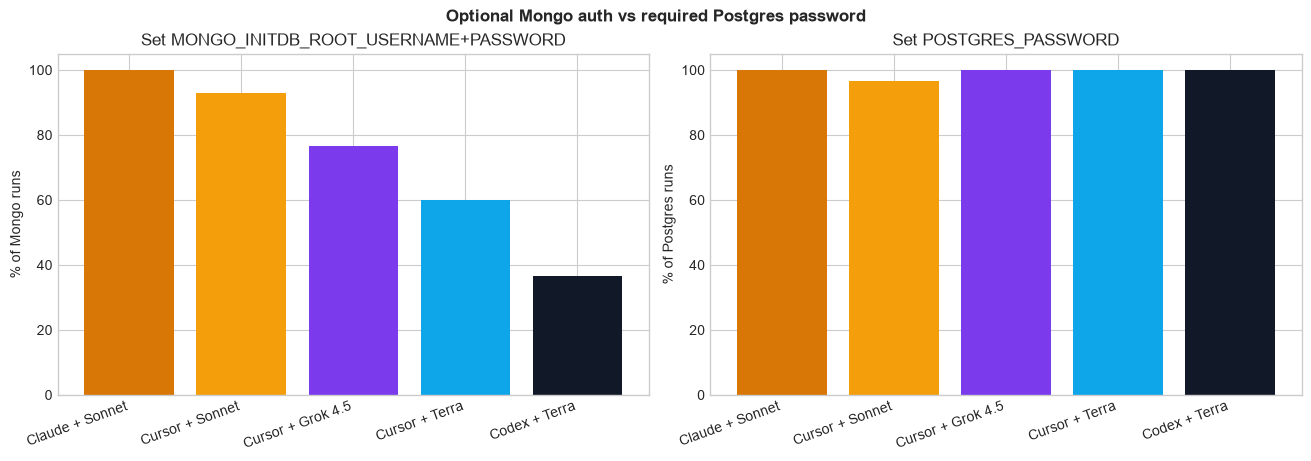

Postgres probe style vs connection-verified:


connection_passed,connection failed,connection passed,unscored
probe_style,,,
sql-probe (SELECT 1 or version()),1,102,5
psql without credited SQL,23,7,0
pg_isready only,10,1,1
no postgres client probe,0,0,0


Postgres connection failure mode vs probe style (and auth-error flag):


probe_style,sql-probe (SELECT 1 or version()),psql without credited SQL,pg_isready only,no postgres client probe
failure_mode,,,,
no-app-level-op,1,0,0,0
readiness-only,0,23,10,0


Auth-error strings among Postgres connection failures: 0/34.
Auth-error strings among all Postgres runs: 0/150.


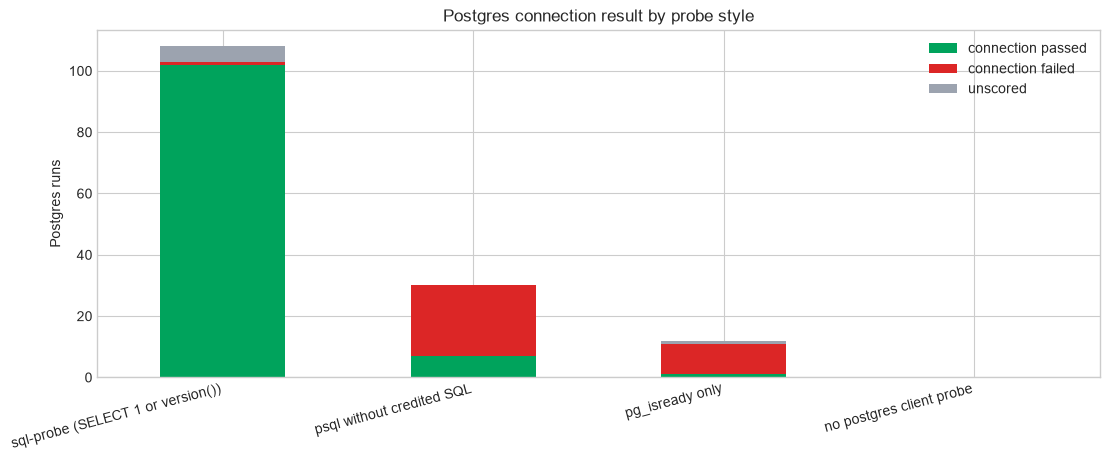

In [20]:
if not READY:
    print("Waiting for measurements.")
else:
    auth_sql = f"""
    SELECT
        run_id,
        countIf(positionCaseInsensitive(payload, 'MONGO_INITDB_ROOT_USERNAME') > 0) AS mongo_initdb_user_hits,
        countIf(positionCaseInsensitive(payload, 'MONGO_INITDB_ROOT_PASSWORD') > 0) AS mongo_initdb_password_hits,
        countIf(positionCaseInsensitive(payload, '--auth') > 0) AS mongo_auth_flag_hits,
        countIf(positionCaseInsensitive(payload, 'POSTGRES_PASSWORD') > 0) AS pg_password_hits,
        countIf(positionCaseInsensitive(payload, 'POSTGRES_USER') > 0) AS pg_user_hits,
        countIf(positionCaseInsensitive(payload, 'PGPASSWORD') > 0) AS pgpassword_hits,
        countIf(
            positionCaseInsensitive(payload, 'password authentication failed') > 0
            OR positionCaseInsensitive(payload, '28P01') > 0
            OR positionCaseInsensitive(payload, 'fe_sendauth') > 0
            OR positionCaseInsensitive(payload, 'no password supplied') > 0
        ) AS pg_auth_error_hits,
        countIf(positionCaseInsensitive(payload, 'pg_isready') > 0) AS pg_isready_hits,
        countIf(positionCaseInsensitive(payload, 'psql') > 0) AS psql_hits,
        countIf(positionCaseInsensitive(payload, 'SELECT 1') > 0) AS select_1_hits,
        countIf(positionCaseInsensitive(payload, 'select version') > 0) AS select_version_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
      AND prompt_id IN ('mongodb', 'postgresql')
    GROUP BY run_id
    """
    auth_flags = ax_query(auth_sql)
    auth_runs = runs[runs["database"].isin(["mongodb", "postgresql"])].merge(
        auth_flags, on="run_id", how="left"
    )
    for column in [
        "mongo_initdb_user_hits",
        "mongo_initdb_password_hits",
        "mongo_auth_flag_hits",
        "pg_password_hits",
        "pg_user_hits",
        "pgpassword_hits",
        "pg_auth_error_hits",
        "pg_isready_hits",
        "psql_hits",
        "select_1_hits",
        "select_version_hits",
    ]:
        auth_runs[column] = auth_runs[column].fillna(0)

    auth_runs["mongo_sets_initdb_root"] = (
        auth_runs["mongo_initdb_user_hits"].gt(0) & auth_runs["mongo_initdb_password_hits"].gt(0)
    )
    auth_runs["pg_sets_password"] = auth_runs["pg_password_hits"].gt(0)
    auth_runs["pg_auth_error"] = auth_runs["pg_auth_error_hits"].gt(0)
    auth_runs["pg_sql_probe"] = (
        auth_runs["select_1_hits"].gt(0) | auth_runs["select_version_hits"].gt(0)
    )

    mongo_auth = auth_runs[auth_runs["database"] == "mongodb"].copy()
    pg_auth = auth_runs[auth_runs["database"] == "postgresql"].copy()

    print("Credential env vars (boolean, per finished run):")
    cred_summary = pd.DataFrame(
        [
            {
                "database": "mongodb",
                "n": len(mongo_auth),
                "sets_initdb_root_user+password": int(mongo_auth["mongo_sets_initdb_root"].sum()),
                "sets_--auth": int(mongo_auth["mongo_auth_flag_hits"].gt(0).sum()),
                "sets_POSTGRES_PASSWORD": 0,
                "auth_error_in_transcript": int(
                    mongo_auth["pg_auth_error"].sum()
                ),
            },
            {
                "database": "postgresql",
                "n": len(pg_auth),
                "sets_initdb_root_user+password": 0,
                "sets_--auth": 0,
                "sets_POSTGRES_PASSWORD": int(pg_auth["pg_sets_password"].sum()),
                "auth_error_in_transcript": int(pg_auth["pg_auth_error"].sum()),
            },
        ]
    )
    display(cred_summary)

    print("Mongo INITDB root by agent/model:")
    mongo_auth_by_ext = (
        mongo_auth.groupby("extension", observed=True)
        .agg(
            n=("run_id", "size"),
            initdb_root=("mongo_sets_initdb_root", "sum"),
            auth_flag=("mongo_auth_flag_hits", lambda s: s.gt(0).sum()),
            passes=("both_tests_passed", "sum"),
        )
        .reset_index()
    )
    mongo_auth_by_ext["initdb_rate"] = mongo_auth_by_ext["initdb_root"] / mongo_auth_by_ext["n"]
    display(mongo_auth_by_ext.round(3))

    print("Mongo both-tests pass rate by whether INITDB root was set:")
    mongo_auth_pass = (
        mongo_auth.groupby("mongo_sets_initdb_root", observed=True)
        .agg(n=("run_id", "size"), passes=("both_tests_passed", "sum"))
        .reset_index()
        .rename(columns={"mongo_sets_initdb_root": "sets_initdb_root"})
    )
    mongo_auth_pass["rate"] = mongo_auth_pass["passes"] / mongo_auth_pass["n"]
    display(mongo_auth_pass.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    mongo_share = (
        mongo_auth.groupby("extension", observed=True)["mongo_sets_initdb_root"]
        .mean()
        .reindex(EXTENSION_ORDER)
        * 100
    )
    axes[0].bar(
        [label_of(name) for name in mongo_share.index],
        mongo_share.values,
        color=[COLORS.get(name, "#6B7280") for name in mongo_share.index],
    )
    axes[0].set_ylim(0, 105)
    axes[0].set_ylabel("% of Mongo runs")
    axes[0].set_title("Set MONGO_INITDB_ROOT_USERNAME+PASSWORD")
    axes[0].tick_params(axis="x", rotation=20)
    for tick in axes[0].get_xticklabels():
        tick.set_ha("right")

    pg_share = (
        pg_auth.groupby("extension", observed=True)["pg_sets_password"]
        .mean()
        .reindex(EXTENSION_ORDER)
        * 100
    )
    axes[1].bar(
        [label_of(name) for name in pg_share.index],
        pg_share.values,
        color=[COLORS.get(name, "#6B7280") for name in pg_share.index],
    )
    axes[1].set_ylim(0, 105)
    axes[1].set_ylabel("% of Postgres runs")
    axes[1].set_title("Set POSTGRES_PASSWORD")
    axes[1].tick_params(axis="x", rotation=20)
    for tick in axes[1].get_xticklabels():
        tick.set_ha("right")
    fig.suptitle("Optional Mongo auth vs required Postgres password", fontweight="bold")
    plt.show()

    connection = pd.DataFrame()
    if "tests" in globals() and not tests.empty:
        connection = tests[tests["test_name"] == "connection-verified-in-agent"][
            ["extension", "database", "repeat_idx", "passed"]
        ].rename(columns={"passed": "connection_passed"})
        pg_auth = pg_auth.merge(
            connection[connection["database"] == "postgresql"].drop(columns=["database"]),
            on=["extension", "repeat_idx"],
            how="left",
        )
    if "failures" in globals() and not failures.empty:
        pg_fail_modes = failures[
            (failures["database"] == "postgresql")
            & (failures["test_name"] == "connection-verified-in-agent")
        ][["extension", "repeat_idx", "failure_mode"]]
        pg_auth = pg_auth.merge(pg_fail_modes, on=["extension", "repeat_idx"], how="left")

    def classify_pg_probe(row) -> str:
        if bool(row.get("pg_sql_probe")):
            return "sql-probe (SELECT 1 or version())"
        if int(row.get("psql_hits") or 0) > 0:
            return "psql without credited SQL"
        if int(row.get("pg_isready_hits") or 0) > 0:
            return "pg_isready only"
        return "no postgres client probe"

    pg_auth["probe_style"] = pg_auth.apply(classify_pg_probe, axis=1)
    PROBE_ORDER = [
        "sql-probe (SELECT 1 or version())",
        "psql without credited SQL",
        "pg_isready only",
        "no postgres client probe",
    ]

    print("Postgres probe style vs connection-verified:")
    if "connection_passed" in pg_auth.columns:
        probe_xtab = (
            pd.crosstab(
                pg_auth["probe_style"],
                pg_auth["connection_passed"].map(
                    {True: "connection passed", False: "connection failed", np.nan: "unscored"}
                ),
                dropna=False,
            )
            .reindex(PROBE_ORDER)
            .fillna(0)
            .astype(int)
        )
        display(probe_xtab)
    else:
        display(
            pg_auth["probe_style"]
            .value_counts()
            .reindex(PROBE_ORDER)
            .fillna(0)
            .astype(int)
            .rename("n")
        )

    print("Postgres connection failure mode vs probe style (and auth-error flag):")
    if "failure_mode" in pg_auth.columns:
        failed = pg_auth[pg_auth["failure_mode"].notna()].copy()
        if failed.empty:
            print("No Postgres connection-test failure rows to join.")
        else:
            display(
                pd.crosstab(failed["failure_mode"], failed["probe_style"])
                .reindex(columns=PROBE_ORDER, fill_value=0)
            )
            print(
                "Auth-error strings among Postgres connection failures: "
                f"{int(failed['pg_auth_error'].sum())}/{len(failed)}."
            )
    print(
        "Auth-error strings among all Postgres runs: "
        f"{int(pg_auth['pg_auth_error'].sum())}/{len(pg_auth)}."
    )

    fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
    if "connection_passed" in pg_auth.columns:
        outcome = pg_auth["connection_passed"].map(
            {True: "connection passed", False: "connection failed"}
        ).fillna("unscored")
        pivot = (
            pd.crosstab(pg_auth["probe_style"], outcome)
            .reindex(PROBE_ORDER)
            .reindex(columns=["connection passed", "connection failed", "unscored"], fill_value=0)
        )
        pivot.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=["#00A35C", "#DC2626", "#9CA3AF"],
        )
        ax.set_xticklabels(pivot.index, rotation=15, ha="right")
        ax.set_ylabel("Postgres runs")
        ax.set_xlabel("")
        ax.set_title("Postgres connection result by probe style")
        ax.legend(frameon=False)
        plt.show()


## Postgres rates with `pg_isready` accepted

The official `test_output` on this request still uses the **old** packed
scorer (SQL required). The experiment YAML now accepts a successful
`pg_isready` as Postgres connection evidence; TCP-only (`nc`, `/dev/tcp`)
still fails.

This cell is a post-hoc rescore of the n=30 rows: keep the stored URI test,
and treat connection as passed if the stored test passed **or** the transcript
contains `pg_isready`. That is the closest replay of the new rule without
re-running AX tests.


Postgres connection-verified: stored scorer vs pg_isready-accepted:


,extension,n,connection_old,connection_new,both_old,both_new,pg_isready
0,claude-sonnet,30,29,30,29,29,29
1,cursor-sonnet,30,28,30,28,29,29
2,cursor-grok,30,10,30,10,29,30
3,cursor-terra,30,15,30,15,28,30
4,codex-terra,30,28,30,28,29,30


Pooled Postgres both-tests: 110/150 (73.3%) stored, 144/150 (96.0%) if pg_isready counts. Connection-verified 110 → 150 (40 flips).
Flipped rows by stored failure mode:


,failure_mode,n
0,readiness-only,33
1,unscored,6
2,no-app-level-op,1


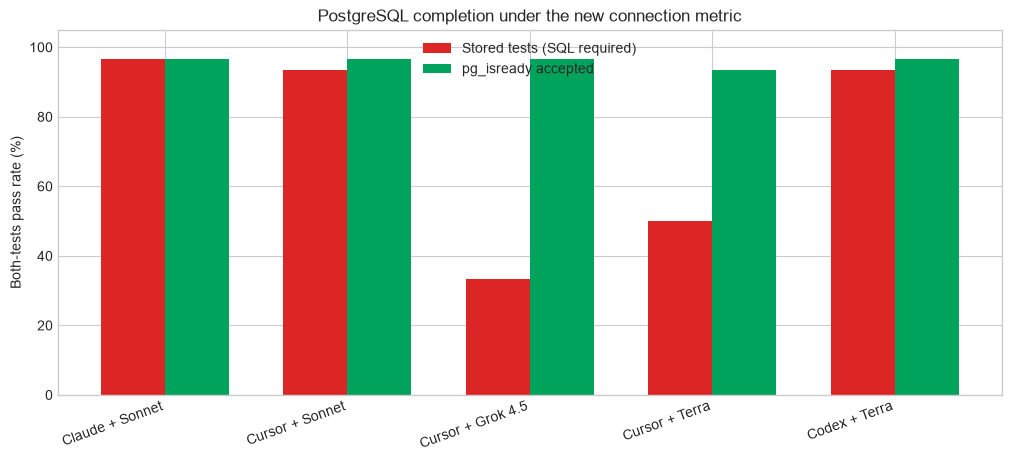

In [21]:
if not READY:
    print("Waiting for measurements.")
else:
    pg_ready_sql = f"""
    SELECT
        run_id,
        countIf(positionCaseInsensitive(payload, 'pg_isready') > 0) AS pg_isready_hits,
        countIf(positionCaseInsensitive(payload, 'nc ') > 0 AND position(payload, '5432') > 0) AS pg_nc_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
      AND prompt_id = 'postgresql'
    GROUP BY run_id
    """
    pg_ready_flags = ax_query(pg_ready_sql)
    pg_rescore = runs[runs["database"] == "postgresql"].merge(
        pg_ready_flags, on="run_id", how="left"
    )
    pg_rescore["pg_isready_hits"] = pg_rescore["pg_isready_hits"].fillna(0)
    pg_rescore["pg_nc_hits"] = pg_rescore["pg_nc_hits"].fillna(0)

    conn = pd.DataFrame()
    uri = pd.DataFrame()
    if "tests" in globals() and not tests.empty:
        conn = tests[
            (tests["database"] == "postgresql")
            & (tests["test_name"] == "connection-verified-in-agent")
        ][["extension", "repeat_idx", "passed"]].rename(
            columns={"passed": "connection_old"}
        )
        uri = tests[
            (tests["database"] == "postgresql")
            & (tests["test_name"] == "uri-reported")
        ][["extension", "repeat_idx", "passed"]].rename(columns={"passed": "uri_passed"})
        pg_rescore = pg_rescore.merge(conn, on=["extension", "repeat_idx"], how="left")
        pg_rescore = pg_rescore.merge(uri, on=["extension", "repeat_idx"], how="left")
    if "failures" in globals() and not failures.empty:
        pg_fail = failures[
            (failures["database"] == "postgresql")
            & (failures["test_name"] == "connection-verified-in-agent")
        ][["extension", "repeat_idx", "failure_mode"]]
        pg_rescore = pg_rescore.merge(pg_fail, on=["extension", "repeat_idx"], how="left")

    pg_rescore["has_pg_isready"] = pg_rescore["pg_isready_hits"].gt(0)
    pg_rescore["connection_new"] = (
        pg_rescore.get("connection_old", pd.Series(False, index=pg_rescore.index)).fillna(False)
        | pg_rescore["has_pg_isready"]
    )
    if "uri_passed" in pg_rescore.columns:
        pg_rescore["both_new"] = (
            pg_rescore["uri_passed"].fillna(False) & pg_rescore["connection_new"]
        )
    else:
        pg_rescore["both_new"] = pg_rescore["connection_new"]

    def rate_ci(frame, success_col, n_col="n"):
        rows = []
        for _, row in frame.iterrows():
            p, lo, hi = wilson_interval(row[success_col], row[n_col])
            rows.append((p, lo, hi))
        frame = frame.copy()
        frame["rate"], frame["lo"], frame["hi"] = zip(*rows)
        frame["rate_pct"] = frame["rate"] * 100
        return frame

    print("Postgres connection-verified: stored scorer vs pg_isready-accepted:")
    by_ext = (
        pg_rescore.groupby("extension", observed=True)
        .agg(
            n=("run_id", "size"),
            connection_old=("connection_old", "sum")
            if "connection_old" in pg_rescore.columns
            else ("run_id", "size"),
            connection_new=("connection_new", "sum"),
            both_old=("both_tests_passed", "sum"),
            both_new=("both_new", "sum"),
            pg_isready=("has_pg_isready", "sum"),
        )
        .reindex(EXTENSION_ORDER)
        .reset_index()
    )
    display(by_ext)

    old_pass = int(pg_rescore["both_tests_passed"].sum())
    new_pass = int(pg_rescore["both_new"].sum())
    n_pg = len(pg_rescore)
    old_conn = (
        int(pg_rescore["connection_old"].fillna(False).sum())
        if "connection_old" in pg_rescore.columns
        else old_pass
    )
    new_conn = int(pg_rescore["connection_new"].sum())
    flipped = 0
    if "connection_old" in pg_rescore.columns:
        flipped = int(
            (~pg_rescore["connection_old"].fillna(False) & pg_rescore["connection_new"]).sum()
        )
    print(
        f"Pooled Postgres both-tests: {old_pass}/{n_pg} ({old_pass / n_pg:.1%}) stored, "
        f"{new_pass}/{n_pg} ({new_pass / n_pg:.1%}) if pg_isready counts. "
        f"Connection-verified {old_conn} → {new_conn} ({flipped} flips)."
    )
    if "failure_mode" in pg_rescore.columns:
        flipped_modes = pg_rescore.loc[
            ~pg_rescore.get("connection_old", pd.Series(False, index=pg_rescore.index)).fillna(False)
            & pg_rescore["connection_new"],
            "failure_mode",
        ]
        print("Flipped rows by stored failure mode:")
        display(flipped_modes.fillna("unscored").value_counts().rename("n").reset_index())

    fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
    x = np.arange(len(by_ext))
    width = 0.35
    ax.bar(
        x - width / 2,
        by_ext["both_old"] / by_ext["n"] * 100,
        width,
        label="Stored tests (SQL required)",
        color="#DC2626",
    )
    ax.bar(
        x + width / 2,
        by_ext["both_new"] / by_ext["n"] * 100,
        width,
        label="pg_isready accepted",
        color="#00A35C",
    )
    ax.set_xticks(x, [label_of(name) for name in by_ext["extension"]], rotation=20, ha="right")
    ax.set_ylim(0, 105)
    ax.set_ylabel("Both-tests pass rate (%)")
    ax.set_title("PostgreSQL completion under the new connection metric")
    ax.legend(frameon=False)
    plt.show()


## Mongo verification-style taxonomy

`connection-verified-in-agent` is binary. This section classifies *how* each
Mongo run probed the server, from tool-call boolean evidence:

| Style | Evidence |
| --- | --- |
| `crud-roundtrip` | insert **and** find |
| `crud-partial` | insert **or** find, but not both |
| `driver-or-collection` | `MongoClient` / `pymongo` / `.collection(` |
| `list-databases` | `listDatabases` / `show dbs` |
| `ping-or-hello` | `{ping:1}` / `hello` |
| `serverStatus` | `serverStatus` |
| `runCommand-other` | `db.runCommand` / `db.adminCommand` without ping |
| `mongosh-other` | `mongosh` with none of the above |
| `none` | no Mongo client evidence |

The official scorer treats `db.runCommand({ping:1})` as an application-level
operation, so ping-only runs can still pass. CRUD is the stricter bar the
writeup may want.


Mongo verification style (one strongest label per run):


,verify_style,n,passes,rate
0,driver-or-collection,8,7,0.875
1,ping-or-hello,131,119,0.908
2,runCommand-other,9,9,1.000


Evidence flags (runs with at least one hit; a run can appear in several rows):


,evidence,runs,share
0,insert,0,0.000
1,find,0,0.000
2,ping/hello,139,0.939
3,serverStatus,0,0.000
4,listDatabases,0,0.000
5,MongoClient/pymongo,0,0.000
6,collection(,8,0.054
7,db.runCommand,105,0.709
8,db.adminCommand,42,0.284
9,mongosh,148,1.000


Verification style by agent/model:


verify_style,driver-or-collection,ping-or-hello,runCommand-other
extension,,,
claude-sonnet,0,24,6
cursor-sonnet,0,25,3
cursor-grok,3,27,0
cursor-terra,1,29,0
codex-terra,4,26,0


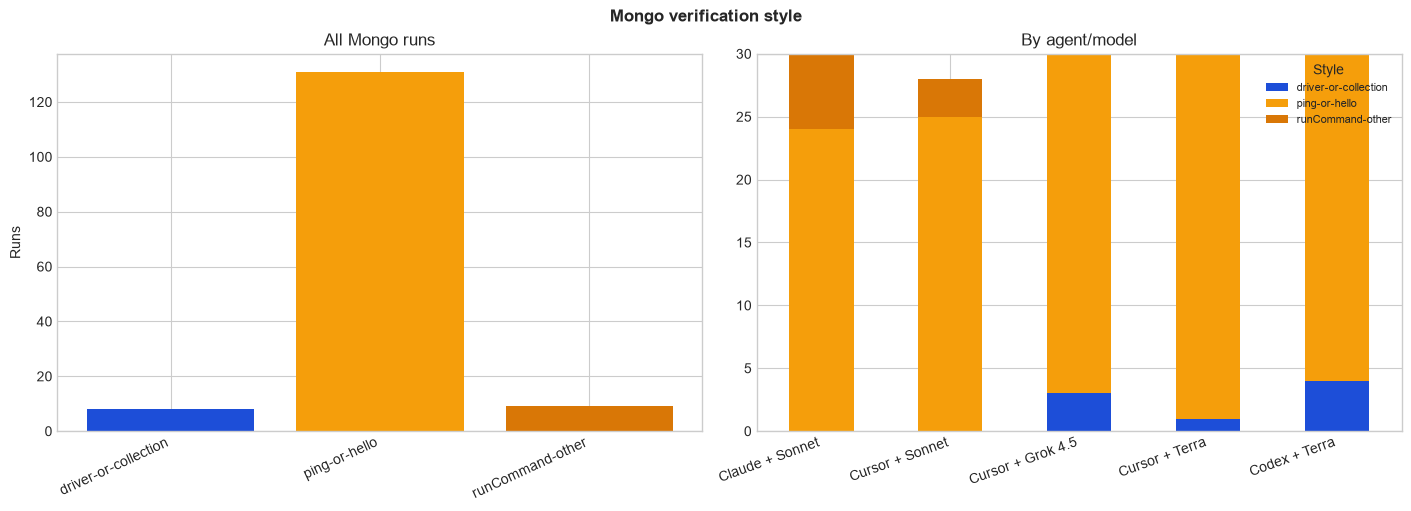

Verification style vs connection-verified-in-agent:


connection_passed,connection passed,connection failed,unscored
verify_style,,,
driver-or-collection,7,1,0
ping-or-hello,119,4,8
runCommand-other,9,0,0


Official failure mode vs classified style (Mongo connection misses):


verify_style,driver-or-collection,ping-or-hello
failure_mode,,
no-app-level-op,1,2
readiness-only,0,2


In [22]:
if not READY:
    print("Waiting for measurements.")
else:
    VERIFY_ORDER = [
        "crud-roundtrip",
        "crud-partial",
        "driver-or-collection",
        "list-databases",
        "ping-or-hello",
        "serverStatus",
        "runCommand-other",
        "mongosh-other",
        "none",
    ]
    VERIFY_COLORS = {
        "crud-roundtrip": "#00A35C",
        "crud-partial": "#86EFAC",
        "driver-or-collection": "#1D4ED8",
        "list-databases": "#7C3AED",
        "ping-or-hello": "#F59E0B",
        "serverStatus": "#EA580C",
        "runCommand-other": "#D97706",
        "mongosh-other": "#9CA3AF",
        "none": "#E5E7EB",
    }

    verify_sql = f"""
    SELECT
        run_id,
        countIf(
            positionCaseInsensitive(payload, 'insertOne') > 0
            OR positionCaseInsensitive(payload, 'insertMany') > 0
            OR positionCaseInsensitive(payload, '.insert(') > 0
        ) AS insert_hits,
        countIf(
            positionCaseInsensitive(payload, 'findOne') > 0
            OR positionCaseInsensitive(payload, '.find(') > 0
        ) AS find_hits,
        countIf(
            positionCaseInsensitive(payload, 'ping:1') > 0
            OR positionCaseInsensitive(payload, 'ping: 1') > 0
            OR positionCaseInsensitive(payload, 'hello:1') > 0
            OR positionCaseInsensitive(payload, 'hello: 1') > 0
        ) AS ping_hits,
        countIf(positionCaseInsensitive(payload, 'serverStatus') > 0) AS serverstatus_hits,
        countIf(
            positionCaseInsensitive(payload, 'listDatabases') > 0
            OR positionCaseInsensitive(payload, 'show dbs') > 0
            OR positionCaseInsensitive(payload, 'show databases') > 0
        ) AS listdbs_hits,
        countIf(
            positionCaseInsensitive(payload, 'MongoClient') > 0
            OR positionCaseInsensitive(payload, 'pymongo') > 0
        ) AS driver_hits,
        countIf(positionCaseInsensitive(payload, 'collection(') > 0) AS collection_hits,
        countIf(positionCaseInsensitive(payload, 'db.runCommand') > 0) AS runcommand_hits,
        countIf(positionCaseInsensitive(payload, 'db.adminCommand') > 0) AS admincommand_hits,
        countIf(positionCaseInsensitive(payload, 'mongosh') > 0) AS mongosh_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
      AND prompt_id = 'mongodb'
    GROUP BY run_id
    """
    verify_flags = ax_query(verify_sql)
    mongo_verify = runs[runs["database"] == "mongodb"].merge(
        verify_flags, on="run_id", how="left"
    )
    for column in [
        "insert_hits",
        "find_hits",
        "ping_hits",
        "serverstatus_hits",
        "listdbs_hits",
        "driver_hits",
        "collection_hits",
        "runcommand_hits",
        "admincommand_hits",
        "mongosh_hits",
    ]:
        mongo_verify[column] = mongo_verify[column].fillna(0)

    def classify_mongo_verify(row) -> str:
        insert = int(row.get("insert_hits") or 0) > 0
        find = int(row.get("find_hits") or 0) > 0
        if insert and find:
            return "crud-roundtrip"
        if insert or find:
            return "crud-partial"
        if int(row.get("driver_hits") or 0) > 0 or int(row.get("collection_hits") or 0) > 0:
            return "driver-or-collection"
        if int(row.get("listdbs_hits") or 0) > 0:
            return "list-databases"
        if int(row.get("ping_hits") or 0) > 0:
            return "ping-or-hello"
        if int(row.get("serverstatus_hits") or 0) > 0:
            return "serverStatus"
        if int(row.get("runcommand_hits") or 0) > 0 or int(row.get("admincommand_hits") or 0) > 0:
            return "runCommand-other"
        if int(row.get("mongosh_hits") or 0) > 0:
            return "mongosh-other"
        return "none"

    mongo_verify["verify_style"] = mongo_verify.apply(classify_mongo_verify, axis=1)
    mongo_verify["verify_style"] = pd.Categorical(
        mongo_verify["verify_style"], categories=VERIFY_ORDER, ordered=True
    )

    if "tests" in globals() and not tests.empty:
        mongo_conn = tests[
            (tests["database"] == "mongodb")
            & (tests["test_name"] == "connection-verified-in-agent")
        ][["extension", "repeat_idx", "passed"]].rename(columns={"passed": "connection_passed"})
        mongo_verify = mongo_verify.merge(mongo_conn, on=["extension", "repeat_idx"], how="left")
    if "failures" in globals() and not failures.empty:
        mongo_fail = failures[
            (failures["database"] == "mongodb")
            & (failures["test_name"] == "connection-verified-in-agent")
        ][["extension", "repeat_idx", "failure_mode"]]
        mongo_verify = mongo_verify.merge(
            mongo_fail, on=["extension", "repeat_idx"], how="left"
        )

    print("Mongo verification style (one strongest label per run):")
    style_counts = (
        mongo_verify.groupby("verify_style", observed=True)
        .agg(n=("run_id", "size"), passes=("both_tests_passed", "sum"))
        .reindex(VERIFY_ORDER)
        .dropna(how="all")
        .reset_index()
    )
    style_counts["n"] = style_counts["n"].fillna(0).astype(int)
    style_counts["passes"] = style_counts["passes"].fillna(0).astype(int)
    style_counts["rate"] = style_counts["passes"] / style_counts["n"].replace(0, np.nan)
    display(style_counts.round(3))

    print("Evidence flags (runs with at least one hit; a run can appear in several rows):")
    flag_table = pd.DataFrame(
        {
            "evidence": [
                "insert",
                "find",
                "ping/hello",
                "serverStatus",
                "listDatabases",
                "MongoClient/pymongo",
                "collection(",
                "db.runCommand",
                "db.adminCommand",
                "mongosh",
            ],
            "runs": [
                int(mongo_verify["insert_hits"].gt(0).sum()),
                int(mongo_verify["find_hits"].gt(0).sum()),
                int(mongo_verify["ping_hits"].gt(0).sum()),
                int(mongo_verify["serverstatus_hits"].gt(0).sum()),
                int(mongo_verify["listdbs_hits"].gt(0).sum()),
                int(mongo_verify["driver_hits"].gt(0).sum()),
                int(mongo_verify["collection_hits"].gt(0).sum()),
                int(mongo_verify["runcommand_hits"].gt(0).sum()),
                int(mongo_verify["admincommand_hits"].gt(0).sum()),
                int(mongo_verify["mongosh_hits"].gt(0).sum()),
            ],
        }
    )
    flag_table["share"] = flag_table["runs"] / len(mongo_verify)
    display(flag_table.round(3))

    print("Verification style by agent/model:")
    style_xtab = (
        pd.crosstab(mongo_verify["extension"], mongo_verify["verify_style"])
        .reindex(EXTENSION_ORDER)
        .reindex(
            columns=[name for name in VERIFY_ORDER if name in set(mongo_verify["verify_style"])],
            fill_value=0,
        )
    )
    display(style_xtab)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    present_styles = [name for name in VERIFY_ORDER if name in set(mongo_verify["verify_style"])]
    overall = (
        mongo_verify["verify_style"]
        .value_counts()
        .reindex(present_styles, fill_value=0)
    )
    axes[0].bar(
        [str(name) for name in overall.index],
        overall.values,
        color=[VERIFY_COLORS.get(name, "#9CA3AF") for name in overall.index],
    )
    axes[0].set_title("All Mongo runs")
    axes[0].set_ylabel("Runs")
    axes[0].tick_params(axis="x", rotation=25)
    for tick in axes[0].get_xticklabels():
        tick.set_ha("right")

    style_xtab.plot(
        kind="bar",
        stacked=True,
        ax=axes[1],
        color=[VERIFY_COLORS.get(column, "#9CA3AF") for column in style_xtab.columns],
    )
    axes[1].set_title("By agent/model")
    axes[1].set_xlabel("")
    axes[1].set_xticklabels([label_of(name) for name in style_xtab.index], rotation=20, ha="right")
    axes[1].legend(title="Style", frameon=False, fontsize=8)
    fig.suptitle("Mongo verification style", fontweight="bold")
    plt.show()

    if "connection_passed" in mongo_verify.columns:
        print("Verification style vs connection-verified-in-agent:")
        outcome = mongo_verify["connection_passed"].map(
            {True: "connection passed", False: "connection failed"}
        ).fillna("unscored")
        display(
            pd.crosstab(mongo_verify["verify_style"], outcome)
            .reindex(present_styles)
            .reindex(columns=["connection passed", "connection failed", "unscored"], fill_value=0)
        )
    if "failure_mode" in mongo_verify.columns:
        failed = mongo_verify[mongo_verify["failure_mode"].notna()]
        if not failed.empty:
            print("Official failure mode vs classified style (Mongo connection misses):")
            display(pd.crosstab(failed["failure_mode"], failed["verify_style"]))


## Best-practice defaults (not scored)

The official tests do not score image choice, volumes, least privilege, or
reproducibility. These cells do. Counts are boolean evidence from tool calls
(no URIs or passwords in output). Treat them as **defaults under this prompt**,
not as a failure of the agent: the prompt asked for a working URI.

Family of findings:

1. **Image** — `mongo` Hub image, never MongoDB-maintained (section above).
2. **Auth** — Postgres always sets a password; Mongo often INITDB root, or
   no auth (section above).
3. **Durability** — volume vs restart-only vs ephemeral.
4. **Least privilege** — scoped app user vs root vs no-auth.
5. **Reproducibility** — compose/README vs named container + restart vs
   session-only.

Headline to test against the tables: agents can provision Mongo; the default
is often an unnamed-data, root-or-open, live-only Docker container on the
legacy Hub image.

## Best-practice gap: durability

The official tests ask whether the database **accepts connections**. They do not
ask whether the data **survives `docker rm`**. A named container with no volume
is live for this session and gone tomorrow.

Signals (tool-call boolean evidence; no payloads):

| Signal | Meaning |
| --- | --- |
| `docker run` + `-v` / `--volume` / `--mount` | bind or named volume on the container |
| `docker volume create` | explicit named volume (subset of the above) |
| SQLite file path (non-container) | the database *is* a file; durable by construction |

`--restart unless-stopped` is operational durability (container comes back
after a reboot) and is counted separately — it does not persist data if the
writable layer is still ephemeral.

Prediction: well under half of Mongo/Postgres Docker runs mount a volume;
SQLite on the file path accidentally scores better.

Durability class by database (one label per finished run):


durability,volume-or-file,restart-only,ephemeral
database,,,
mongodb,68,25,55
postgresql,47,23,80
sqlite,144,0,1



Raw signals (tool-call hits, not mutually exclusive):


,database,n,docker_run_volume,docker_volume_create,restart_policy
0,mongodb,148,68,27,85
1,postgresql,150,47,22,66
2,sqlite,145,23,2,7


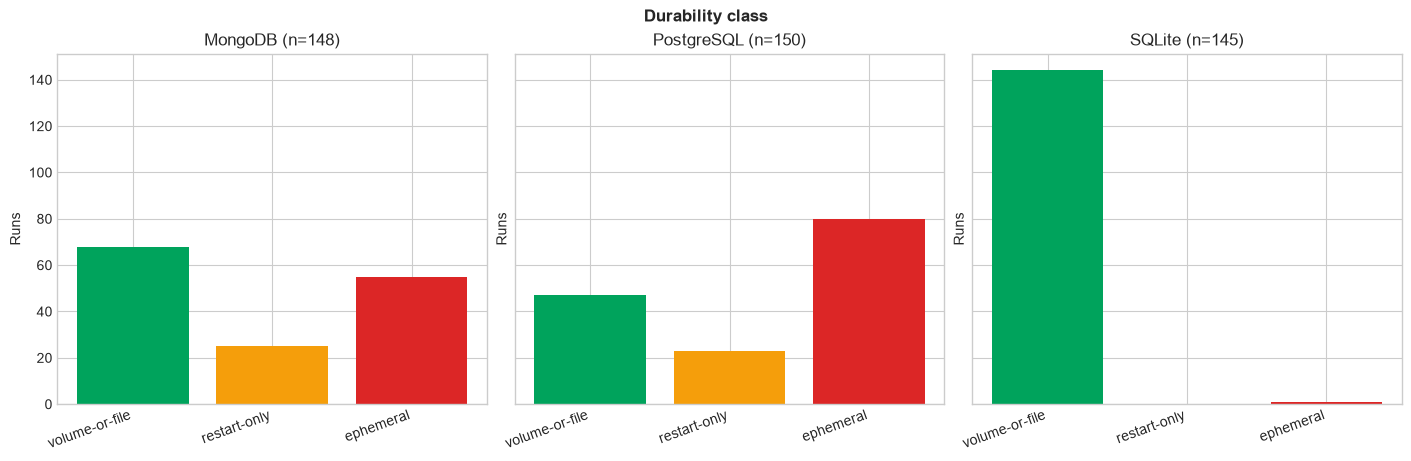

Mongo / Postgres durability by agent/model:


durability                volume-or-file  restart-only  ephemeral
extension     database                                           
claude-sonnet mongodb                  9             5         16
              postgresql               5             0         25
cursor-sonnet mongodb                 12             2         14
              postgresql               8             2         20
cursor-grok   mongodb                  2             4         24
              postgresql               0             0         30
cursor-terra  mongodb                 24             5          1
              postgresql              10            15          5
codex-terra   mongodb                 21             9          0
              postgresql              24             6          0

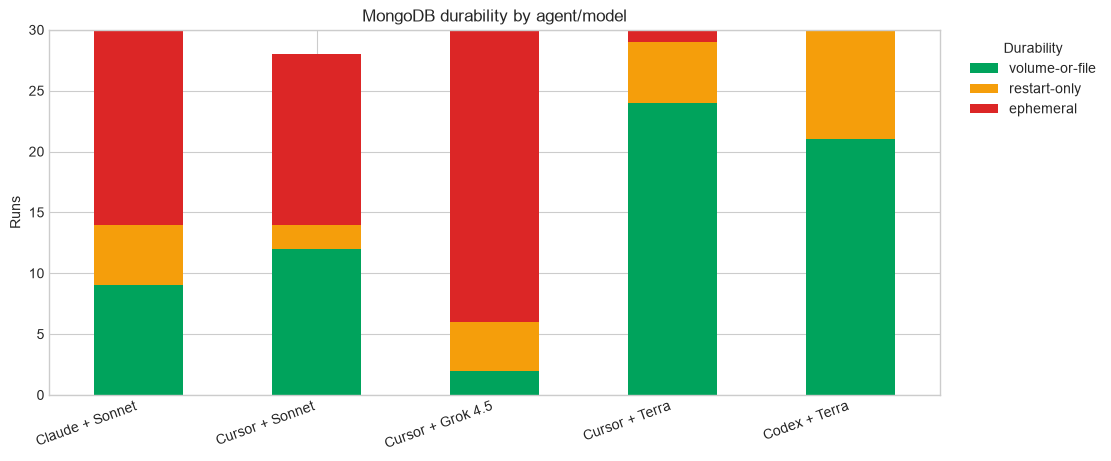

In [23]:
if not READY:
    print("Waiting for measurements.")
else:
    DURABLE_ORDER = ["volume-or-file", "restart-only", "ephemeral"]
    DURABLE_COLORS = {
        "volume-or-file": "#00A35C",
        "restart-only": "#F59E0B",
        "ephemeral": "#DC2626",
    }

    durable_sql = f"""
    SELECT
        run_id,
        countIf(
            positionCaseInsensitive(payload, 'docker run') > 0
            AND (
                match(payload, '(?i)[[:space:]](-v|--volume)[[:space:]=]') > 0
                OR positionCaseInsensitive(payload, '--mount') > 0
            )
        ) AS docker_volume_hits,
        countIf(positionCaseInsensitive(payload, 'docker volume create') > 0) AS volume_create_hits,
        countIf(
            positionCaseInsensitive(payload, 'docker run') > 0
            AND (
                positionCaseInsensitive(payload, '--restart unless-stopped') > 0
                OR positionCaseInsensitive(payload, '--restart=unless-stopped') > 0
                OR positionCaseInsensitive(payload, '--restart always') > 0
                OR positionCaseInsensitive(payload, '--restart=always') > 0
            )
        ) AS restart_hits,
        countIf(positionCaseInsensitive(payload, 'docker run') > 0) AS docker_run_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
    GROUP BY run_id
    """
    durable_flags = ax_query(durable_sql)
    durable_runs = runs.merge(durable_flags, on="run_id", how="left")
    for column in ["docker_volume_hits", "volume_create_hits", "restart_hits", "docker_run_hits"]:
        durable_runs[column] = durable_runs[column].fillna(0)

    if "method_runs" in globals() and not method_runs.empty:
        durable_runs = durable_runs.merge(
            method_runs[["run_id", "final_method"]],
            on="run_id",
            how="left",
        )
    else:
        durable_runs["final_method"] = pd.NA

    def classify_durability(row) -> str:
        database = str(row.get("database") or "")
        has_volume = int(row.get("docker_volume_hits") or 0) > 0
        has_restart = int(row.get("restart_hits") or 0) > 0
        used_docker = int(row.get("docker_run_hits") or 0) > 0
        method = str(row.get("final_method") or "")
        if database == "sqlite":
            if method == "container" or (used_docker and method not in {"built-in-library"}):
                if has_volume:
                    return "volume-or-file"
                if has_restart:
                    return "restart-only"
                return "ephemeral"
            return "volume-or-file"
        if has_volume:
            return "volume-or-file"
        if has_restart:
            return "restart-only"
        return "ephemeral"

    durable_runs["durability"] = durable_runs.apply(classify_durability, axis=1)
    durable_runs["durability"] = pd.Categorical(
        durable_runs["durability"], categories=DURABLE_ORDER, ordered=True
    )

    print("Durability class by database (one label per finished run):")
    durable_xtab = (
        pd.crosstab(durable_runs["database"], durable_runs["durability"])
        .reindex(DATABASE_ORDER)
        .reindex(columns=DURABLE_ORDER, fill_value=0)
    )
    display(durable_xtab)

    print("\nRaw signals (tool-call hits, not mutually exclusive):")
    signal_rows = []
    for database in DATABASE_ORDER:
        subset = durable_runs[durable_runs["database"] == database]
        n = len(subset)
        signal_rows.append(
            {
                "database": database,
                "n": n,
                "docker_run_volume": int(subset["docker_volume_hits"].gt(0).sum()),
                "docker_volume_create": int(subset["volume_create_hits"].gt(0).sum()),
                "restart_policy": int(subset["restart_hits"].gt(0).sum()),
            }
        )
    display(pd.DataFrame(signal_rows))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        subset = durable_runs[durable_runs["database"] == database]
        counts = subset["durability"].value_counts().reindex(DURABLE_ORDER, fill_value=0)
        ax.bar(
            [str(name) for name in counts.index],
            counts.values,
            color=[DURABLE_COLORS[name] for name in counts.index],
        )
        ax.set_title(f"{label_of(database)} (n={len(subset)})")
        ax.set_ylabel("Runs")
        ax.tick_params(axis="x", rotation=20)
        for tick in ax.get_xticklabels():
            tick.set_ha("right")
    fig.suptitle("Durability class", fontweight="bold")
    plt.show()

    print("Mongo / Postgres durability by agent/model:")
    server_durable = durable_runs[durable_runs["database"].isin(["mongodb", "postgresql"])]
    durable_ext = (
        pd.crosstab(
            [server_durable["extension"], server_durable["database"]],
            server_durable["durability"],
        )
        .reindex(columns=DURABLE_ORDER, fill_value=0)
    )
    display(durable_ext)

    fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
    mongo_only = durable_runs[durable_runs["database"] == "mongodb"]
    mongo_xtab = (
        pd.crosstab(mongo_only["extension"], mongo_only["durability"])
        .reindex(EXTENSION_ORDER)
        .reindex(columns=DURABLE_ORDER, fill_value=0)
    )
    mongo_xtab.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[DURABLE_COLORS[column] for column in mongo_xtab.columns],
    )
    ax.set_title("MongoDB durability by agent/model")
    ax.set_xlabel("")
    ax.set_ylabel("Runs")
    ax.set_xticklabels([label_of(name) for name in mongo_xtab.index], rotation=20, ha="right")
    ax.legend(title="Durability", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

## Best-practice gap: least privilege

A reported URI that authenticates as the image's bootstrap superuser is
convenient and is **not** least privilege. The bar here is whether the agent
created a scoped application user (`db.createUser` / `CREATE USER` / `GRANT`)
rather than handing out root.

Auth *enabled* is a weaker, separate bar (already measured above as
`MONGO_INITDB_ROOT_*` vs Postgres `POSTGRES_PASSWORD`). This section asks:
even when credentials exist, are they the **root** credentials?

| Class | Evidence |
| --- | --- |
| `scoped-app-user` | `db.createUser` / `createUser(` / `CREATE USER` / `CREATE ROLE` / `GRANT ` |
| `root-credentials` | Mongo `MONGO_INITDB_ROOT_*`, or Postgres `POSTGRES_PASSWORD`, and no scoped user |
| `no-auth` | Mongo with neither INITDB root nor scoped user |
| `n/a` | SQLite |

The prompt never asked for an app user, so this measures the default. Do not
print URIs or password strings — counts only.

Privilege class by database:


privilege,scoped-app-user,root-credentials,no-auth,n/a
database,,,,
mongodb,0,108,40,0
postgresql,1,149,0,0
sqlite,0,0,0,145



Mongo db.createUser: 0/148
Mongo MONGO_INITDB_DATABASE (still the root user, just a default DB): 17/148
Postgres CREATE USER / CREATE ROLE / GRANT: 1/150


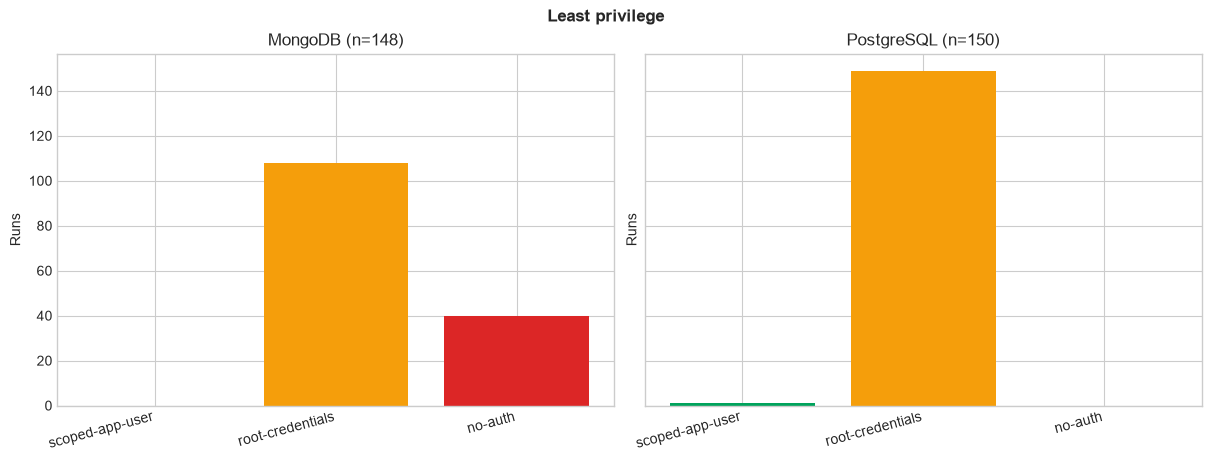

Mongo privilege by agent/model:


privilege,scoped-app-user,root-credentials,no-auth
extension,,,
claude-sonnet,0,30,0
cursor-sonnet,0,26,2
cursor-grok,0,23,7
cursor-terra,0,18,12
codex-terra,0,11,19


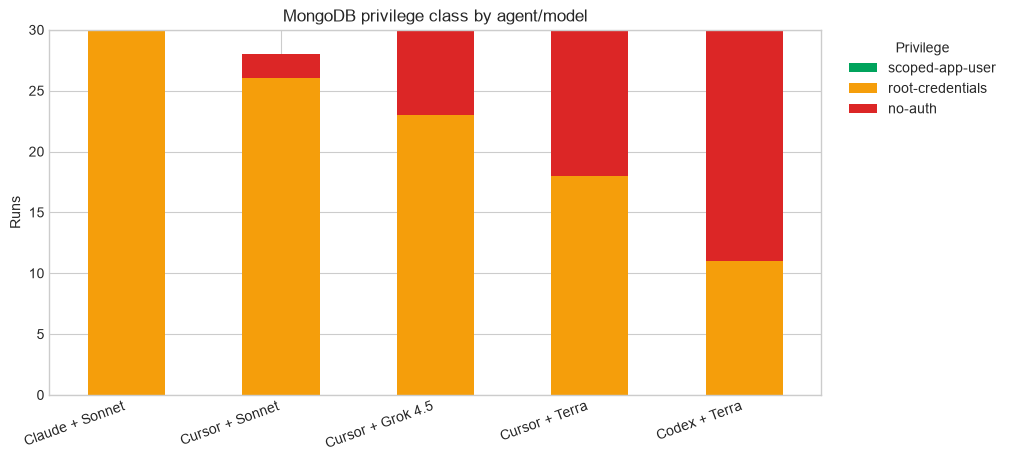

In [24]:
if not READY:
    print("Waiting for measurements.")
else:
    PRIV_ORDER = ["scoped-app-user", "root-credentials", "no-auth", "n/a"]
    PRIV_COLORS = {
        "scoped-app-user": "#00A35C",
        "root-credentials": "#F59E0B",
        "no-auth": "#DC2626",
        "n/a": "#9CA3AF",
    }

    priv_sql = f"""
    SELECT
        run_id,
        countIf(
            positionCaseInsensitive(payload, 'db.createUser') > 0
            OR positionCaseInsensitive(payload, 'createUser(') > 0
        ) AS mongo_createuser_hits,
        countIf(positionCaseInsensitive(payload, 'MONGO_INITDB_ROOT_USERNAME') > 0) AS mongo_root_user_hits,
        countIf(positionCaseInsensitive(payload, 'MONGO_INITDB_ROOT_PASSWORD') > 0) AS mongo_root_password_hits,
        countIf(positionCaseInsensitive(payload, 'MONGO_INITDB_DATABASE') > 0) AS mongo_initdb_database_hits,
        countIf(
            positionCaseInsensitive(payload, 'CREATE USER') > 0
            OR positionCaseInsensitive(payload, 'CREATE ROLE') > 0
            OR match(payload, '(?i)GRANT[[:space:]]') > 0
        ) AS sql_scoped_user_hits,
        countIf(positionCaseInsensitive(payload, 'POSTGRES_PASSWORD') > 0) AS pg_password_hits,
        countIf(positionCaseInsensitive(payload, 'POSTGRES_USER') > 0) AS pg_user_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
    GROUP BY run_id
    """
    priv_flags = ax_query(priv_sql)
    priv_runs = runs.merge(priv_flags, on="run_id", how="left")
    for column in [
        "mongo_createuser_hits",
        "mongo_root_user_hits",
        "mongo_root_password_hits",
        "mongo_initdb_database_hits",
        "sql_scoped_user_hits",
        "pg_password_hits",
        "pg_user_hits",
    ]:
        priv_runs[column] = priv_runs[column].fillna(0)

    def classify_privilege(row) -> str:
        database = str(row.get("database") or "")
        if database == "sqlite":
            return "n/a"
        scoped = (
            int(row.get("mongo_createuser_hits") or 0) > 0
            or int(row.get("sql_scoped_user_hits") or 0) > 0
        )
        if scoped:
            return "scoped-app-user"
        if database == "mongodb":
            if (
                int(row.get("mongo_root_user_hits") or 0) > 0
                and int(row.get("mongo_root_password_hits") or 0) > 0
            ):
                return "root-credentials"
            return "no-auth"
        if int(row.get("pg_password_hits") or 0) > 0:
            return "root-credentials"
        return "no-auth"

    priv_runs["privilege"] = priv_runs.apply(classify_privilege, axis=1)
    priv_runs["privilege"] = pd.Categorical(
        priv_runs["privilege"], categories=PRIV_ORDER, ordered=True
    )

    print("Privilege class by database:")
    priv_xtab = (
        pd.crosstab(priv_runs["database"], priv_runs["privilege"])
        .reindex(DATABASE_ORDER)
        .reindex(columns=PRIV_ORDER, fill_value=0)
    )
    display(priv_xtab)

    mongo_priv = priv_runs[priv_runs["database"] == "mongodb"]
    n_mongo = len(mongo_priv)
    n_initdb_db = int(mongo_priv["mongo_initdb_database_hits"].gt(0).sum())
    print(
        f"\nMongo db.createUser: "
        f"{int(mongo_priv['mongo_createuser_hits'].gt(0).sum())}/{n_mongo}"
    )
    print(
        f"Mongo MONGO_INITDB_DATABASE (still the root user, just a default DB): "
        f"{n_initdb_db}/{n_mongo}"
    )
    pg_priv = priv_runs[priv_runs["database"] == "postgresql"]
    print(
        f"Postgres CREATE USER / CREATE ROLE / GRANT: "
        f"{int(pg_priv['sql_scoped_user_hits'].gt(0).sum())}/{len(pg_priv)}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, ["mongodb", "postgresql"]):
        subset = priv_runs[priv_runs["database"] == database]
        counts = subset["privilege"].value_counts().reindex(
            [name for name in PRIV_ORDER if name != "n/a"], fill_value=0
        )
        ax.bar(
            [str(name) for name in counts.index],
            counts.values,
            color=[PRIV_COLORS[name] for name in counts.index],
        )
        ax.set_title(f"{label_of(database)} (n={len(subset)})")
        ax.set_ylabel("Runs")
        ax.tick_params(axis="x", rotation=15)
        for tick in ax.get_xticklabels():
            tick.set_ha("right")
    fig.suptitle("Least privilege", fontweight="bold")
    plt.show()

    print("Mongo privilege by agent/model:")
    mongo_priv_xtab = (
        pd.crosstab(mongo_priv["extension"], mongo_priv["privilege"])
        .reindex(EXTENSION_ORDER)
        .reindex(columns=[name for name in PRIV_ORDER if name != "n/a"], fill_value=0)
    )
    display(mongo_priv_xtab)

    fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
    mongo_priv_xtab.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[PRIV_COLORS.get(column, "#9CA3AF") for column in mongo_priv_xtab.columns],
    )
    ax.set_title("MongoDB privilege class by agent/model")
    ax.set_xlabel("")
    ax.set_ylabel("Runs")
    ax.set_xticklabels([label_of(name) for name in mongo_priv_xtab.index], rotation=20, ha="right")
    ax.legend(title="Privilege", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

## Best-practice gap: reproducibility

Can a teammate reconstruct the database from an artifact, or does it exist
only as a live container in this sandbox?

| Class | Evidence |
| --- | --- |
| `compose-or-docs` | `docker-compose.yml` / `compose.yaml`, `Dockerfile`, or `README.md` |
| `named+restart` | `docker run --name` **and** `--restart unless-stopped` / `always` |
| `named-only` | `docker run --name` without restart or compose |
| `workspace-file` | SQLite on the file path, no compose/README |
| `none` | no named container, no file DB, no artifact |

`--name` is session-local reproducibility (`docker start` this box). A compose
file is portable reproducibility (`docker compose up` on another machine).
Those are different bars — collapsing them would hide the finding if agents
name containers constantly and never write compose.

Reproducibility class by database:


reproducibility,compose-or-docs,named+restart,named-only,workspace-file,none
database,,,,,
mongodb,7,79,62,0,0
postgresql,1,65,83,0,1
sqlite,10,6,13,116,0



Raw signals:


,database,n,compose_file,dockerfile,readme.md,docker_run --name,restart policy
0,mongodb,148,1,6,0,148,85
1,postgresql,150,0,1,0,149,66
2,sqlite,145,3,2,5,23,7


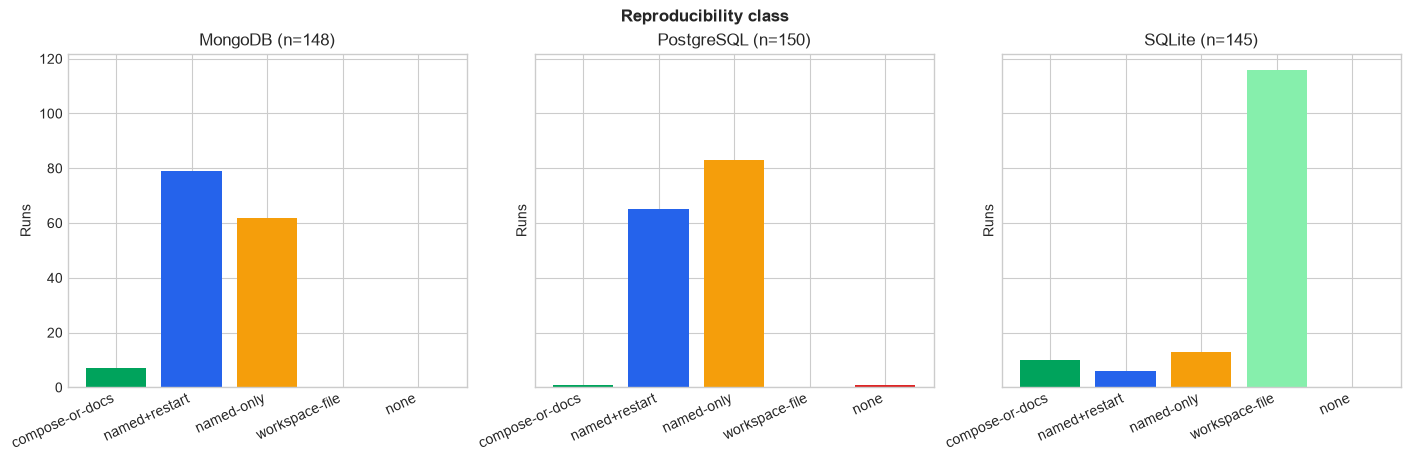

Mongo reproducibility by agent/model:


reproducibility,compose-or-docs,named+restart,named-only,workspace-file,none
extension,,,,,
claude-sonnet,0,12,18,0,0
cursor-sonnet,0,11,17,0,0
cursor-grok,0,5,25,0,0
cursor-terra,2,26,2,0,0
codex-terra,5,25,0,0,0


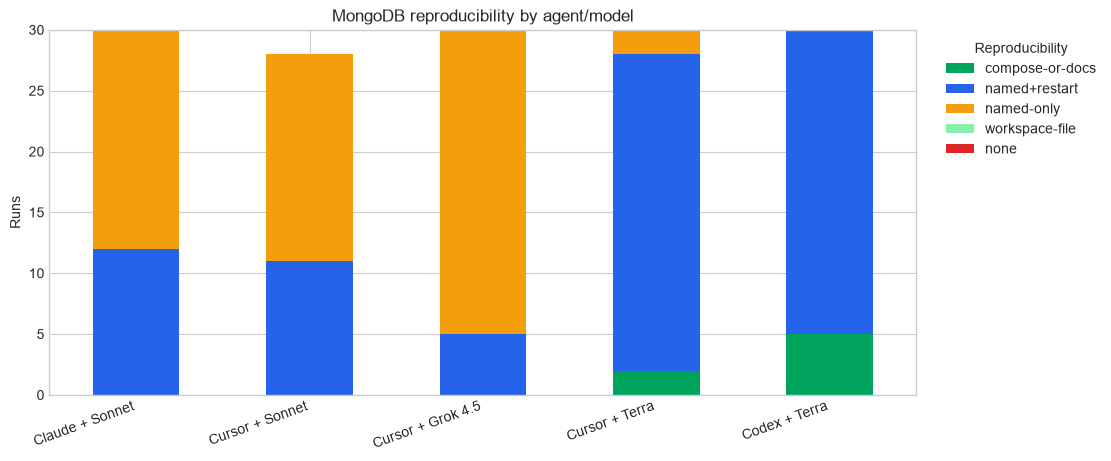

In [25]:
if not READY:
    print("Waiting for measurements.")
else:
    REPRO_ORDER = [
        "compose-or-docs",
        "named+restart",
        "named-only",
        "workspace-file",
        "none",
    ]
    REPRO_COLORS = {
        "compose-or-docs": "#00A35C",
        "named+restart": "#2563EB",
        "named-only": "#F59E0B",
        "workspace-file": "#86EFAC",
        "none": "#DC2626",
    }

    repro_sql = f"""
    SELECT
        run_id,
        countIf(
            positionCaseInsensitive(payload, 'docker-compose.yml') > 0
            OR positionCaseInsensitive(payload, 'docker-compose.yaml') > 0
            OR positionCaseInsensitive(payload, 'compose.yaml') > 0
            OR positionCaseInsensitive(payload, 'compose.yml') > 0
        ) AS compose_file_hits,
        countIf(positionCaseInsensitive(payload, 'Dockerfile') > 0) AS dockerfile_hits,
        countIf(positionCaseInsensitive(payload, 'README.md') > 0) AS readme_hits,
        countIf(
            positionCaseInsensitive(payload, 'docker run') > 0
            AND match(payload, '(?i)--name[[:space:]=]') > 0
        ) AS docker_name_hits,
        countIf(
            positionCaseInsensitive(payload, 'docker run') > 0
            AND (
                positionCaseInsensitive(payload, '--restart unless-stopped') > 0
                OR positionCaseInsensitive(payload, '--restart=unless-stopped') > 0
                OR positionCaseInsensitive(payload, '--restart always') > 0
                OR positionCaseInsensitive(payload, '--restart=always') > 0
            )
        ) AS restart_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
    GROUP BY run_id
    """
    repro_flags = ax_query(repro_sql)
    repro_runs = runs.merge(repro_flags, on="run_id", how="left")
    for column in [
        "compose_file_hits",
        "dockerfile_hits",
        "readme_hits",
        "docker_name_hits",
        "restart_hits",
    ]:
        repro_runs[column] = repro_runs[column].fillna(0)

    if "method_runs" in globals() and not method_runs.empty:
        repro_runs = repro_runs.merge(
            method_runs[["run_id", "final_method"]],
            on="run_id",
            how="left",
        )
    else:
        repro_runs["final_method"] = pd.NA

    def classify_repro(row) -> str:
        if (
            int(row.get("compose_file_hits") or 0) > 0
            or int(row.get("dockerfile_hits") or 0) > 0
            or int(row.get("readme_hits") or 0) > 0
        ):
            return "compose-or-docs"
        named = int(row.get("docker_name_hits") or 0) > 0
        restart = int(row.get("restart_hits") or 0) > 0
        if named and restart:
            return "named+restart"
        if named:
            return "named-only"
        database = str(row.get("database") or "")
        method = str(row.get("final_method") or "")
        if database == "sqlite" and method != "container":
            return "workspace-file"
        return "none"

    repro_runs["reproducibility"] = repro_runs.apply(classify_repro, axis=1)
    repro_runs["reproducibility"] = pd.Categorical(
        repro_runs["reproducibility"], categories=REPRO_ORDER, ordered=True
    )

    print("Reproducibility class by database:")
    repro_xtab = (
        pd.crosstab(repro_runs["database"], repro_runs["reproducibility"])
        .reindex(DATABASE_ORDER)
        .reindex(columns=REPRO_ORDER, fill_value=0)
    )
    display(repro_xtab)

    print("\nRaw signals:")
    signal_rows = []
    for database in DATABASE_ORDER:
        subset = repro_runs[repro_runs["database"] == database]
        signal_rows.append(
            {
                "database": database,
                "n": len(subset),
                "compose_file": int(subset["compose_file_hits"].gt(0).sum()),
                "dockerfile": int(subset["dockerfile_hits"].gt(0).sum()),
                "readme.md": int(subset["readme_hits"].gt(0).sum()),
                "docker_run --name": int(subset["docker_name_hits"].gt(0).sum()),
                "restart policy": int(subset["restart_hits"].gt(0).sum()),
            }
        )
    display(pd.DataFrame(signal_rows))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        subset = repro_runs[repro_runs["database"] == database]
        present = [name for name in REPRO_ORDER if int((subset["reproducibility"] == name).sum()) > 0 or name != "workspace-file" or database == "sqlite"]
        counts = subset["reproducibility"].value_counts().reindex(REPRO_ORDER, fill_value=0)
        ax.bar(
            [str(name) for name in counts.index],
            counts.values,
            color=[REPRO_COLORS[name] for name in counts.index],
        )
        ax.set_title(f"{label_of(database)} (n={len(subset)})")
        ax.set_ylabel("Runs")
        ax.tick_params(axis="x", rotation=25)
        for tick in ax.get_xticklabels():
            tick.set_ha("right")
    fig.suptitle("Reproducibility class", fontweight="bold")
    plt.show()

    print("Mongo reproducibility by agent/model:")
    mongo_repro = repro_runs[repro_runs["database"] == "mongodb"]
    mongo_repro_xtab = (
        pd.crosstab(mongo_repro["extension"], mongo_repro["reproducibility"])
        .reindex(EXTENSION_ORDER)
        .reindex(columns=REPRO_ORDER, fill_value=0)
    )
    display(mongo_repro_xtab)

    fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
    mongo_repro_xtab.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[REPRO_COLORS.get(column, "#9CA3AF") for column in mongo_repro_xtab.columns],
    )
    ax.set_title("MongoDB reproducibility by agent/model")
    ax.set_xlabel("")
    ax.set_ylabel("Runs")
    ax.set_xticklabels([label_of(name) for name in mongo_repro_xtab.index], rotation=20, ha="right")
    ax.legend(title="Reproducibility", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

## Interpretation

**Headline.** Agents like Docker when it is available, and they can provision
Mongo without a problem. Pass rate is the easy story. The paper is the
**defaults**: unnamed-data, root-or-open, live-only containers on the legacy
Hub `mongo` image — on a prompt that never asked for best practices.

Computed on terminal request `01KZXXQ2JPNK4XX5377TF3V8E6`: **443/450**
measurement rows, **369/443 (83.3%)** both-tests pass on the *stored* scorer,
**$61.32** total (mean **$0.138/run**). Seven trials never produced
measurements (2 starved, 5 sandbox-timeout past `max_time_seconds=1800`).
Primary rates use measurement rows; `test_output` is a few rows thinner on
some Cursor cells.

**Scorer note.** Stored Postgres both-tests is **110/150 (73.3%)**. Post-hoc
with `pg_isready` accepted (the packed scorer, not yet published on this
request): **144/150 (96.0%)**. Quote both until AX retest lands; do not treat
the 23pp swing as an install failure.

**Environment.** This run is `docker-host`: Docker is on PATH. That is
capability, not a nudge. The prompt does not mention Docker, and apt /
tarball / native paths were still available. Mongo **148/148** and Postgres
**149/150** still chose `docker run`. SQLite is the control inside this run:
most cells use a workspace file even though Docker is sitting there; Cursor +
Sonnet docks it anyway. That is preference (or default), not environment
coercion. A `stock` arm would answer a different question: what they do when
Docker is missing.

### RQ1 — which database is easiest?

**MongoDB**, on pass rate: **135/148 (91.2%)**. PostgreSQL is the completion
gap at **110/150 (73.3%)** on the *stored* tests (SQL required). If
`pg_isready` counts — the new packed scorer — Postgres both-tests is
**144/150 (96.0%)**, in line with Mongo. SQLite sits in between at
**124/145 (85.5%)** on the stored tests — easy on time/cost, not uniformly
easy on the official tests.

- Mongo misses are almost all `connection-verified-in-agent` (3 no-app-level-op,
  2 readiness-only in test_output). URI reporting is ceiling. The weak Mongo
  cell is **Cursor + Grok (23/30, 77%)**; Claude is 30/30, Cursor + Sonnet 27/28,
  both Terra cells 90–93%.
- Postgres stored misses are **readiness-only** (`pg_isready` / TCP, 33 of 34
  connection failures). Cursor + Grok is **10/30 (33%)** and Cursor + Terra is
  **15/30 (50%)** under SQL-required scoring. Claude, Cursor + Sonnet, and
  Codex + Terra are 93–97%. Under the new metric those two weak cells jump to
  **29/30** and **28/30**; pooled connection-verified is 150/150 (the leftover
  both-tests misses are URI / unscored).
- SQLite's drag is **Claude + Sonnet (20/30)**, mostly `uri-not-reported` (8)
  despite a file `sqlite3` / built-in-library path. Cursor + Sonnet is 24/29
  with 3 no-app-level-op connection misses.

### RQ2 — provisioning methods

Pooled across all agent/models:

- Mongo / Postgres **container** is the attempted path on essentially every
  finished trial (`docker run` 148/148 Mongo, 149/150 Postgres). Failures stay
  labeled `container` with outcome `unverified` (tests failed) or `unscored`
  (no test rows) — not a missing Docker method. Nobody was prompted to use
  Docker; they still did.
- SQLite is **built-in-library** on the file-DB path. The exception is
  **Cursor + Sonnet**, which over-provisions: 15/29 final `container`, plus a
  handful of language-package / apt / tarball paths.

By each agent/model × database, the mix is stable except that Cursor + Sonnet /
SQLite cell. Codex + Terra SQLite is mostly built-in-library plus 2 container.
Claude SQLite is still `built-in-library`; the URI misses are `unverified`,
not a different method.

Container successes are faster than the SQLite over-provision paths: Mongo
container mean 51s / 3.3 turns; SQLite built-in-library 38s / 2.3 turns;
SQLite container 92s / 3.8 turns and ~2× the cost.

### Efficiency and turns

SQLite still wins **time and cost** when the agent stays on a file DB
(Codex + Terra 26s / $0.047; Cursor + Terra 29s / $0.077). It loses when
Cursor + Sonnet docks it (98s / $0.306). Pooled across all combos, SQLite is
actually the *most expensive* database ($22.73 vs Mongo $20.08 vs Postgres
$18.51) because of that over-provision cell plus cheap Postgres *failures*.
Mongo vs Postgres runtime is close inside a combo; Postgres is not the slow
database, it is the *failing* one for two Cursor cells *on the stored scorer*.

Turns are a harness signature, not a database signature:

| Combo | Mean turns |
| --- | ---: |
| Codex + Terra | 1.0 on every DB |
| Cursor + Terra | 1.0–1.2 |
| Cursor + Grok | ~3.0–3.3 |
| Cursor + Sonnet | 3.6–4.6 |
| Claude + Sonnet | 4.0–6.8 |

Codex is also cheapest (~$0.047/run). Claude is most expensive on Mongo/Postgres
($0.20–0.23) because of turn volume; Cursor + Sonnet SQLite is the cost outlier
because of method, not turns.

### Pareto

Cost and **turns** both separate the field. Time is dominated by the Cursor +
Sonnet SQLite container tail. Cheap-but-failing cells (Cursor + Grok / Terra
on Postgres) sit off the frontier *on the stored tests*: low cost, 33–50%
success. Under `pg_isready` they join the pack. Codex + Terra is the
efficiency winner on all three databases (93% × ~$0.047 × 1 turn).

### Same-model harness pairs (n=30)

- **Terra, Cursor vs Codex:** not interchangeable on the *stored* tests.
  Completion matches on Mongo and SQLite (~90–93%), but **Postgres is 15/30 vs
  28/30**. Cursor is ~2× the cost with more tool calls, same 1-turn pattern.
  Under `pg_isready`-accepted scoring that Postgres gap closes (**28/30 vs
  29/30**): Cursor was checking health, not failing to install.
- **Sonnet, Claude vs Cursor:** Mongo/Postgres completion matches (96–100% /
  93–97%). SQLite does not: Claude 20/30 (URI) vs Cursor 24/29 (connection +
  Docker over-provision). Cursor SQLite is 2× slower and ~1.7× cost. Turns
  stay higher on Claude.

### Docker contract

Bet holds. **Guard hits 0/443.** Mongo 148/148 published `-p`. Postgres 148/150
published `-p`, with 19 leftover `--network host` (habit, not required). SQLite
24/145 `docker run` — almost all Cursor + Sonnet over-provision. Validity flags:
0 external cloud, 3 inherited-credential hints.

### Docker image tags (Mongo)

**0/148** used `mongodb/mongodb-community-server`. Every Mongo run is the Docker
Hub `mongo` image, split three ways: **`mongo:latest` 55**, **`mongo:8` 47**,
**`mongo:7` 46**. Pass rates are close for latest (52/55, 94.5%) and 8 (44/47,
93.6%); 7 is lower (39/46, 84.8%) because **Cursor + Grok is 30/30 `mongo:7`**
and that cell is the weak Mongo combo. Image choice is a habit, not a method:

- Cursor + Grok: all `mongo:7`
- Codex + Terra: 29/30 `mongo:8`
- Claude / Cursor + Sonnet: mostly `mongo:latest` (22/30 and 21/28)
- Cursor + Terra: mix of `mongo:8` (18) and `latest` (12)

Postgres is more standardized: **92 `postgres:16`** + **42 `postgres:16-alpine`**.
One `postgres:latest`. Same story as Mongo — agents pick a familiar Hub tag,
not the vendor's named image.

**Steering, not correctness.** `mongo` worked. Zero of 148 transcripts even
*mention* `mongodb/mongodb-community-server`, `mongodb/mongodb-atlas-local`,
Bitnami, or enterprise. No try-and-fail fallback — memorized default. MongoDB
docs have recommended the maintained image for 3+ years; that has no gravity
in these agents. Steering will not happen organically.

**No registry browse.** 0/148 Mongo tool calls used `docker search`, Hub,
MongoDB docs, `docker manifest`, or a web-search/fetch tool. 148/148 went to
`docker run`. Docker Hub appears only as daemon stdout (`Pulling from
library/mongo` / `docker.io/library/mongo`) — the default registry contact
that `docker run` does when the image is not local. 25/148 listed local
`docker images` first (machine cache). 4/148 ran `docker pull` before
`docker run`, still of a name they already knew. Grok/Claude saying "the
official image" is a belief about `mongo`, not a lookup. Postgres is the
same shape. They did not look at a catalog and then pick the old image;
they never opened a catalog.

**How they chose Docker and the image.** Every Mongo run probes the machine
first (mean ~2 tool calls), then fetches. The probe is `which`/`command -v`
for `mongod` and `docker` (Sonnet, Grok, most of Codex) plus `docker ps` /
`docker version`; Cursor + Terra mostly globs/ls the workspace and then
talks to Docker without asking for `mongod`. A minority look for compose /
README in `/workspace` (Codex 18/30). **0** apt-install MongoDB; a handful
`apt-cache search`. After that the first `docker run` already contains the
tag: Grok **30/30 `mongo:7`**, Codex Terra **29/30 `mongo:8`**, Sonnet
mostly `mongo:latest`. Reasoning almost never names the tag (Grok 0/30
`:7` in text; Codex names `:8` in 5/30). The Docker decision is “docker is
on PATH, mongod is not.” The image decision is a memorized default, not a
tool-using comparison.

### Auth asymmetry

Prediction 1 was **wrong on volume**. Mongo *can* start with no credentials, but
**108/148 (73%)** still set `MONGO_INITDB_ROOT_USERNAME` + `PASSWORD` (67 also
pass `--auth`). Skipping it is not rare either: **40/148** did, and they passed
at **38/40 (95%)** vs **97/108 (90%)** with INITDB root. Claude always sets it
(30/30); Codex + Terra sets it least (11/30). The “Mongo needs no auth” story
is about the **image default**, not about agents skipping auth.

Prediction 2 was **wrong as an auth-fumble story**. Postgres agents *do* set
`POSTGRES_PASSWORD` (**149/150**). Transcript auth errors (`password
authentication failed`, `28P01`, `fe_sendauth`) are **0/150**, including
**0/34** connection failures. The handshake gap on the stored tests is **probe style**, not a forgotten
password. The experiment scorer now accepts `pg_isready` (TCP-only still
fails). Post-hoc on this request: Postgres both-tests **110/150 → 144/150**.
The 40 connection flips are 33 readiness-only + 6 unscored + 1 no-app-level-op
that still had `pg_isready` in the transcript.

### Mongo verification style

**Ping monoculture.** 148/148 runs use `mongosh`. **0** insert, **0** find, **0**
`listDatabases`, **0** `serverStatus`, **0** `MongoClient`/`pymongo`. Primary
label: **131 ping-or-hello**, 9 `runCommand-other`, 8 `collection(` (no driver
client). The official scorer treats `{ping:1}` as an application-level
operation, which is why Mongo completion can stay high while the *style* of
proof is weak.

The 5 official Mongo connection misses are not “no Mongo client”: 4 are
classified `ping-or-hello` (2 readiness-only, 2 no-app-level-op) and 1 is
`collection(` / no-app-level-op. Those pings were present but not credited
(failed command, ordering vs last `docker run`, or a later failure) — a
recognizer/transcript issue, not a missing install.

### Best-practice gap (defaults, not the prompt)

The official tests measure “does it work.” These three sections measure “is
it any good,” on a prompt that never asked for best practices — so this is
the **default** an agent ships.

**Durability.** Mongo **68/148 (46%)** mount a volume; **55/148 (37%)** are
ephemeral (no volume, no restart). Postgres is worse: **47/150 (31%)**
volume, **80/150 (53%)** ephemeral. SQLite inverts this: **144/145** are a
workspace file (durable by construction); the one miss is a containerized
SQLite with no volume. `--restart unless-stopped` is common when they think
of ops (85 Mongo, 66 Postgres) but is not a substitute for a volume.
Codex + Terra almost never ships ephemeral Mongo (0/30); Cursor + Grok is
the other pole (**24/30** Mongo ephemeral, **30/30** Postgres ephemeral).

**Least privilege.** **0/148** Mongo runs created a scoped app user
(`db.createUser`). **1/150** Postgres runs used `CREATE USER` / `GRANT`.
When credentials exist they are the image bootstrap superuser: Mongo
**108/148** `MONGO_INITDB_ROOT_*`, Postgres **149/150** `POSTGRES_PASSWORD`.
The remaining **40/148** Mongo runs have **no auth at all**. Codex + Terra
is the most no-auth Mongo cell (19/30); Claude + Sonnet set INITDB root in
all 30. `MONGO_INITDB_DATABASE` (17/148) is still the root user, just a
default DB name.

**Reproducibility.** Every Mongo run names the container (**148/148**).
Almost none write an artifact a teammate could re-run: **1** compose file,
**6** Dockerfiles, **0** READMEs. The split is session-local:
**79/148** `named+restart`, **62/148** named-only. Postgres is the same
shape (0 compose, 1 Dockerfile, 0 README). SQLite's "reproducibility" is
the `.db` file in the workspace (**116/145** `workspace-file`), not docs.
Portable reproducibility (compose/README) is effectively zero for
Mongo/Postgres.

Headline: agents can provision Mongo. The default they provision is often
an unnamed-data, root-or-open, live-only Docker container.

### What n=5 got right

Postgres readiness-only as the completion gap *under SQL-required scoring*
(now treated as a scorer choice, not install failure); SQLite spread as a
harness/method story; Docker `-p` without the old guard; Claude vs Cursor
Sonnet not equivalent.
What n=5 could not see: Cursor + Terra inherits the Grok-like Postgres verifier
failure at 50%, and Claude SQLite URI misses are a 33pp hole, not noise.

### Deferred (run in this notebook if measured)

Do not leave these only in chat:

- Port bind × auth (`-p 27017:27017` vs `127.0.0.1`; no-auth + `0.0.0.0`)
- `POSTGRES_HOST_AUTH_METHOD=trust`
- Weak-password boolean patterns (must not print secrets)
- Readiness vs `sleep N`
- `--replSet` / `rs.initiate` (standalone vs single-node RS)
- Destructive `docker rm -f` / volume rm
- Within-cell consistency of image/auth/volume as its own metric
- SQLite quality (0-byte file, WAL, `foreign_keys`)
